In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from astar import global_octile_distance, astar, Map, SearchTreePQD, make_path, draw_simple, draw, Node, multi_global_octile_distance
import math
from metrics_collector import starts_from_file, data_from_dir, astar_octile_search, wastar_octile_search, cfastar_octile_search, create_TransPath_model, cfastar_octile_search_with_prediction, contain_ratios, count_complexity, get_metrics, get_splitted_metrics
from model import *
from evit_unet import Eff_Unet

In [ ]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/QRs_big_model_3', device='cuda:6')

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', threshold=1.05, verbose=1)

In [2]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

args = {
        'layers' : [5, 5, 15, 10],
        'embed_dims' : [5, 10, 24, 48],
        'downsamples' : [True, True, True, True],
        'vit_num' : 6,
        'drop_path_rate' : 0.1,
        'num_classes' : 1,
        'resolution' : 64,
        'fork_feat' : True
}
model = create_TransPath_model(model_name=Eff_Unet, weights_path='../weights/QRs_big_model_unet', device='cuda:3', **args)

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', save_baseline_to='testset_astar.csv', threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)
/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [3]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/evit_unet1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [4]:
import pickle



# Save to a pickle file
with open("../results/evit_unet1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,10.17%
Length ratio,100.0±0.0%,111.58±14.92%
Expansions ratio,100.0±0.0%,108.0±76.98%


In [2]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/fastTest_ds=test, bs=512, ep=50, lr=0.008', device='cuda:1')

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [3]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/fastTest_ds1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [4]:
import pickle



# Save to a pickle file
with open("../results/fastTest_ds1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,51.79%
Length ratio,100.0±0.0%,101.21±2.44%
Expansions ratio,100.0±0.0%,46.41±24.79%


In [5]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/MoE_bigTest', device='cpu')

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [6]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/MOEOPTIMALBIGTEST1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [7]:
import pickle



# Save to a pickle file
with open("../results/MOEOPTIMALBIGTEST1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,46.58%
Length ratio,100.0±0.0%,101.48±2.75%
Expansions ratio,100.0±0.0%,49.67±24.73%


In [2]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250429-203918', device='cuda:2')

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [3]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALBIGTEST1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [4]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALBIGTEST1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,45.58%
Length ratio,100.0±0.0%,101.61±3.2%
Expansions ratio,100.0±0.0%,49.06±24.4%


In [6]:
model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250429-203918', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

...

Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [7]:
import pickle

# Save to a pickle file
with open("../results/BIGTESTSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [8]:
import pickle



# Save to a pickle file
with open("../results/BIGTESTSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model
Optimal found ratio,100.0%,28.7%
Length ratio,100.0±0.0%,100.21±0.19%
Expansions ratio,100.0±0.0%,83.75±18.03%


,baseline,model
Optimal found ratio,100.0%,33.5%
Length ratio,100.0±0.0%,103.33±7.02%
Expansions ratio,100.0±0.0%,49.06±20.91%


,baseline,model
Optimal found ratio,100.0%,22.65%
Length ratio,100.0±0.0%,103.1±2.9%
Expansions ratio,100.0±0.0%,44.87±16.32%


,baseline,model
Optimal found ratio,100.0%,28.2%
Length ratio,100.0±0.0%,102.1±2.61%
Expansions ratio,100.0±0.0%,40.99±17.79%


,baseline,model
Optimal found ratio,100.0%,17.3%
Length ratio,100.0±0.0%,103.0±3.21%
Expansions ratio,100.0±0.0%,44.86±15.98%


,baseline,model
Optimal found ratio,100.0%,74.7%
Length ratio,100.0±0.0%,100.44±0.95%
Expansions ratio,100.0±0.0%,50.18±26.73%


,baseline,model
Optimal found ratio,100.0%,66.15%
Length ratio,100.0±0.0%,100.86±1.64%
Expansions ratio,100.0±0.0%,37.76±21.46%


,baseline,model
Optimal found ratio,100.0%,66.9%
Length ratio,100.0±0.0%,100.68±1.38%
Expansions ratio,100.0±0.0%,44.86±23.07%


,baseline,model
Optimal found ratio,100.0%,48.35%
Length ratio,100.0±0.0%,101.76±2.69%
Expansions ratio,100.0±0.0%,51.92±20.33%


,baseline,model
Optimal found ratio,100.0%,69.3%
Length ratio,100.0±0.0%,100.61±1.29%
Expansions ratio,100.0±0.0%,42.39±27.01%


In [9]:
for res in ress:
    print(*np.array(res['model']))

28.7% 100.21±0.19% 83.75±18.03%
33.5% 103.33±7.02% 49.06±20.91%
22.65% 103.1±2.9% 44.87±16.32%
28.2% 102.1±2.61% 40.99±17.79%
17.3% 103.0±3.21% 44.86±15.98%
74.7% 100.44±0.95% 50.18±26.73%
66.15% 100.86±1.64% 37.76±21.46%
66.9% 100.68±1.38% 44.86±23.07%
48.35% 101.76±2.69% 51.92±20.33%
69.3% 100.61±1.29% 42.39±27.01%


In [9]:
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250428-114414', device='cuda:2')

res = contain_ratios(cells, starts, goals, model=model, node_type='optimal', threshold=1.05, verbose=1)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)
/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


In [10]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALBIGSMART1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [11]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALBIGSMART1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,42.2%
Length ratio,100.0±0.0%,123.05±46.85%
Expansions ratio,100.0±0.0%,113.08±135.35%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

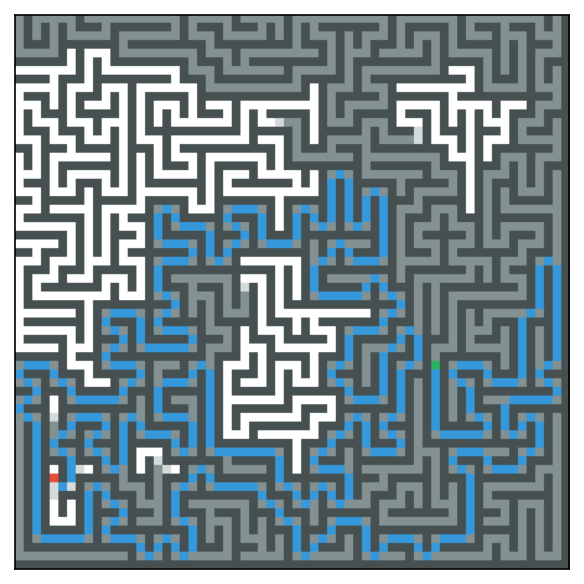

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


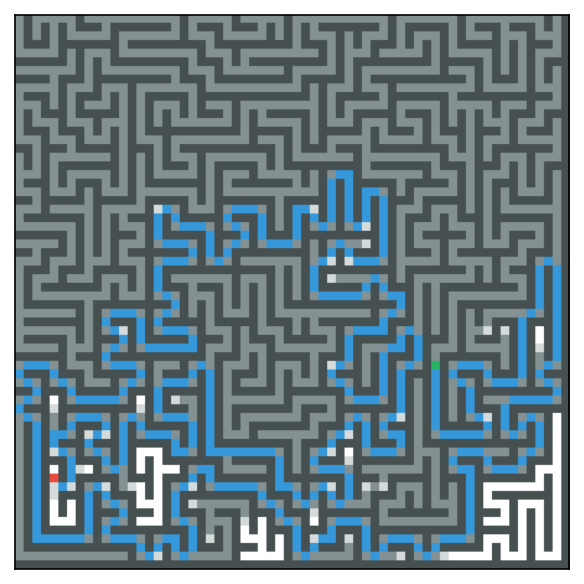

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

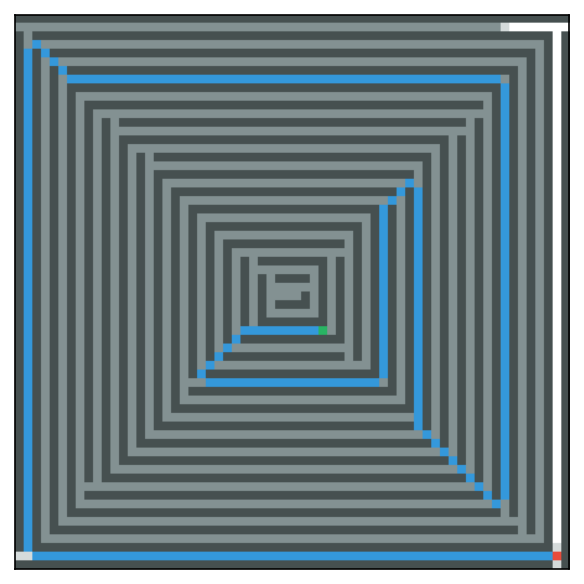

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


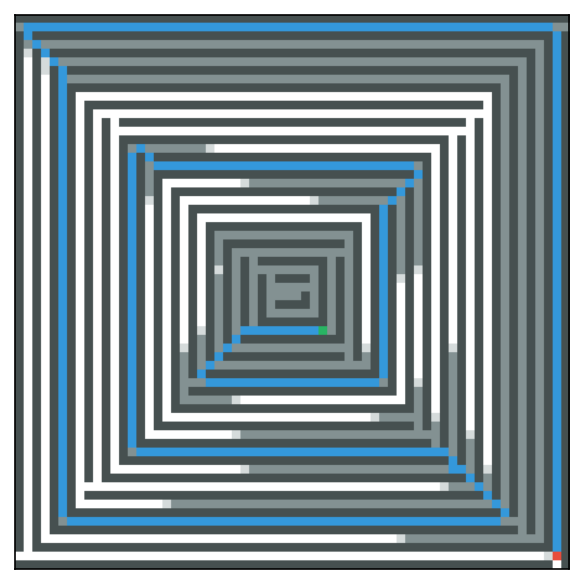

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

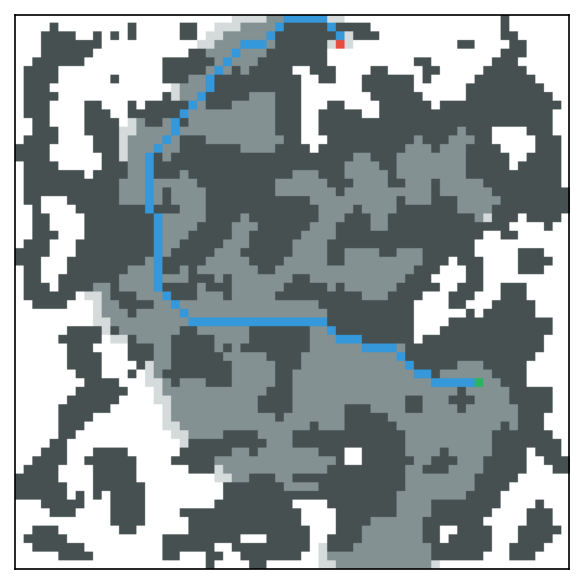

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


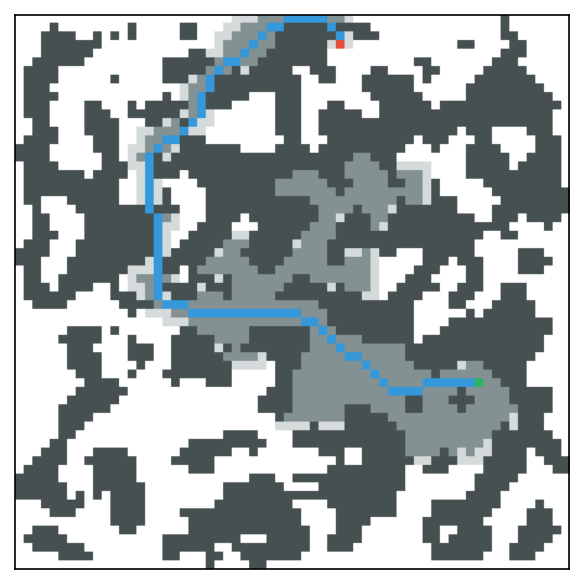

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

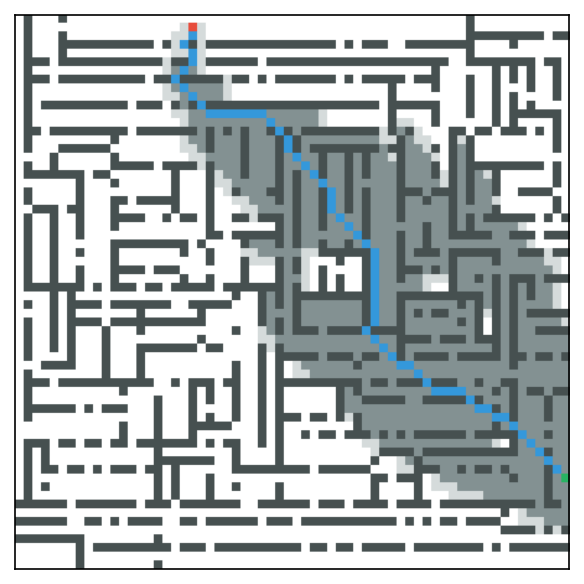

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


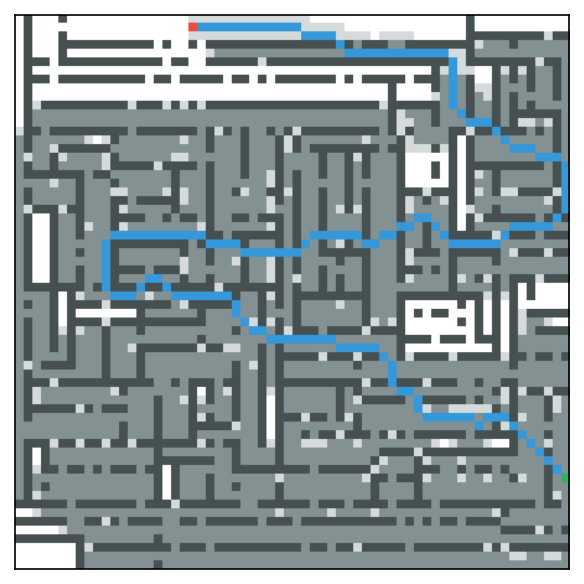

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

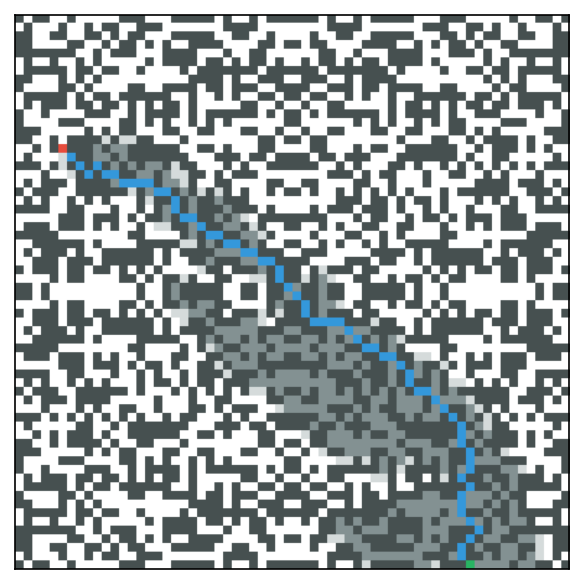

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


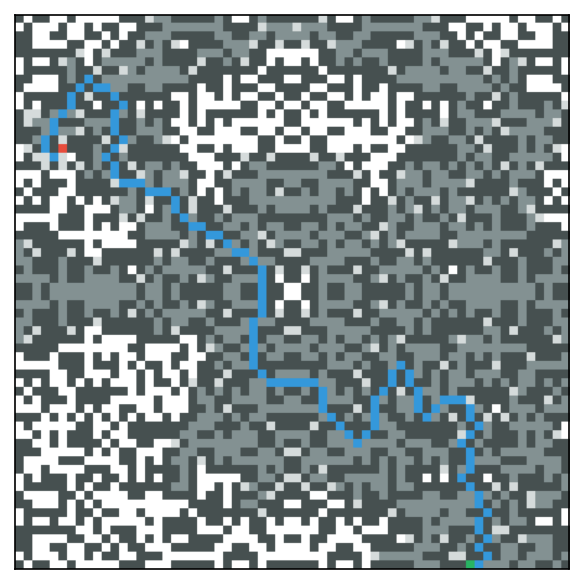

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

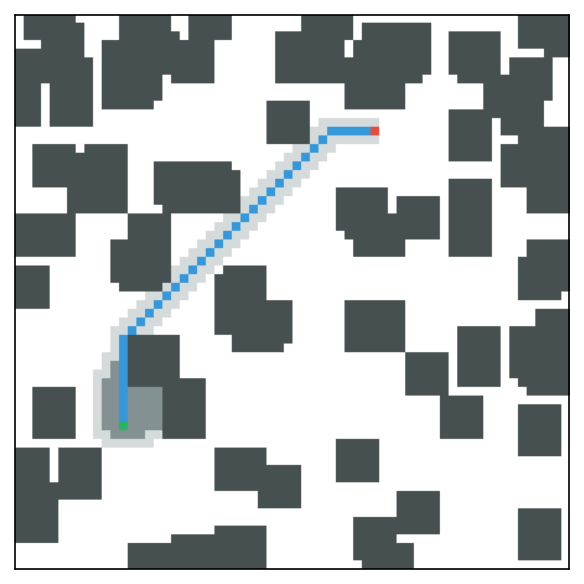

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


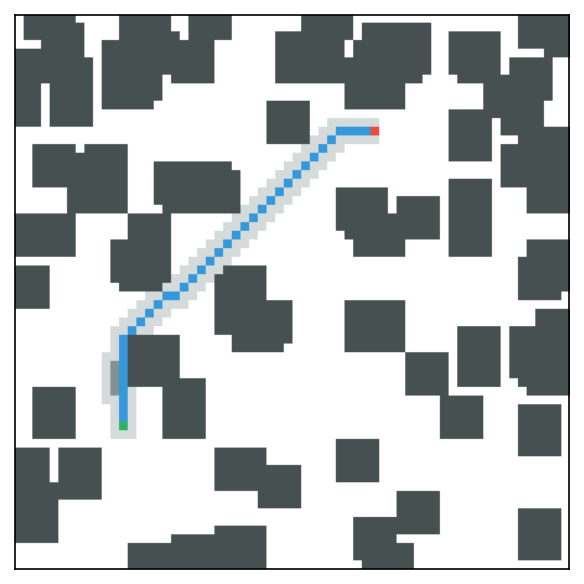

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

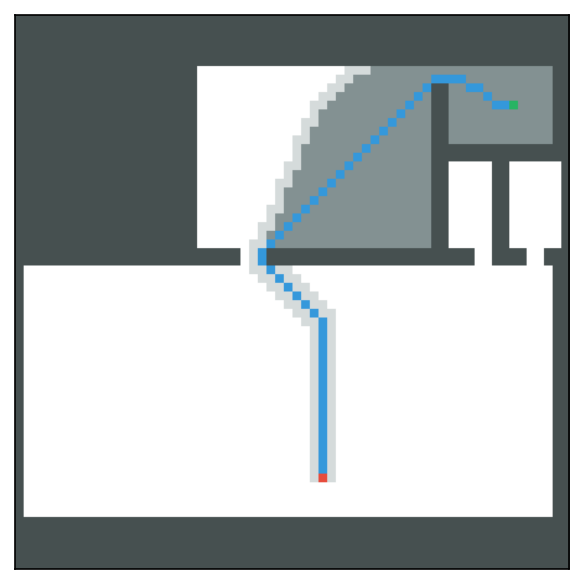

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


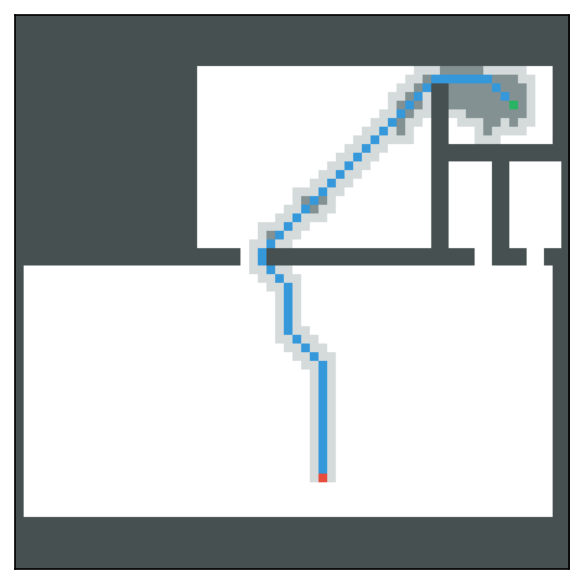

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

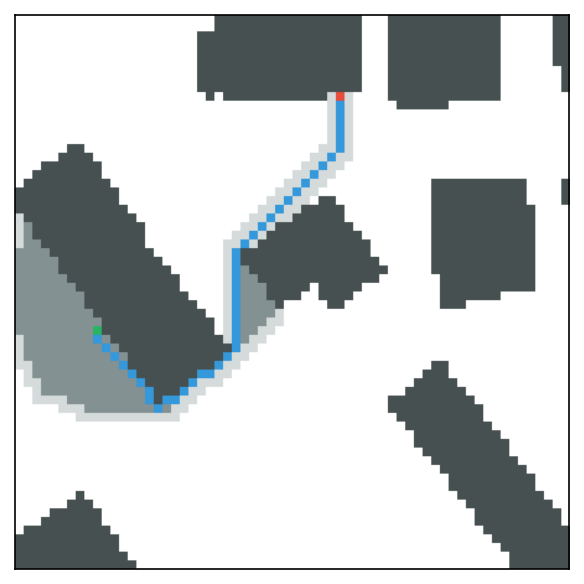

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


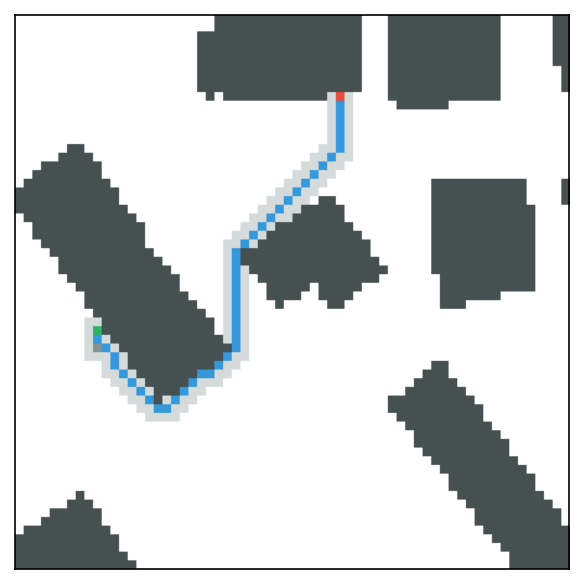

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

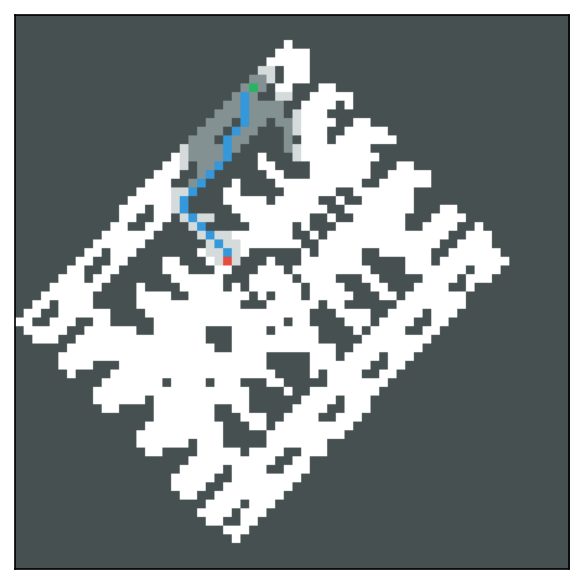

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


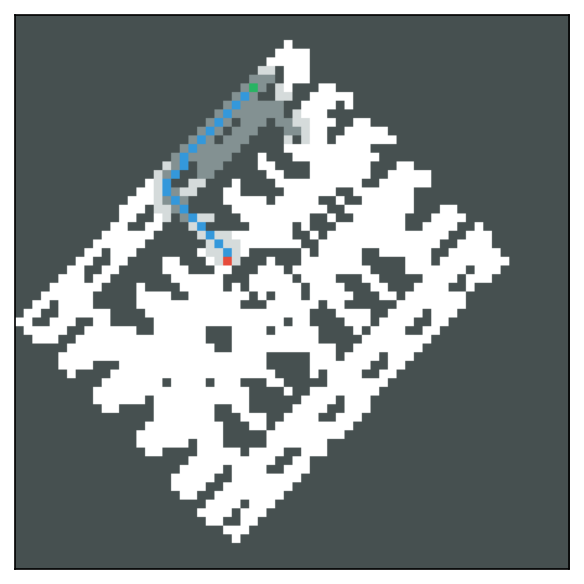

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

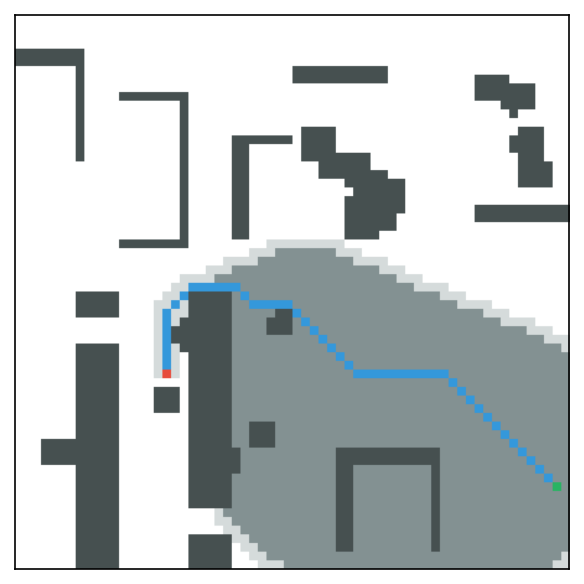

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


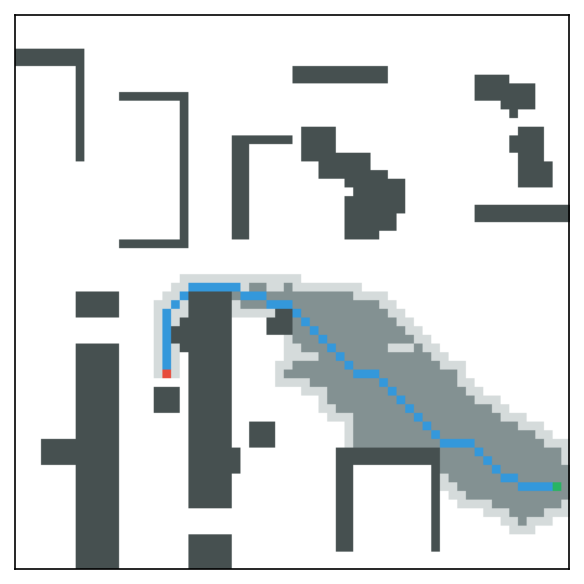

During the search was discovered 0 non-existent paths


In [2]:
model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250428-114414', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, threshold=1.05, verbose=2)

In [3]:
import pickle

# Save to a pickle file
with open("../results/BIGSMARTSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [4]:
import pickle



# Save to a pickle file
with open("../results/BIGSMARTSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model
Optimal found ratio,100.0%,0.0%
Length ratio,100.0±0.0%,102.29±0.58%
Expansions ratio,100.0±0.0%,97.83±39.2%


,baseline,model
Optimal found ratio,100.0%,0.9%
Length ratio,100.0±0.0%,185.56±66.2%
Expansions ratio,100.0±0.0%,130.5±97.55%


,baseline,model
Optimal found ratio,100.0%,30.55%
Length ratio,100.0±0.0%,103.97±9.48%
Expansions ratio,100.0±0.0%,61.44±32.92%


,baseline,model
Optimal found ratio,100.0%,0.65%
Length ratio,100.0±0.0%,160.51±48.69%
Expansions ratio,100.0±0.0%,263.26±232.32%


,baseline,model
Optimal found ratio,100.0%,0.35%
Length ratio,100.0±0.0%,174.09±62.03%
Expansions ratio,100.0±0.0%,274.09±205.45%


,baseline,model
Optimal found ratio,100.0%,88.8%
Length ratio,100.0±0.0%,100.23±1.86%
Expansions ratio,100.0±0.0%,43.48±32.92%


,baseline,model
Optimal found ratio,100.0%,83.55%
Length ratio,100.0±0.0%,100.32±0.95%
Expansions ratio,100.0±0.0%,73.02±49.5%


,baseline,model
Optimal found ratio,100.0%,77.0%
Length ratio,100.0±0.0%,100.69±2.99%
Expansions ratio,100.0±0.0%,43.64±35.52%


,baseline,model
Optimal found ratio,100.0%,54.9%
Length ratio,100.0±0.0%,102.55±7.72%
Expansions ratio,100.0±0.0%,92.86±43.89%


,baseline,model
Optimal found ratio,100.0%,85.25%
Length ratio,100.0±0.0%,100.25±1.11%
Expansions ratio,100.0±0.0%,50.71±29.96%


In [5]:
for res in ress:
    print(*np.array(res['model']))

0.0% 102.29±0.58% 97.83±39.2%
0.9% 185.56±66.2% 130.5±97.55%
30.55% 103.97±9.48% 61.44±32.92%
0.65% 160.51±48.69% 263.26±232.32%
0.35% 174.09±62.03% 274.09±205.45%
88.8% 100.23±1.86% 43.48±32.92%
83.55% 100.32±0.95% 73.02±49.5%
77.0% 100.69±2.99% 43.64±35.52%
54.9% 102.55±7.72% 92.86±43.89%
85.25% 100.25±1.11% 50.71±29.96%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

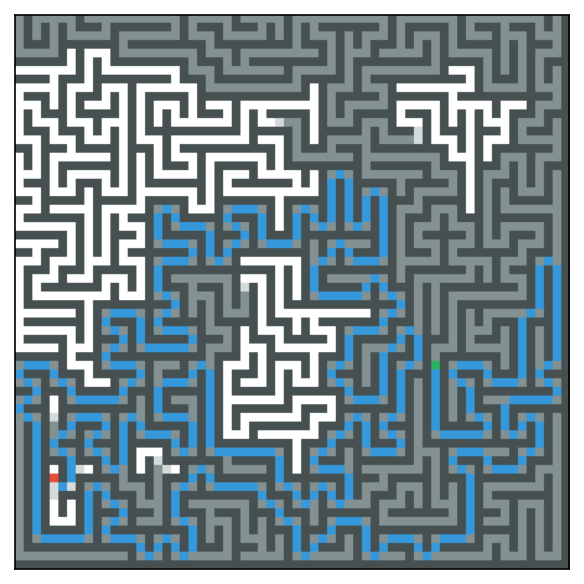

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


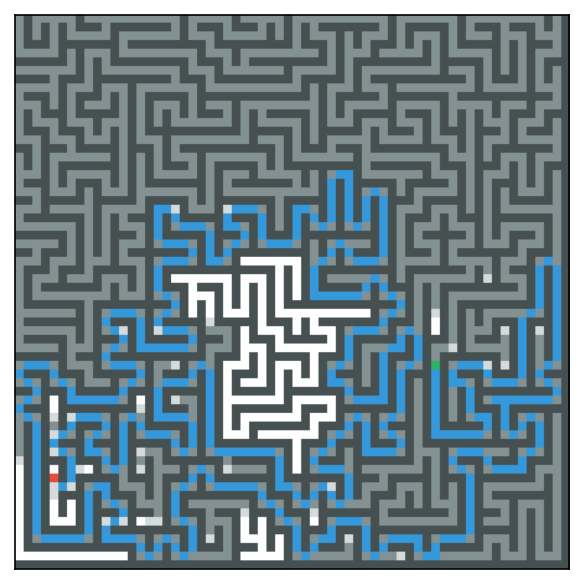

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

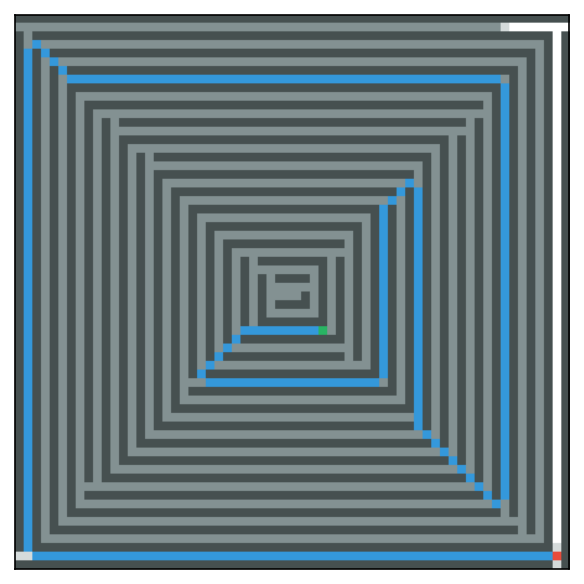

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


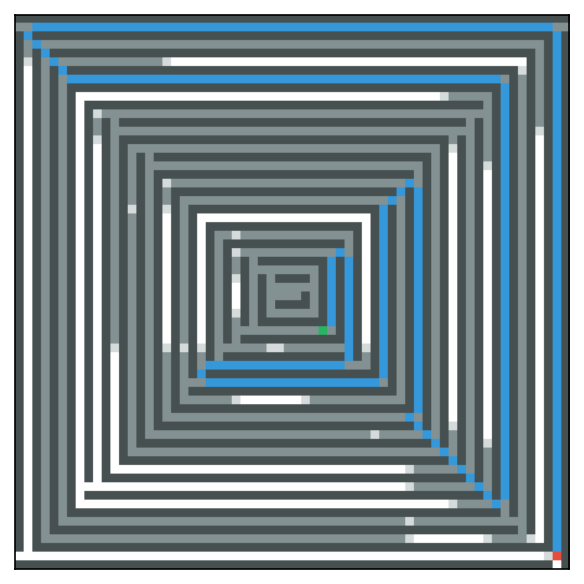

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

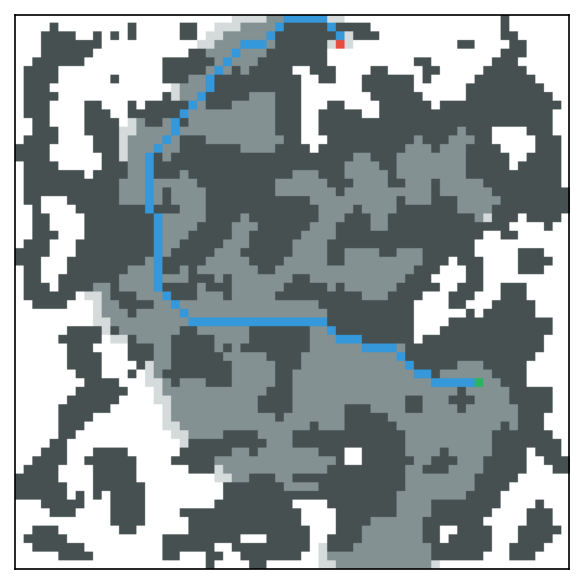

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


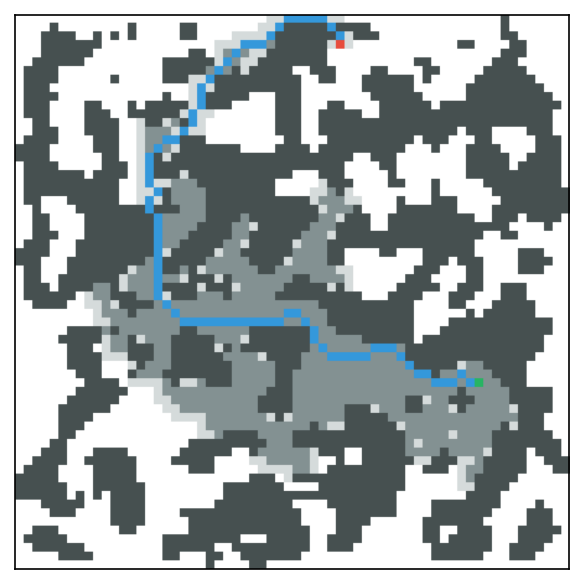

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

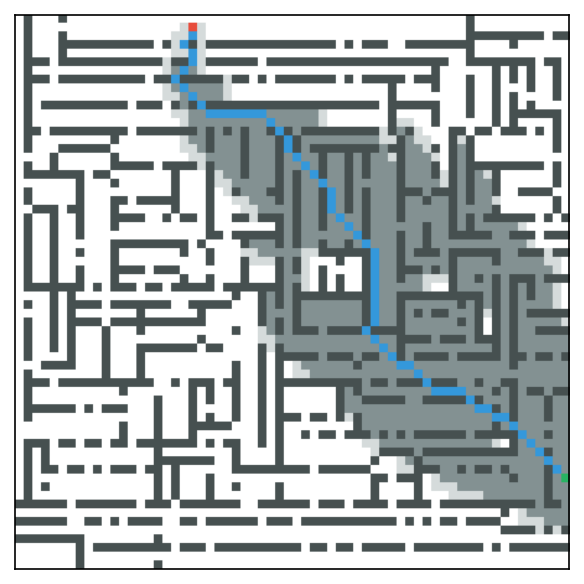

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


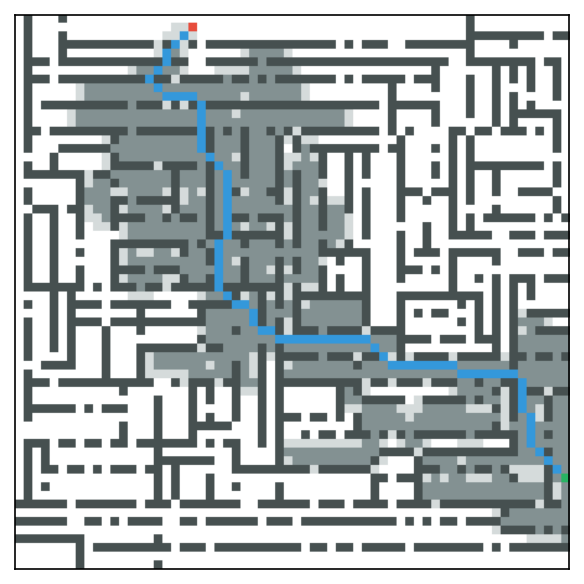

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

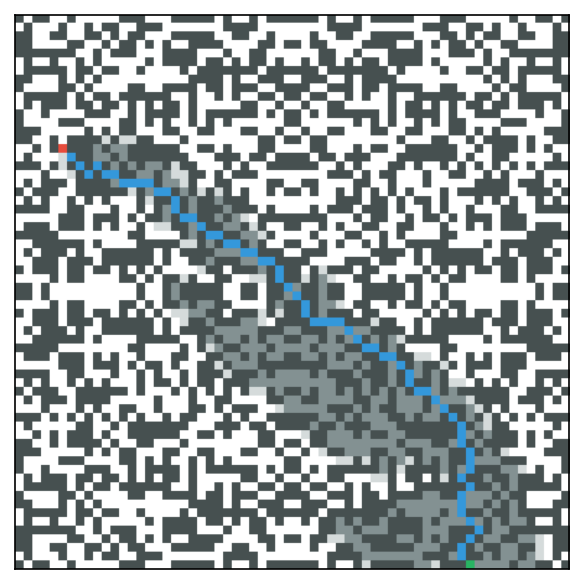

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


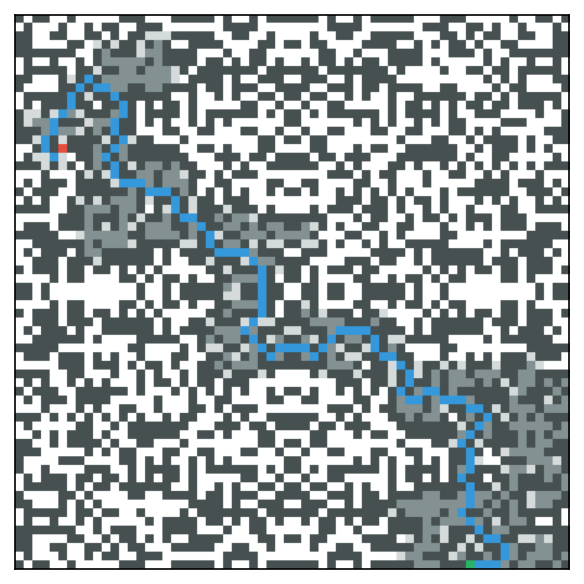

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

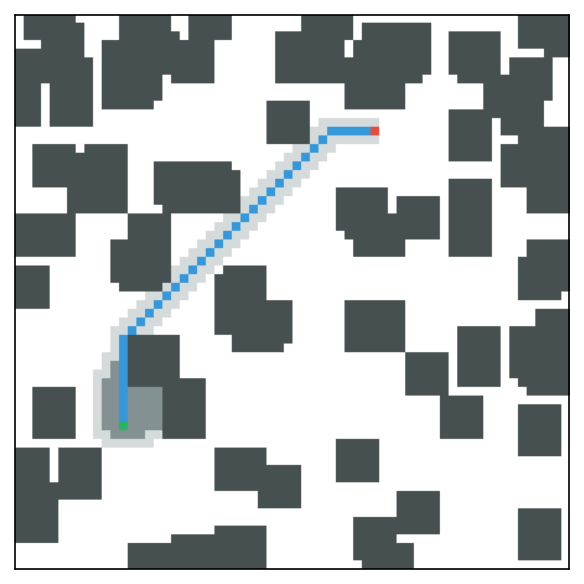

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


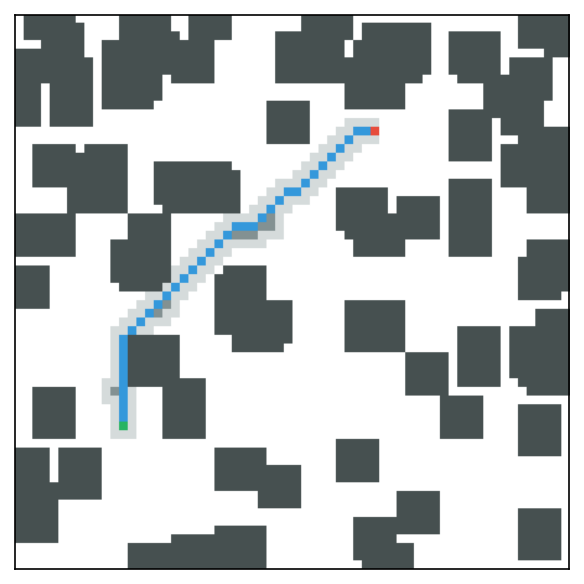

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

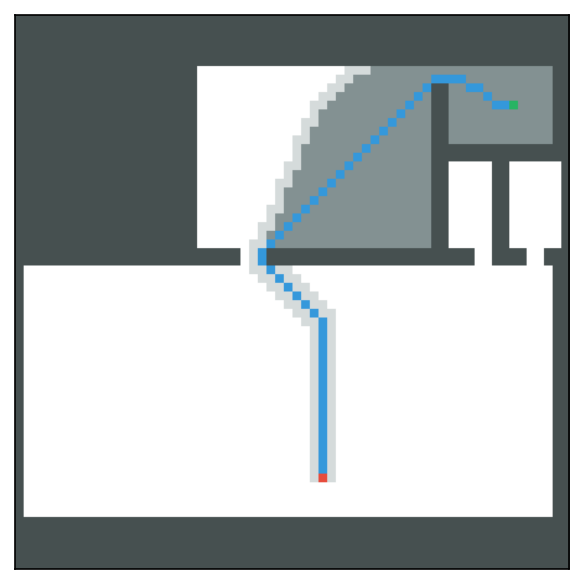

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


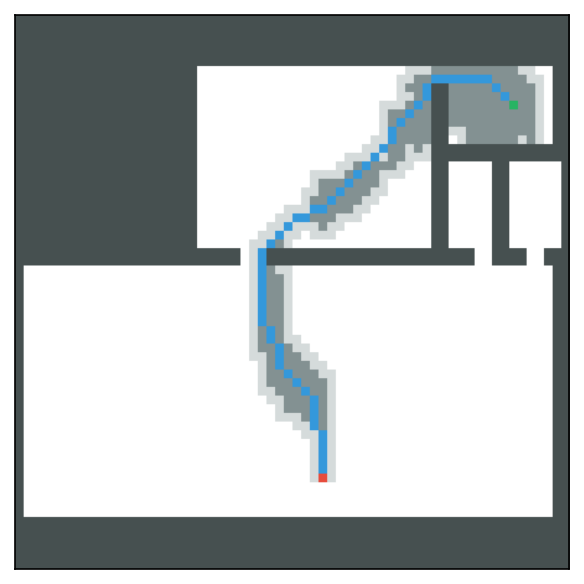

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

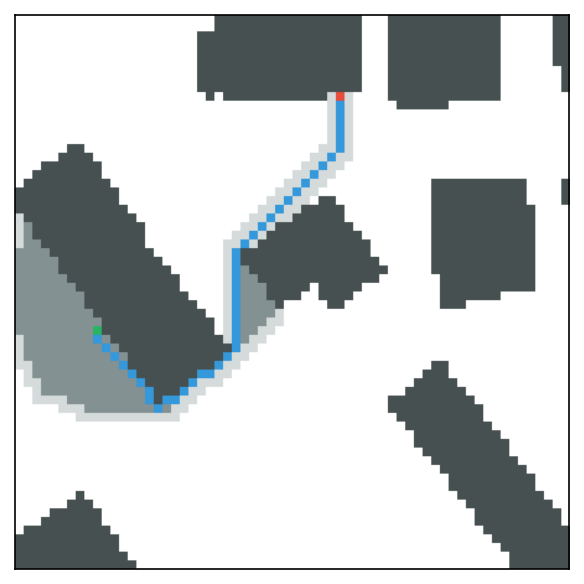

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


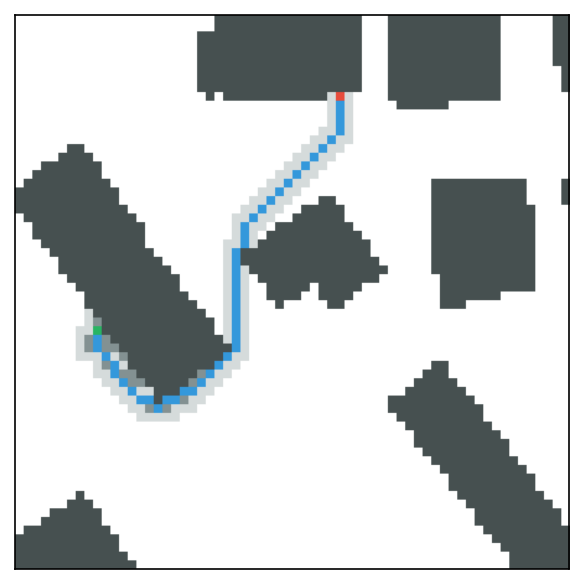

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

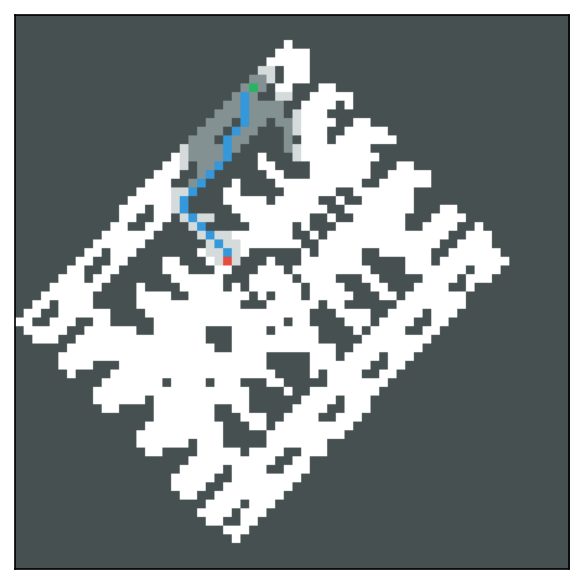

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


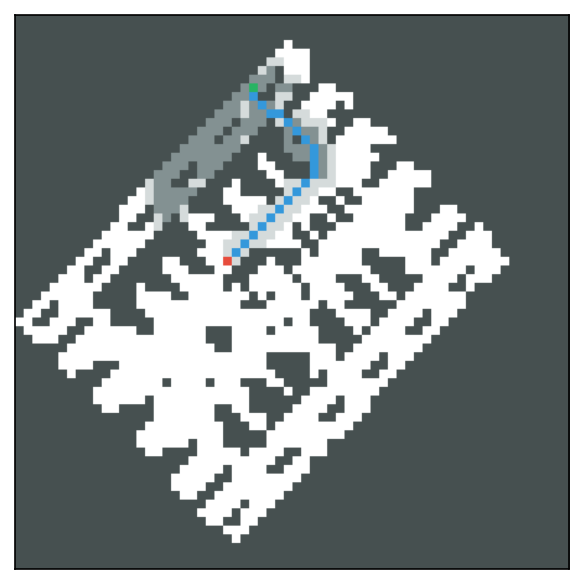

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

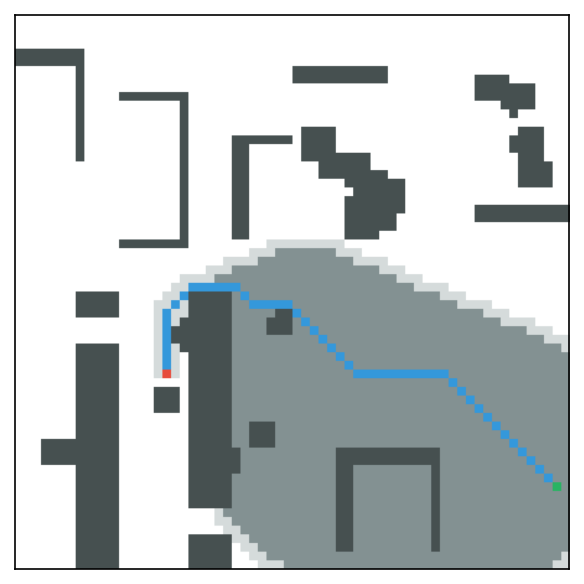

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


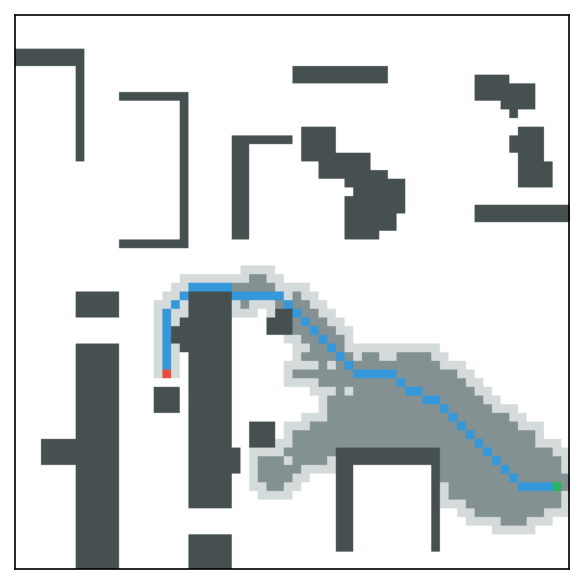

During the search was discovered 0 non-existent paths


In [9]:
model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250414-020803', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, threshold=1.05, verbose=2)

In [10]:
import pickle

# Save to a pickle file
with open("../results/SMARTSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [11]:
import pickle



# Save to a pickle file
with open("../results/SMARTSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model
Optimal found ratio,100.0%,0.0%
Length ratio,100.0±0.0%,102.91±0.64%
Expansions ratio,100.0±0.0%,92.13±29.11%


,baseline,model
Optimal found ratio,100.0%,2.35%
Length ratio,100.0±0.0%,150.56±47.08%
Expansions ratio,100.0±0.0%,124.74±90.54%


,baseline,model
Optimal found ratio,100.0%,11.5%
Length ratio,100.0±0.0%,107.82±12.34%
Expansions ratio,100.0±0.0%,69.88±38.39%


,baseline,model
Optimal found ratio,100.0%,0.2%
Length ratio,100.0±0.0%,156.06±43.38%
Expansions ratio,100.0±0.0%,222.88±192.84%


,baseline,model
Optimal found ratio,100.0%,0.4%
Length ratio,100.0±0.0%,168.01±53.77%
Expansions ratio,100.0±0.0%,241.36±177.94%


,baseline,model
Optimal found ratio,100.0%,69.4%
Length ratio,100.0±0.0%,100.84±3.08%
Expansions ratio,100.0±0.0%,56.8±37.89%


,baseline,model
Optimal found ratio,100.0%,66.8%
Length ratio,100.0±0.0%,100.82±1.71%
Expansions ratio,100.0±0.0%,85.44±55.75%


,baseline,model
Optimal found ratio,100.0%,54.25%
Length ratio,100.0±0.0%,101.53±4.81%
Expansions ratio,100.0±0.0%,52.01±40.77%


,baseline,model
Optimal found ratio,100.0%,31.2%
Length ratio,100.0±0.0%,104.8±9.34%
Expansions ratio,100.0±0.0%,102.62±49.04%


,baseline,model
Optimal found ratio,100.0%,63.7%
Length ratio,100.0±0.0%,100.77±1.95%
Expansions ratio,100.0±0.0%,64.47±36.88%


In [12]:
for res in ress:
    print(*np.array(res['model']))

0.0% 102.91±0.64% 92.13±29.11%
2.35% 150.56±47.08% 124.74±90.54%
11.5% 107.82±12.34% 69.88±38.39%
0.2% 156.06±43.38% 222.88±192.84%
0.4% 168.01±53.77% 241.36±177.94%
69.4% 100.84±3.08% 56.8±37.89%
66.8% 100.82±1.71% 85.44±55.75%
54.25% 101.53±4.81% 52.01±40.77%
31.2% 104.8±9.34% 102.62±49.04%
63.7% 100.77±1.95% 64.47±36.88%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

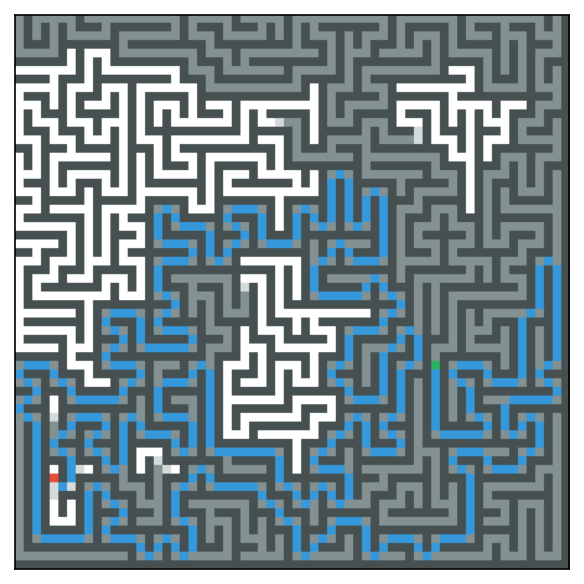

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


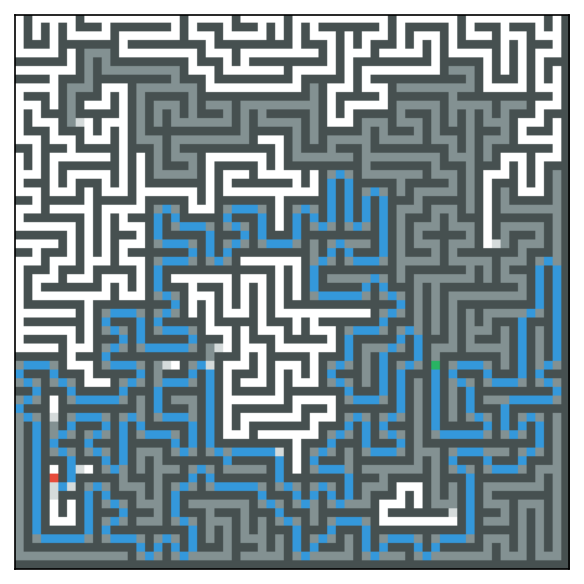

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

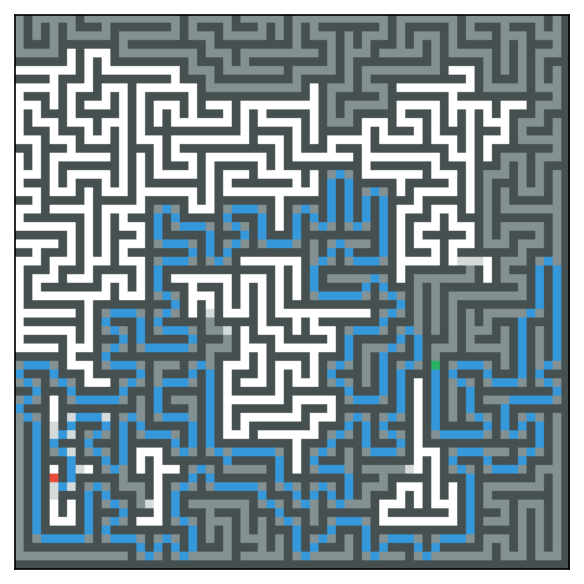

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

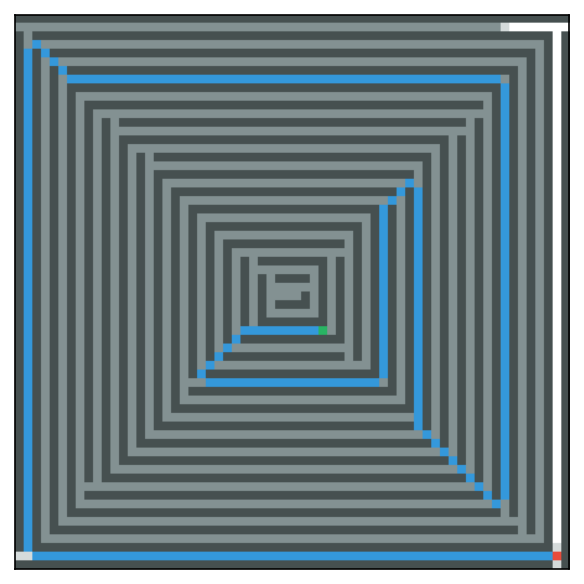

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


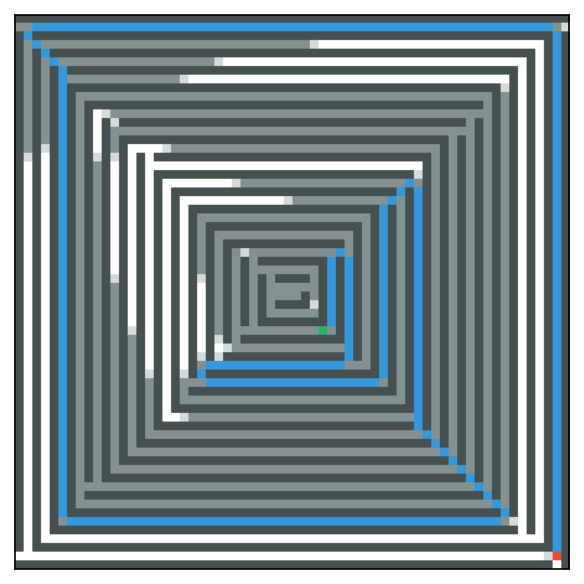

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

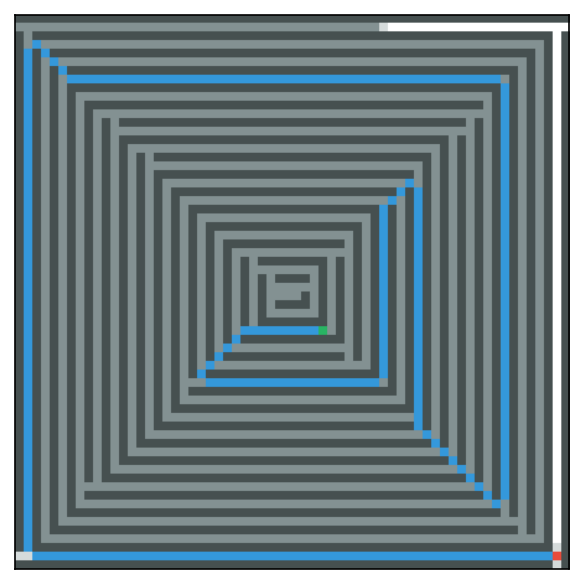

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

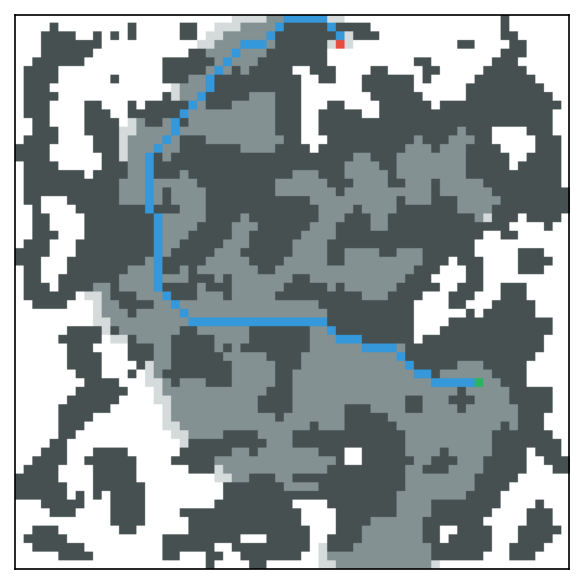

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


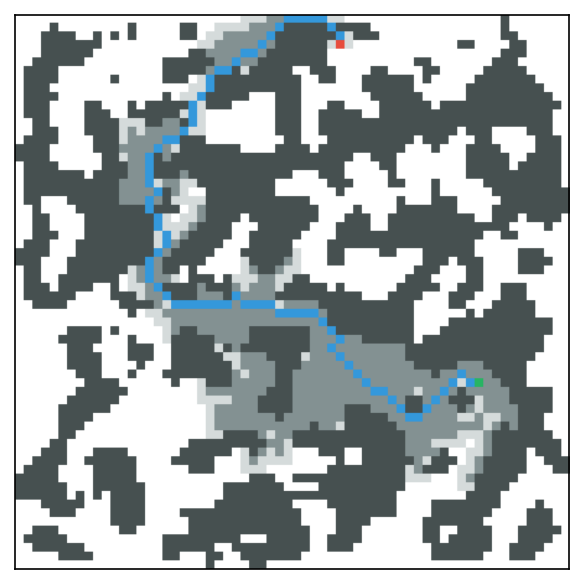

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

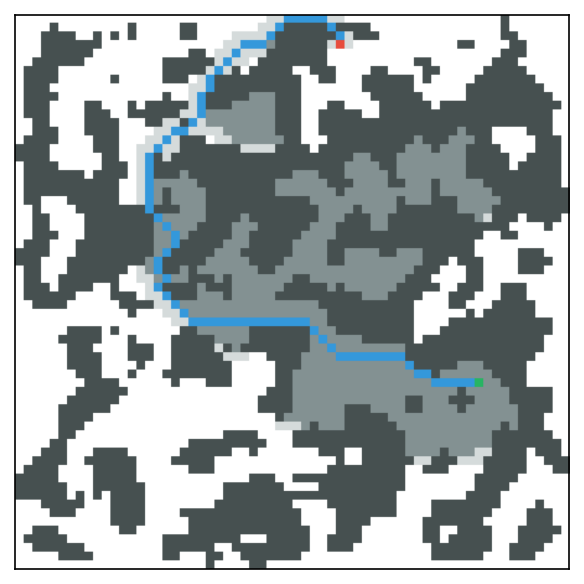

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

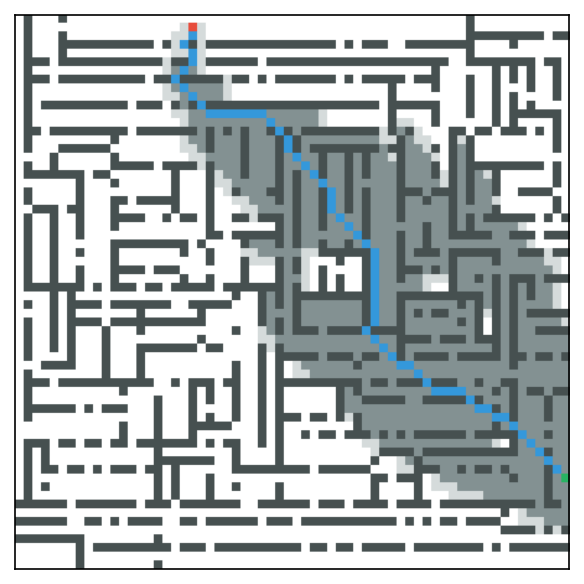

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


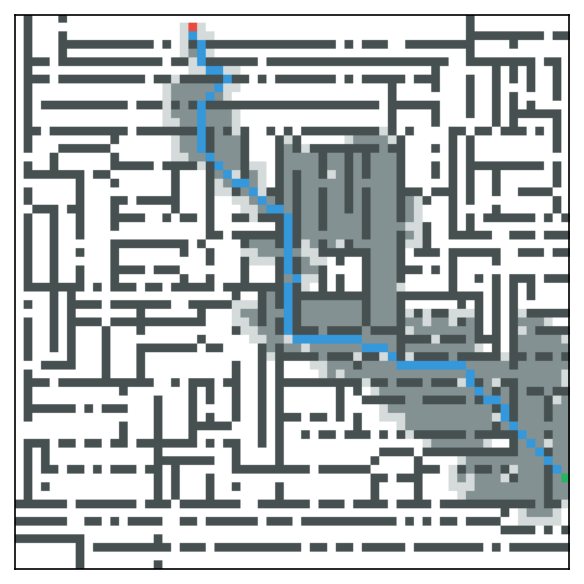

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

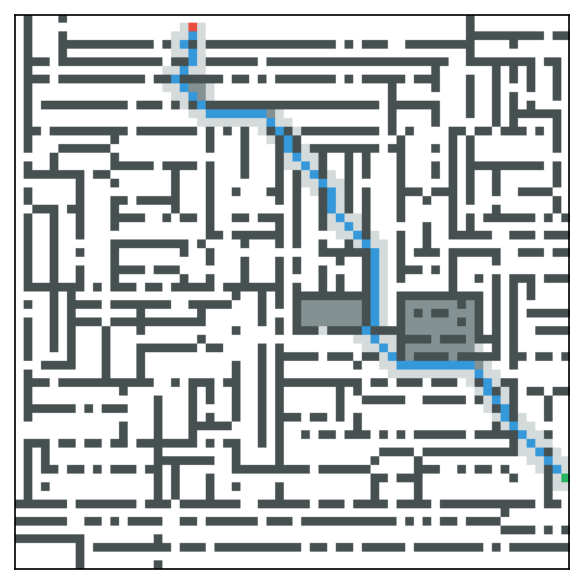

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

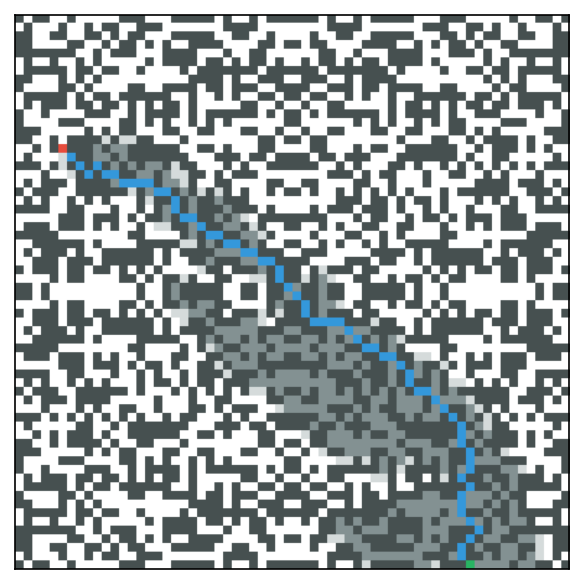

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


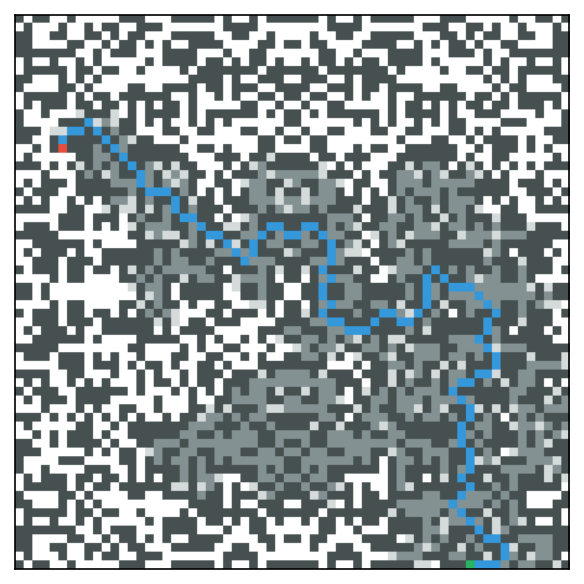

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

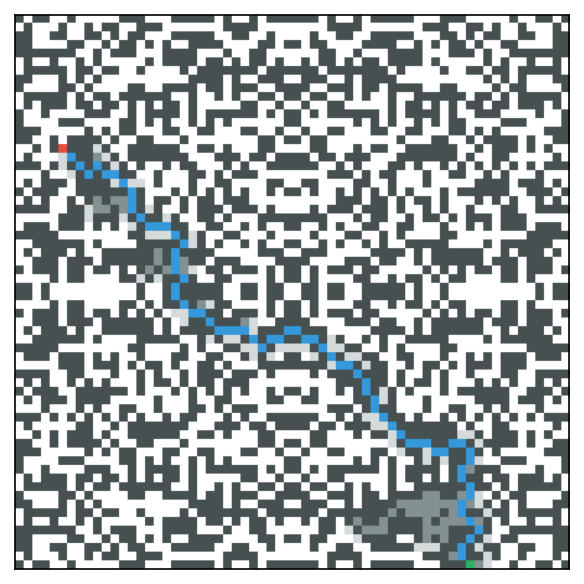

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

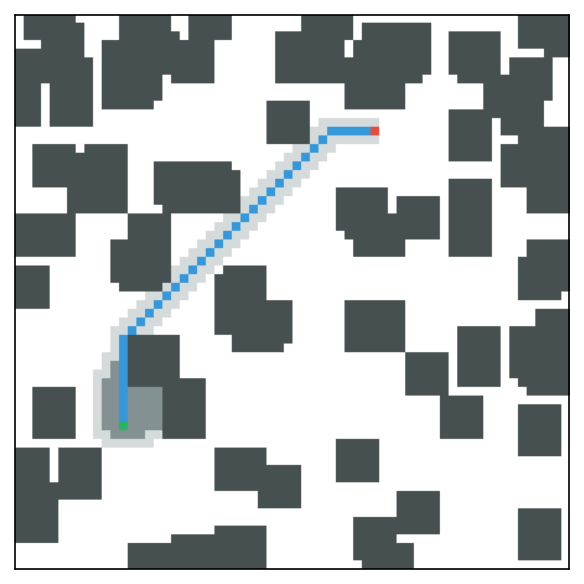

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


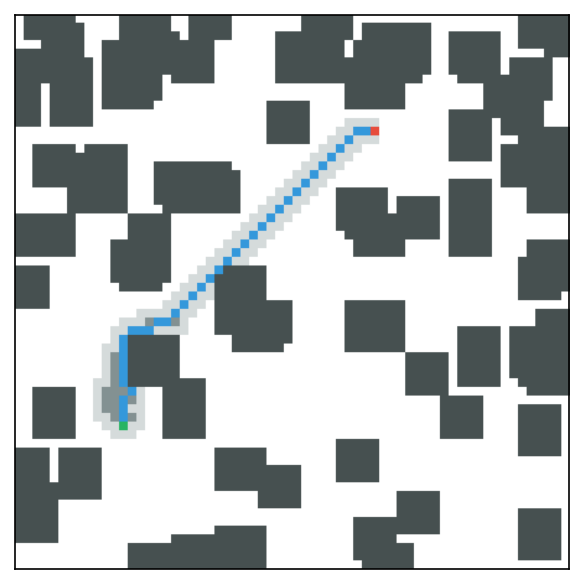

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

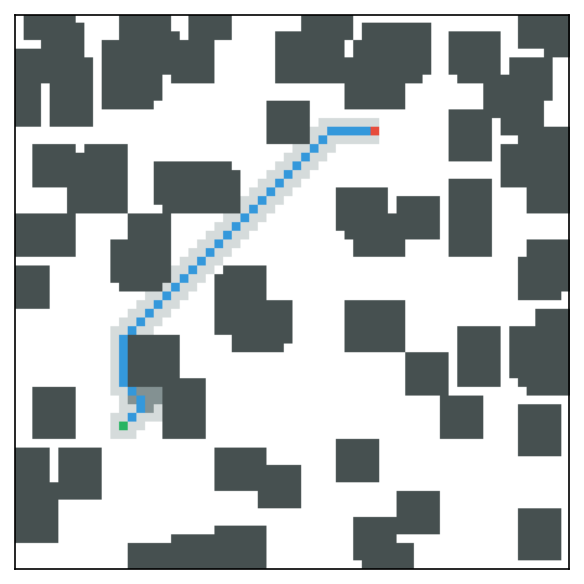

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

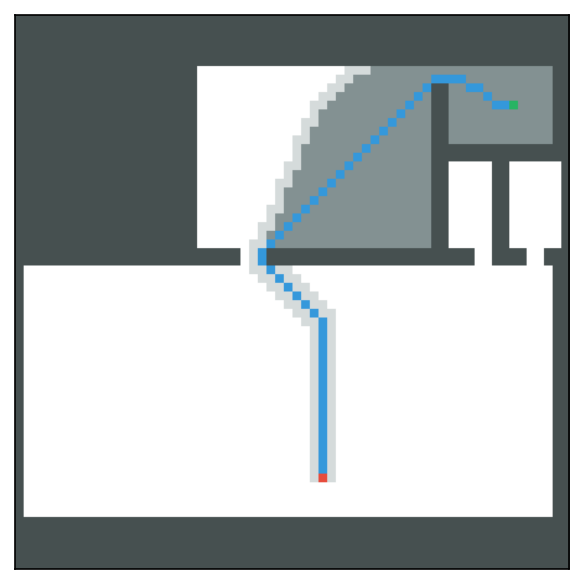

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


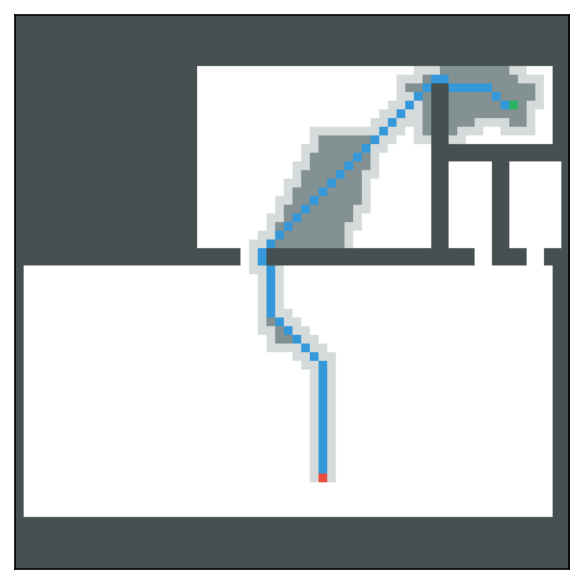

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

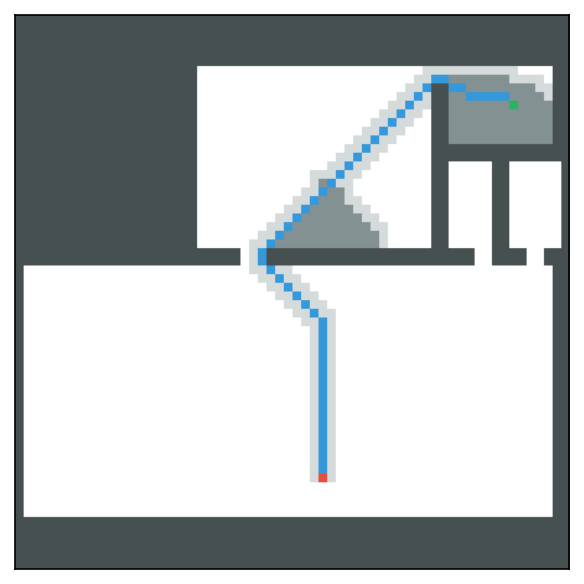

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

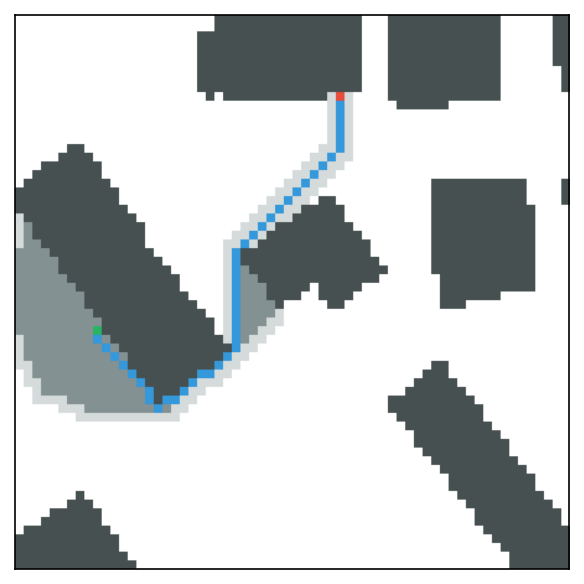

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


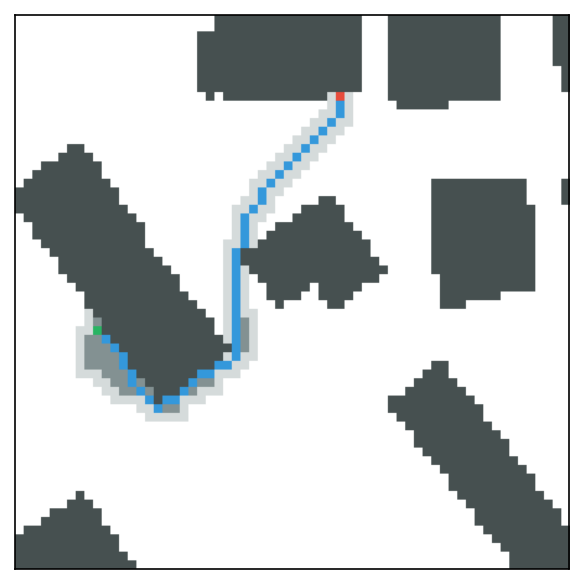

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

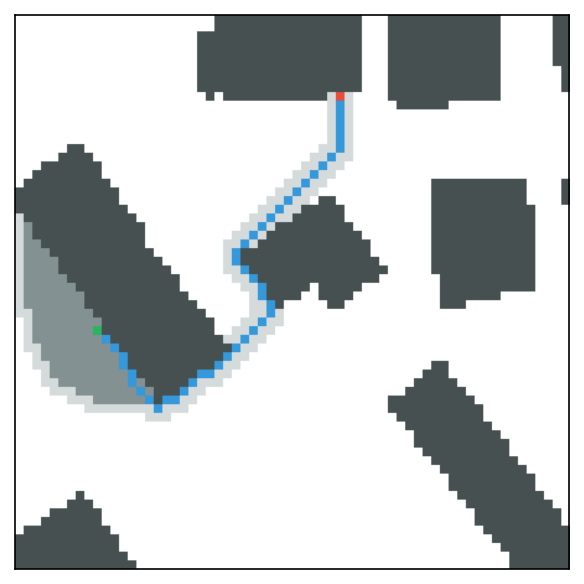

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

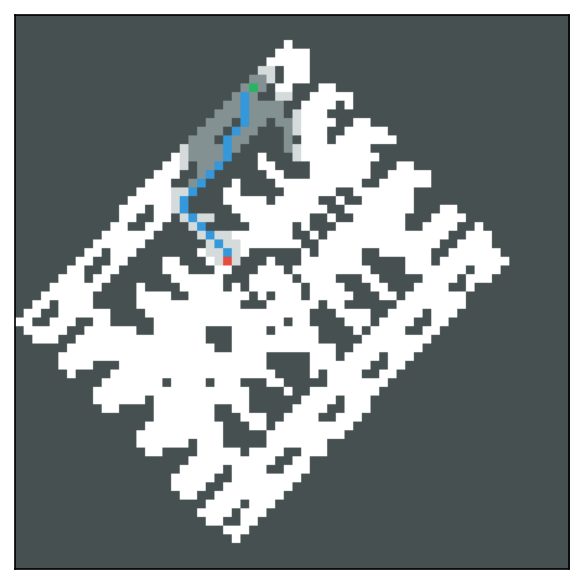

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


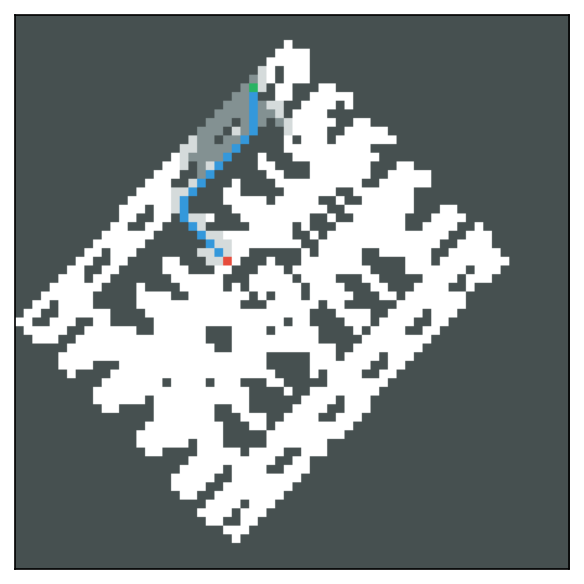

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

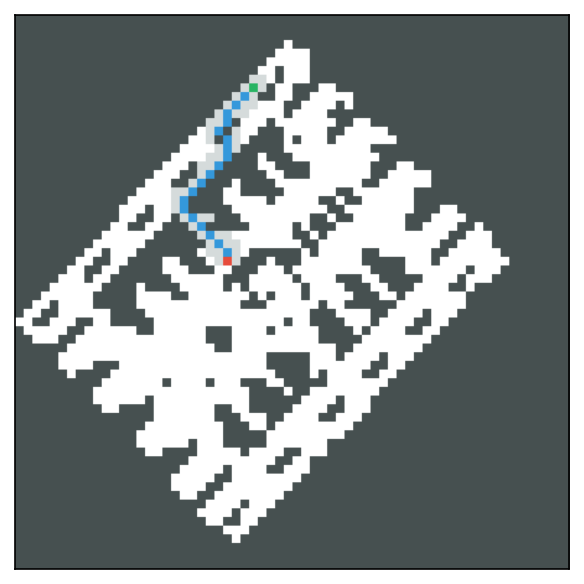

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

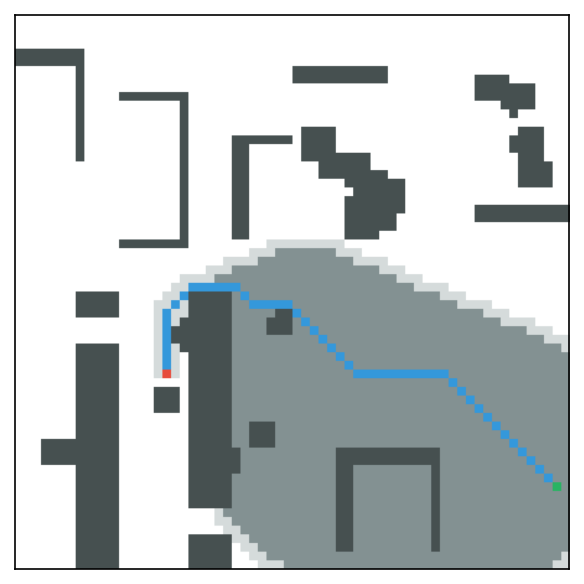

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


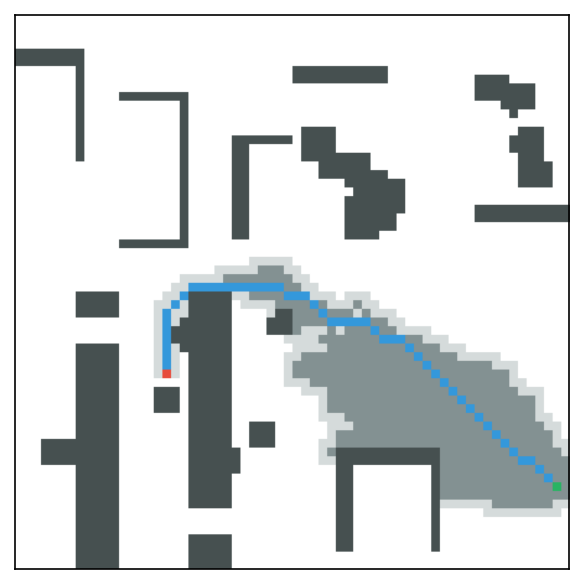

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

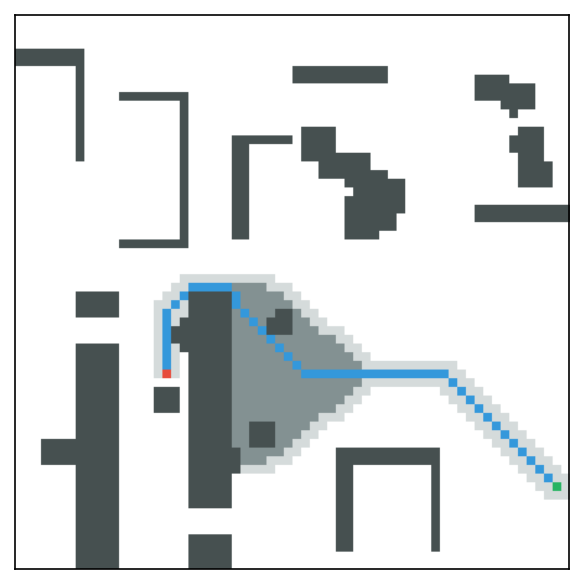

During the search was discovered 0 non-existent paths


In [2]:
model = create_TransPath_model(weights_path='../weights/vesa_russkie', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, ws=[2], threshold=1.05, verbose=2)

In [3]:
import pickle

# Save to a pickle file
with open("../results/TESTSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [6]:
import pickle



# Save to a pickle file
with open("../results/TESTSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model,w=2
Optimal found ratio,100.0%,48.85%,59.05%
Length ratio,100.0±0.0%,100.12±0.15%,100.09±0.12%
Expansions ratio,100.0±0.0%,94.4±16.32%,96.5±3.76%


,baseline,model,w=2
Optimal found ratio,100.0%,20.75%,52.95%
Length ratio,100.0±0.0%,107.25±12.69%,100.76±1.94%
Expansions ratio,100.0±0.0%,59.65±23.0%,92.02±10.69%


,baseline,model,w=2
Optimal found ratio,100.0%,8.8%,12.15%
Length ratio,100.0±0.0%,106.67±7.36%,104.51±4.2%
Expansions ratio,100.0±0.0%,60.12±22.41%,60.6±21.66%


,baseline,model,w=2
Optimal found ratio,100.0%,0.85%,4.25%
Length ratio,100.0±0.0%,114.44±10.98%,108.3±6.4%
Expansions ratio,100.0±0.0%,93.26±51.42%,32.26±17.93%


,baseline,model,w=2
Optimal found ratio,100.0%,0.3%,3.3%
Length ratio,100.0±0.0%,131.34±20.17%,107.1±4.76%
Expansions ratio,100.0±0.0%,97.85±51.36%,30.08±14.75%


,baseline,model,w=2
Optimal found ratio,100.0%,59.35%,34.25%
Length ratio,100.0±0.0%,100.88±1.6%,103.41±4.23%
Expansions ratio,100.0±0.0%,63.39±27.24%,37.4±22.46%


,baseline,model,w=2
Optimal found ratio,100.0%,52.65%,51.55%
Length ratio,100.0±0.0%,101.42±2.26%,102.51±3.68%
Expansions ratio,100.0±0.0%,48.44±22.2%,57.91±24.57%


,baseline,model,w=2
Optimal found ratio,100.0%,49.0%,32.25%
Length ratio,100.0±0.0%,101.47±2.7%,103.73±4.45%
Expansions ratio,100.0±0.0%,58.83±29.26%,41.24±24.93%


,baseline,model,w=2
Optimal found ratio,100.0%,28.9%,34.7%
Length ratio,100.0±0.0%,103.49±4.34%,103.13±3.96%
Expansions ratio,100.0±0.0%,67.35±27.87%,53.19±24.47%


,baseline,model,w=2
Optimal found ratio,100.0%,55.3%,39.05%
Length ratio,100.0±0.0%,101.11±2.22%,103.86±5.18%
Expansions ratio,100.0±0.0%,53.76±28.53%,44.5±26.18%


In [7]:
for res in ress:
    print(*np.array(res['model']))

48.85% 100.12±0.15% 94.4±16.32%
20.75% 107.25±12.69% 59.65±23.0%
8.8% 106.67±7.36% 60.12±22.41%
0.85% 114.44±10.98% 93.26±51.42%
0.3% 131.34±20.17% 97.85±51.36%
59.35% 100.88±1.6% 63.39±27.24%
52.65% 101.42±2.26% 48.44±22.2%
49.0% 101.47±2.7% 58.83±29.26%
28.9% 103.49±4.34% 67.35±27.87%
55.3% 101.11±2.22% 53.76±28.53%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

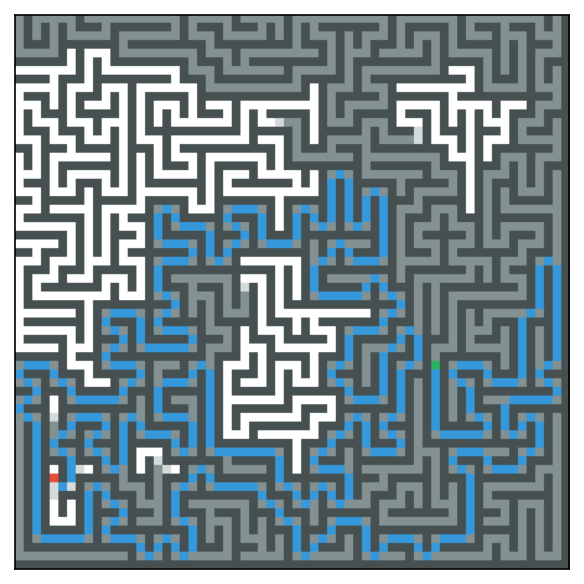

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


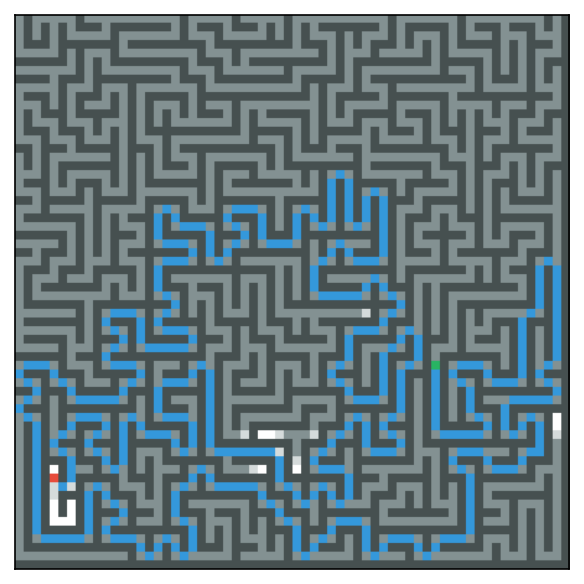

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

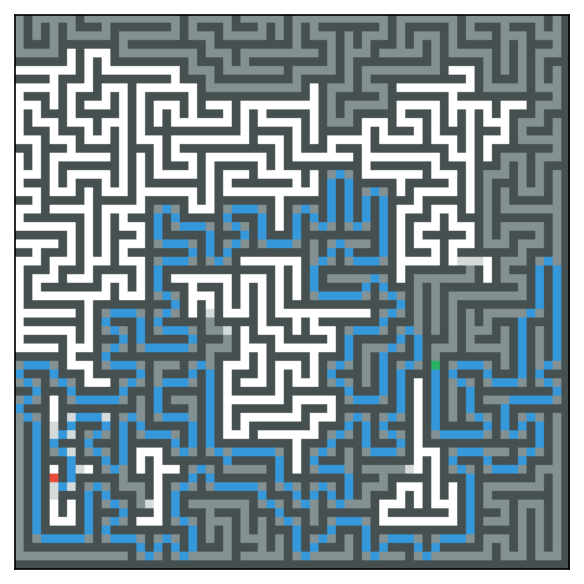

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

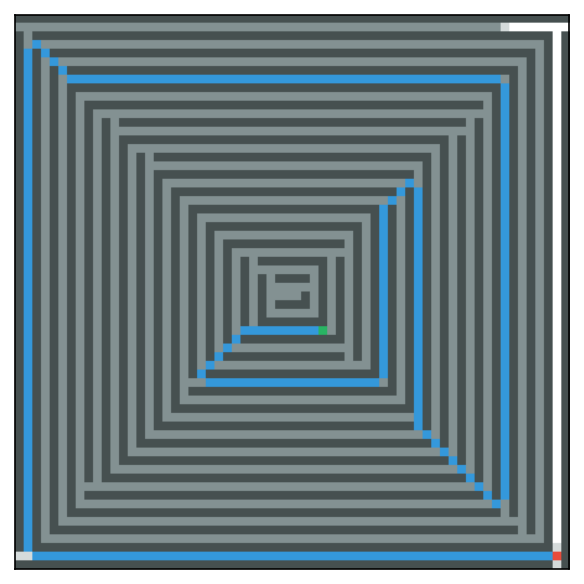

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)
/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


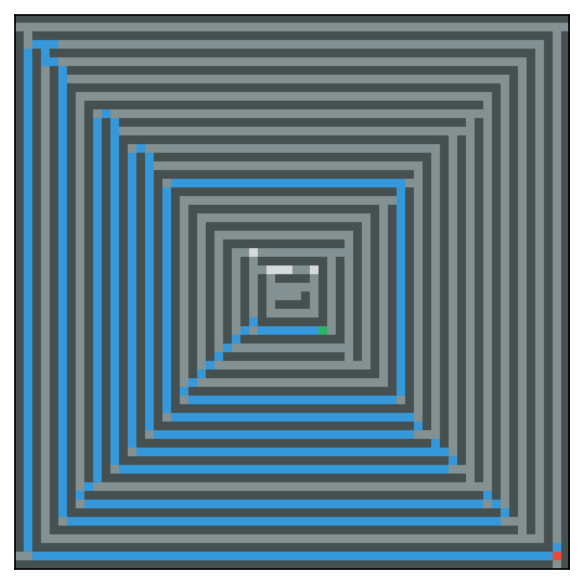

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

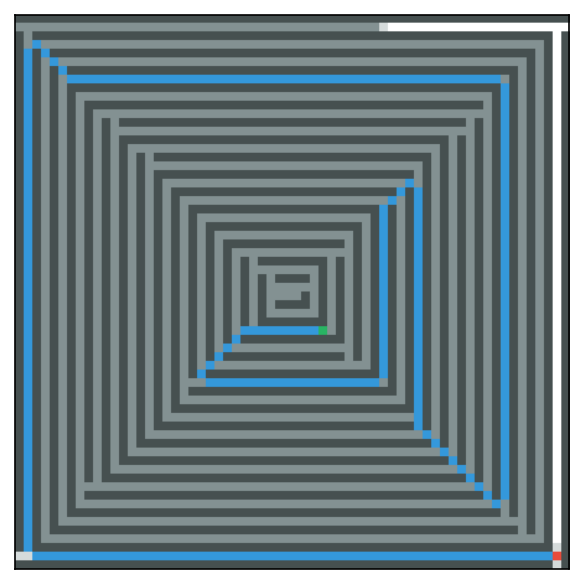

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

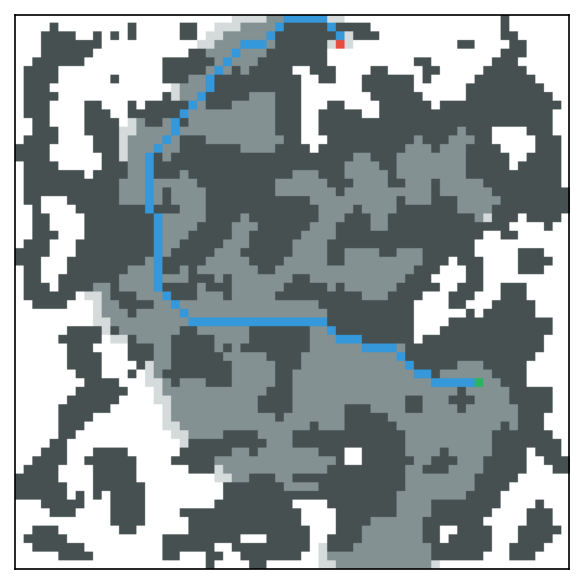

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


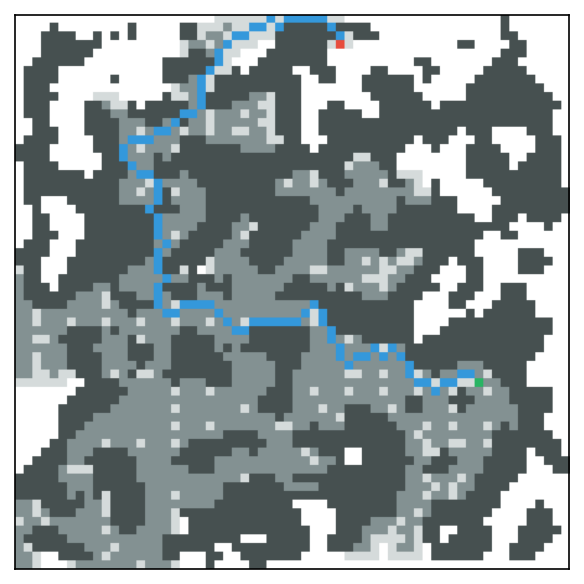

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

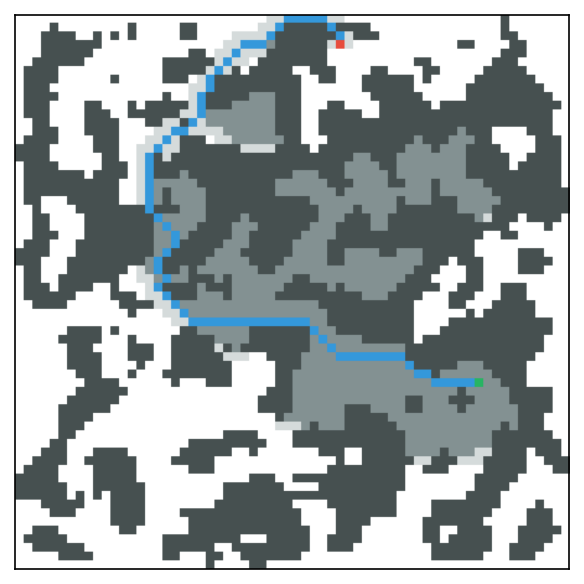

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

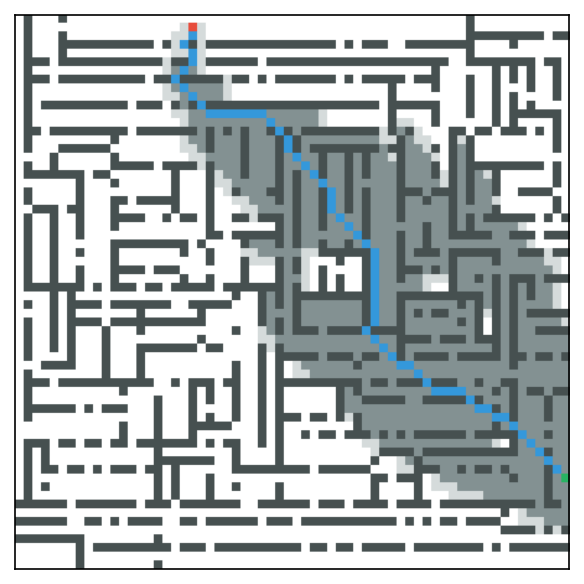

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


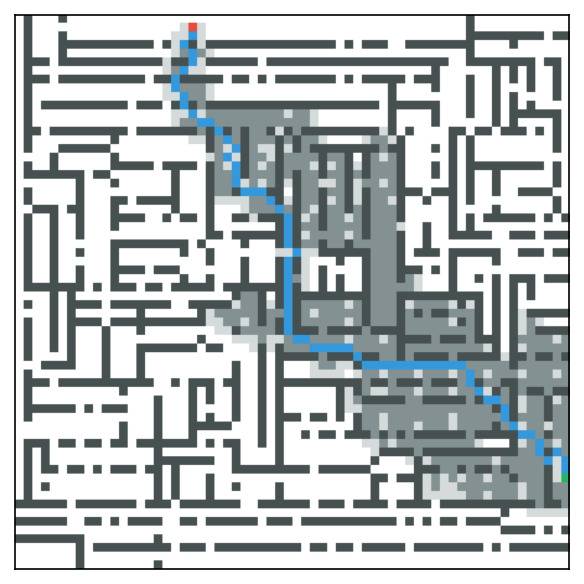

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

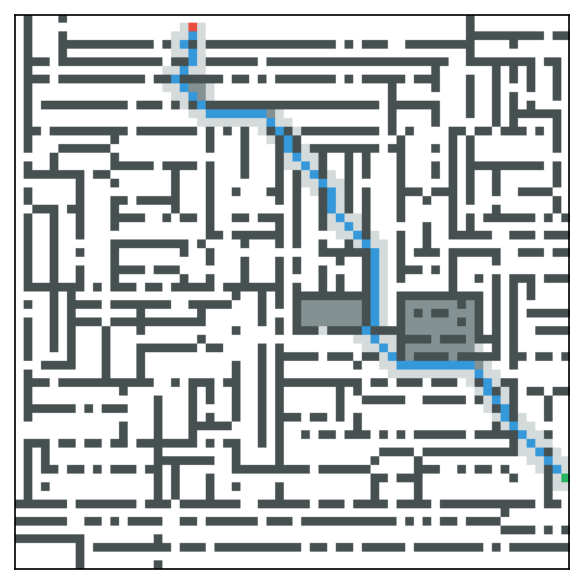

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

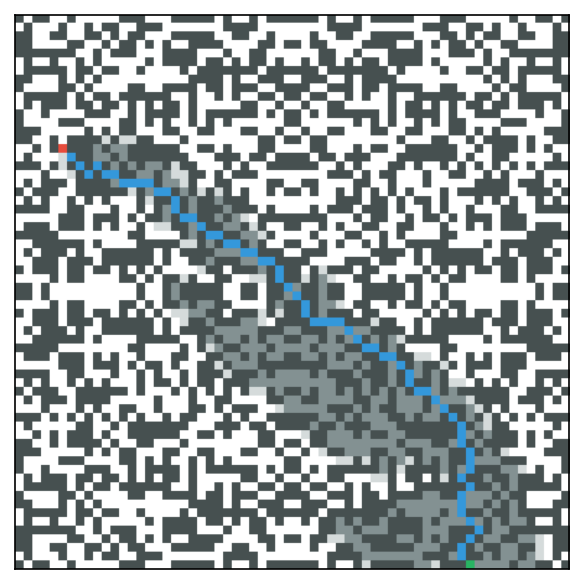

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


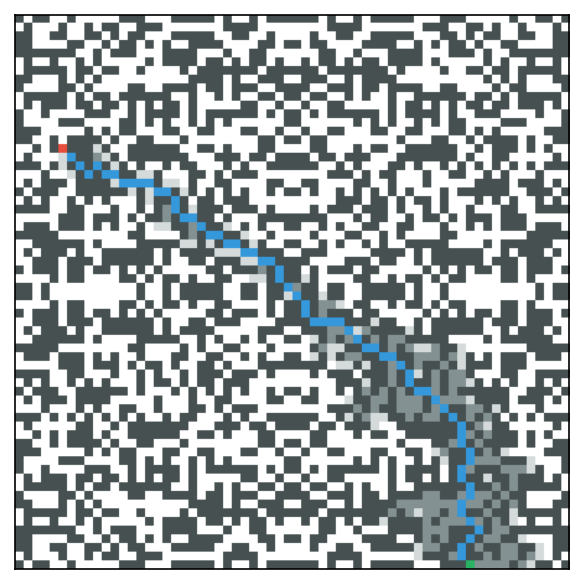

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

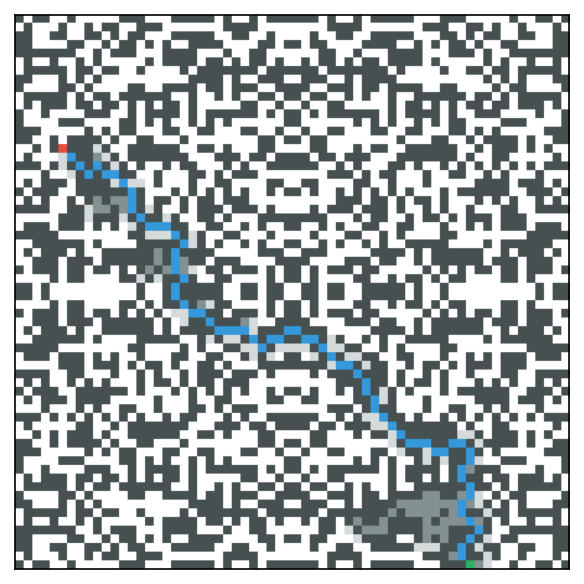

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

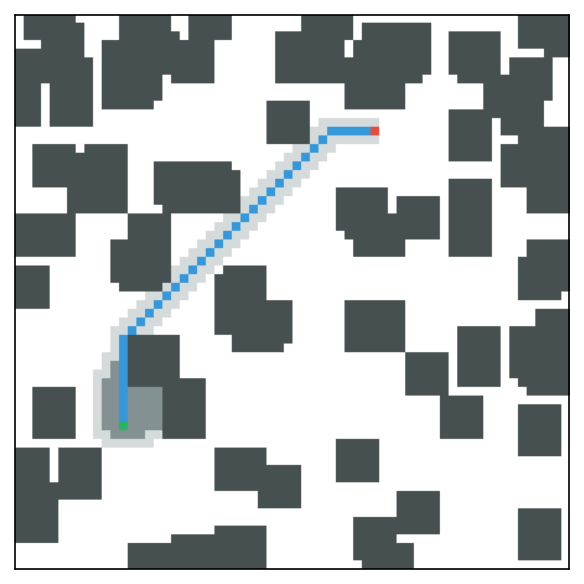

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


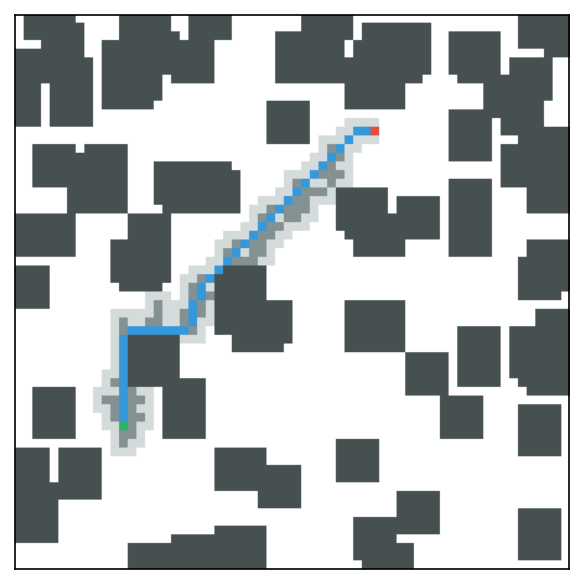

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

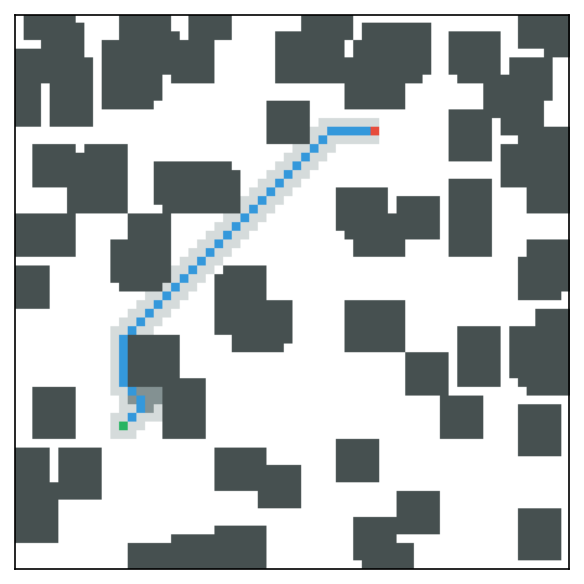

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

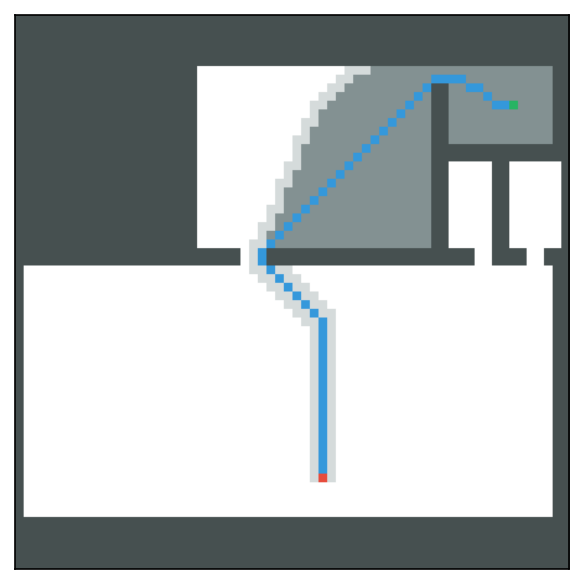

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


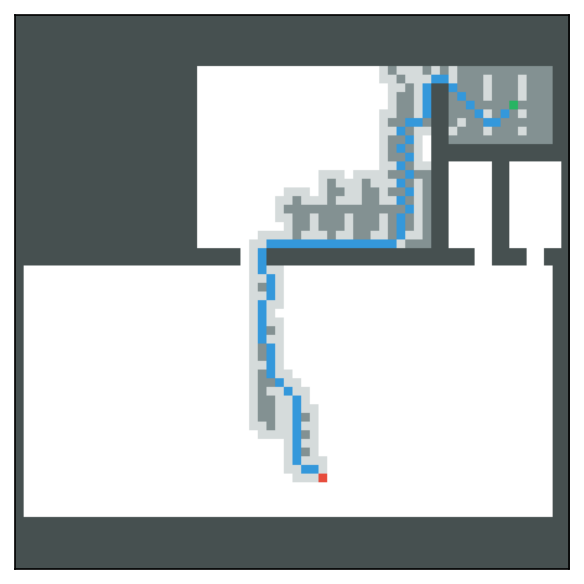

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

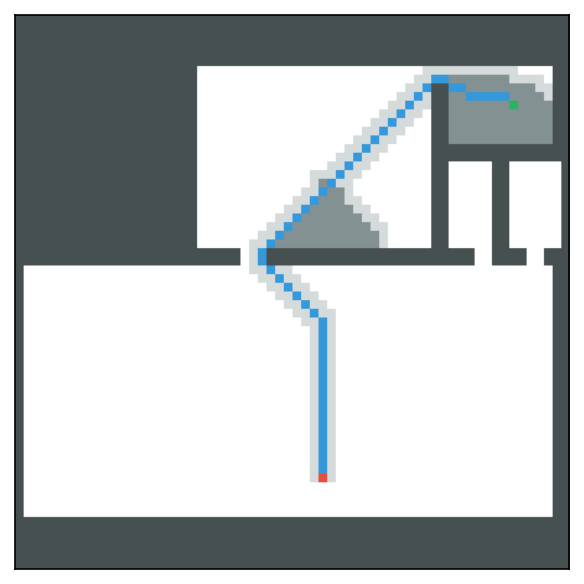

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

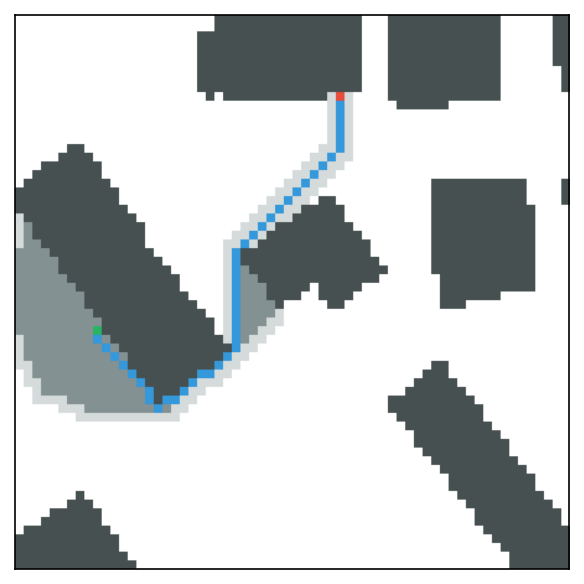

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


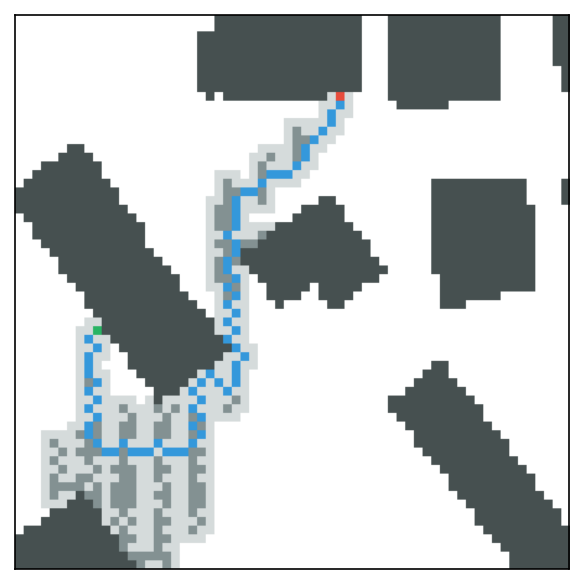

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

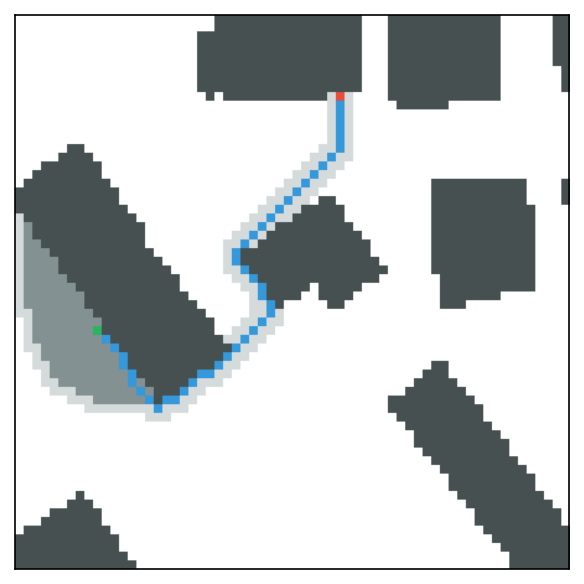

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

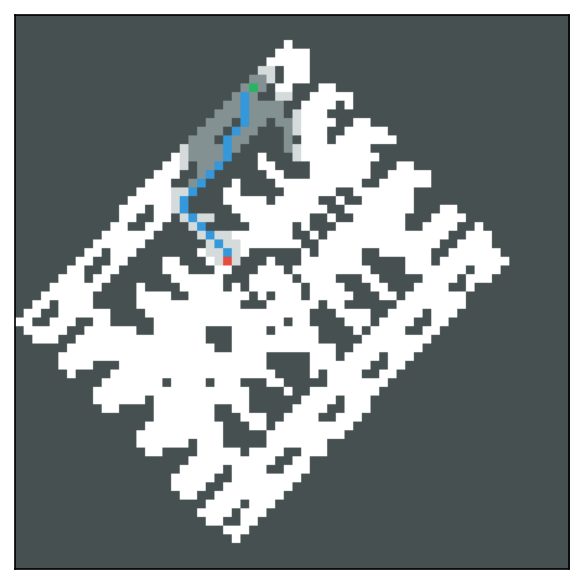

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


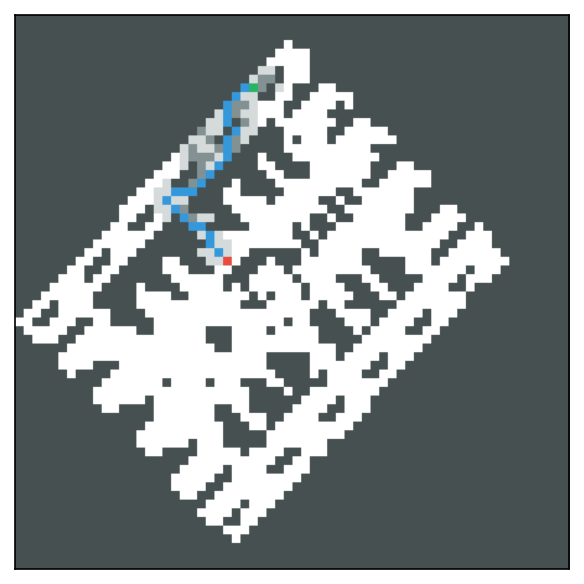

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

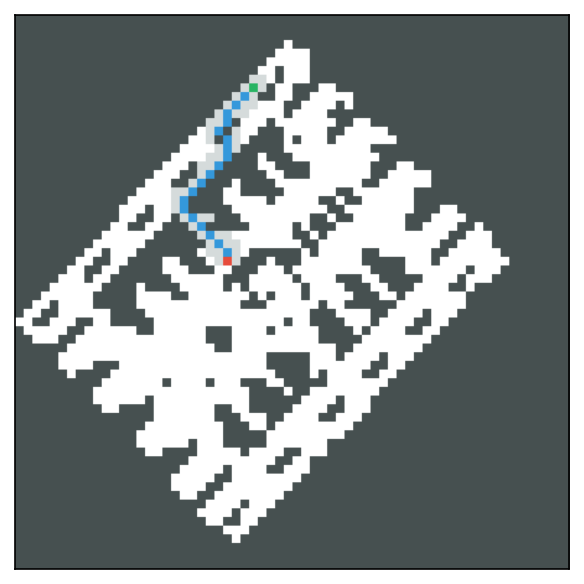

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

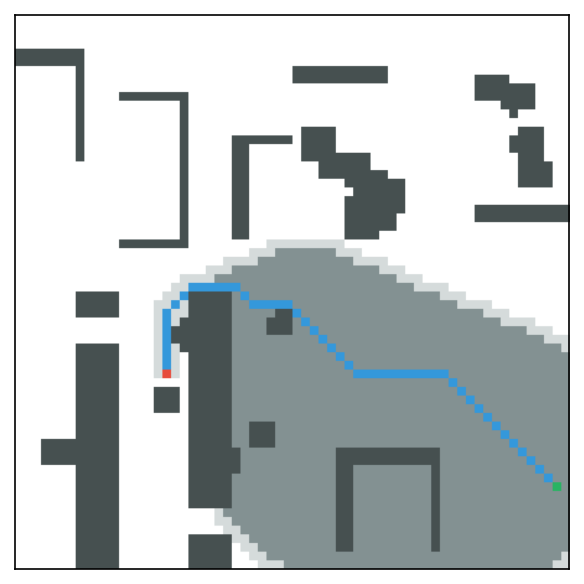

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


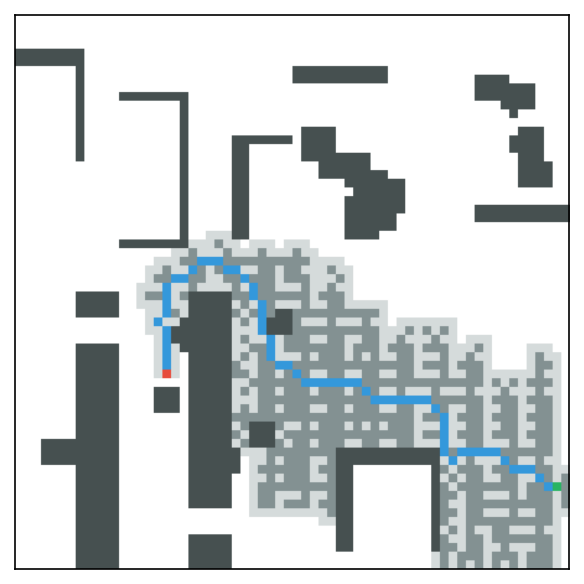

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

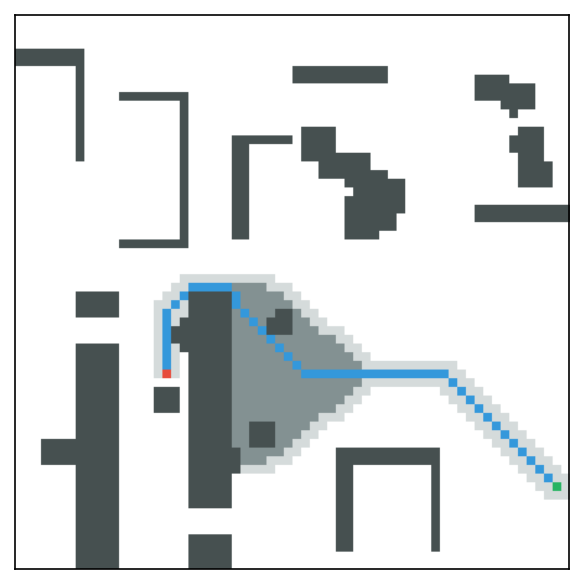

During the search was discovered 0 non-existent paths


In [6]:
model = create_TransPath_model(weights_path='../weights/dumbQRs_big_model_1', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, ws=[2], threshold=1.05, verbose=2)

In [7]:
import pickle

# Save to a pickle file
with open("../results/UNIFORMSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [8]:
import pickle



# Save to a pickle file
with open("../results/UNIFORMSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model,w=2
Optimal found ratio,100.0%,2.45%,59.05%
Length ratio,100.0±0.0%,100.64±0.34%,100.09±0.12%
Expansions ratio,100.0±0.0%,104.47±26.6%,96.5±3.76%


,baseline,model,w=2
Optimal found ratio,100.0%,1.05%,52.95%
Length ratio,100.0±0.0%,198.02±83.85%,100.76±1.94%
Expansions ratio,100.0±0.0%,118.92±64.37%,92.02±10.69%


,baseline,model,w=2
Optimal found ratio,100.0%,0.9%,12.15%
Length ratio,100.0±0.0%,118.43±13.83%,104.51±4.2%
Expansions ratio,100.0±0.0%,76.18±32.02%,60.6±21.66%


,baseline,model,w=2
Optimal found ratio,100.0%,0.2%,4.25%
Length ratio,100.0±0.0%,116.73±11.61%,108.3±6.4%
Expansions ratio,100.0±0.0%,93.75±76.53%,32.26±17.93%


,baseline,model,w=2
Optimal found ratio,100.0%,8.3%,3.3%
Length ratio,100.0±0.0%,104.81±4.13%,107.1±4.76%
Expansions ratio,100.0±0.0%,57.86±17.14%,30.08±14.75%


,baseline,model,w=2
Optimal found ratio,100.0%,0.3%,34.25%
Length ratio,100.0±0.0%,128.93±23.33%,103.41±4.23%
Expansions ratio,100.0±0.0%,115.12±92.55%,37.4±22.46%


,baseline,model,w=2
Optimal found ratio,100.0%,0.5%,51.55%
Length ratio,100.0±0.0%,124.76±25.05%,102.51±3.68%
Expansions ratio,100.0±0.0%,85.85±83.95%,57.91±24.57%


,baseline,model,w=2
Optimal found ratio,100.0%,0.2%,32.25%
Length ratio,100.0±0.0%,129.14±24.83%,103.73±4.45%
Expansions ratio,100.0±0.0%,106.28±91.1%,41.24±24.93%


,baseline,model,w=2
Optimal found ratio,100.0%,0.15%,34.7%
Length ratio,100.0±0.0%,137.09±31.5%,103.13±3.96%
Expansions ratio,100.0±0.0%,132.73±134.61%,53.19±24.47%


,baseline,model,w=2
Optimal found ratio,100.0%,0.0%,39.05%
Length ratio,100.0±0.0%,139.98±29.59%,103.86±5.18%
Expansions ratio,100.0±0.0%,132.7±138.27%,44.5±26.18%


In [13]:
for res in ress:
    print(*np.array(res['model']))

2.45% 100.64±0.34% 104.47±26.6%
1.05% 198.02±83.85% 118.92±64.37%
0.9% 118.43±13.83% 76.18±32.02%
0.2% 116.73±11.61% 93.75±76.53%
8.3% 104.81±4.13% 57.86±17.14%
0.3% 128.93±23.33% 115.12±92.55%
0.5% 124.76±25.05% 85.85±83.95%
0.2% 129.14±24.83% 106.28±91.1%
0.15% 137.09±31.5% 132.73±134.61%
0.0% 139.98±29.59% 132.7±138.27%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

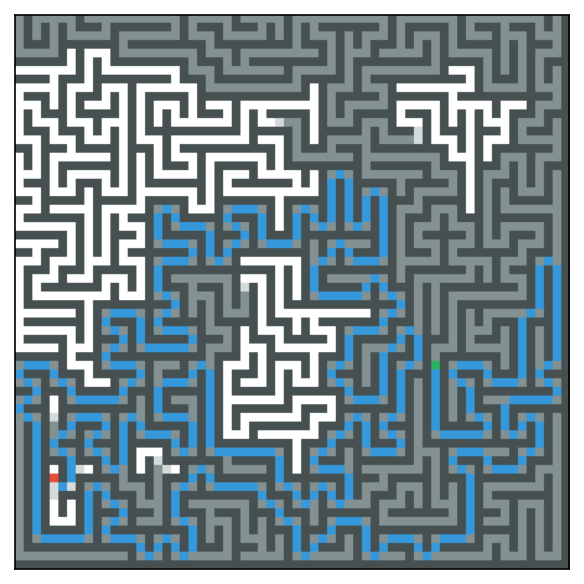

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


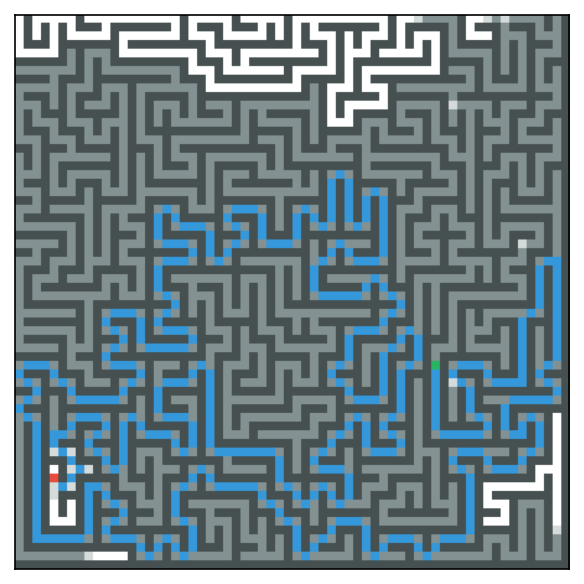

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

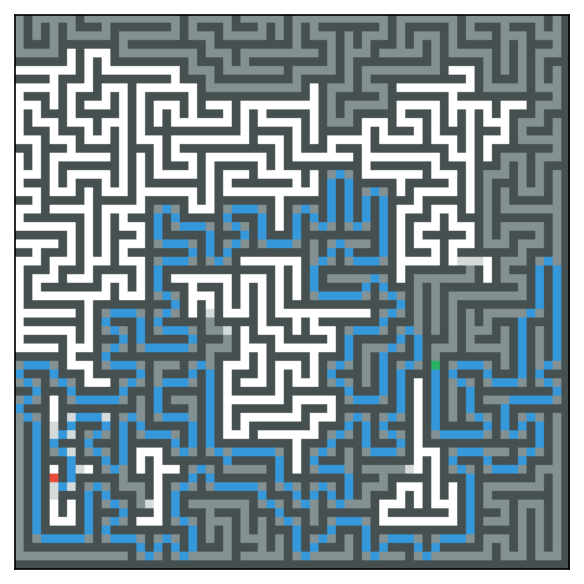

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

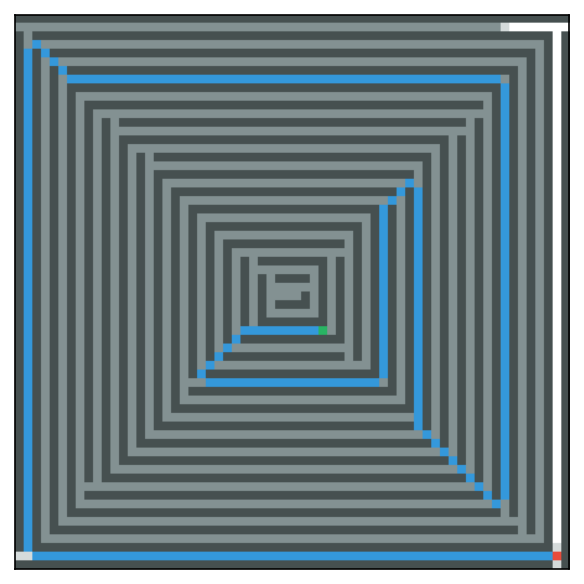

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


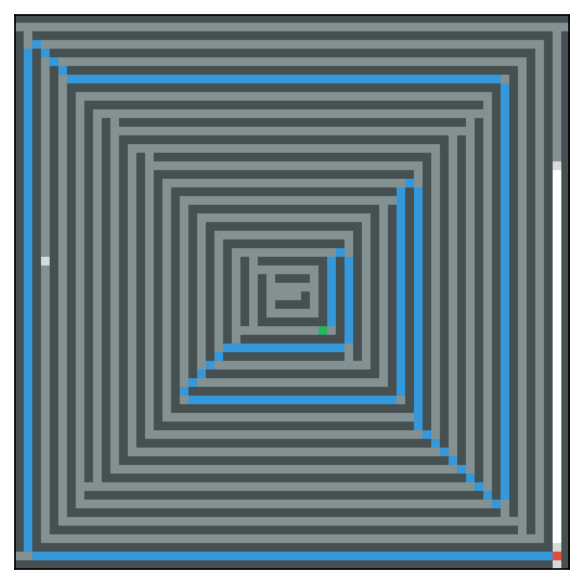

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

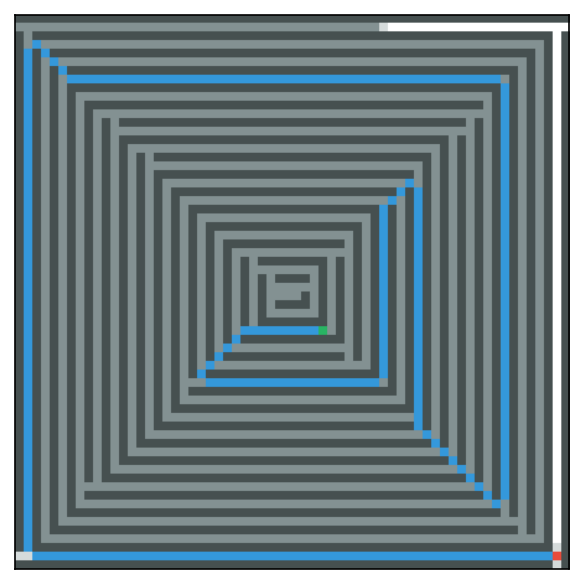

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

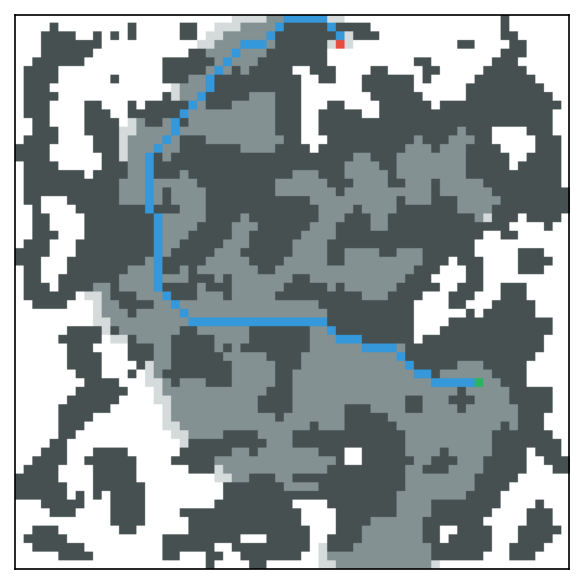

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


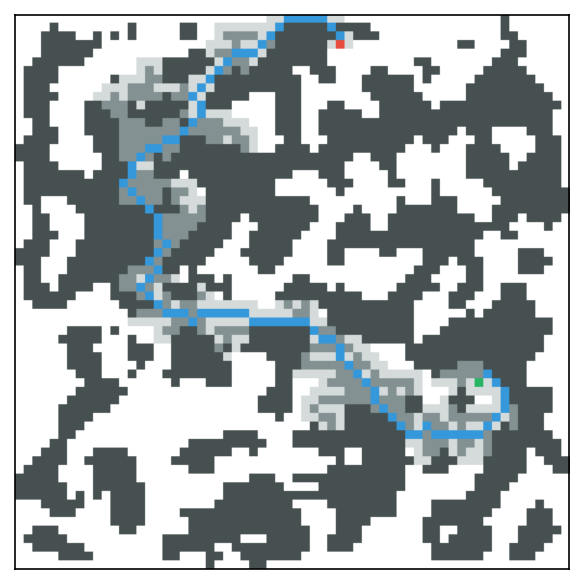

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

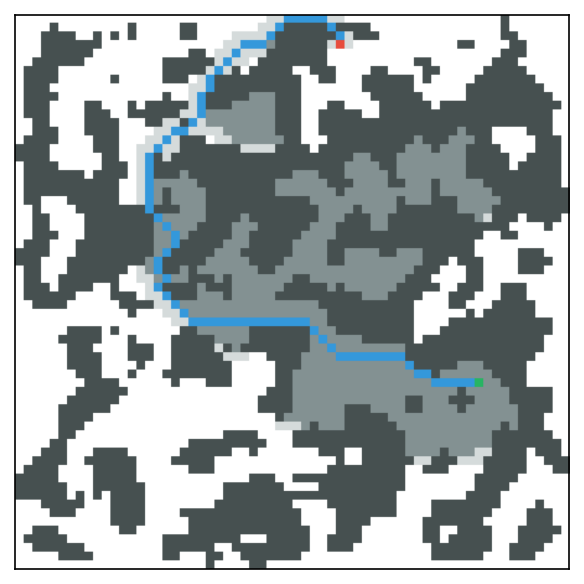

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

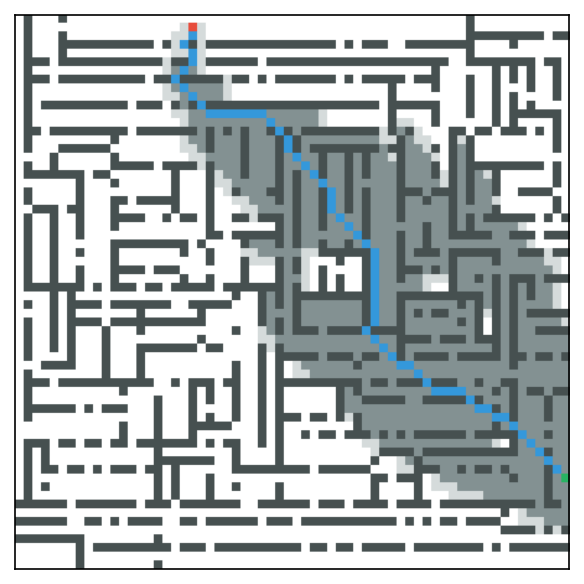

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


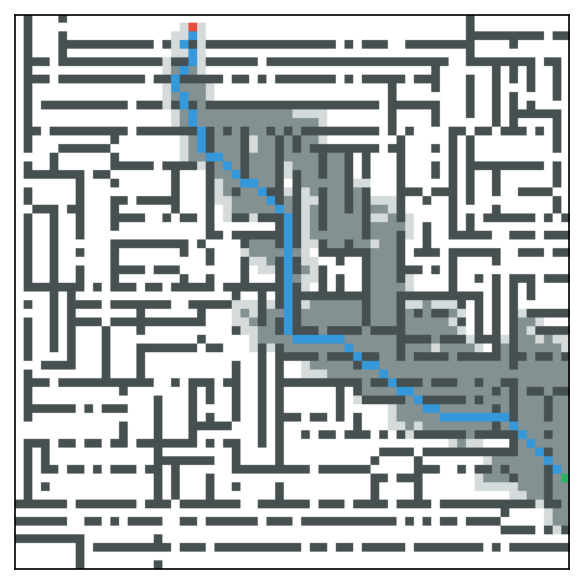

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

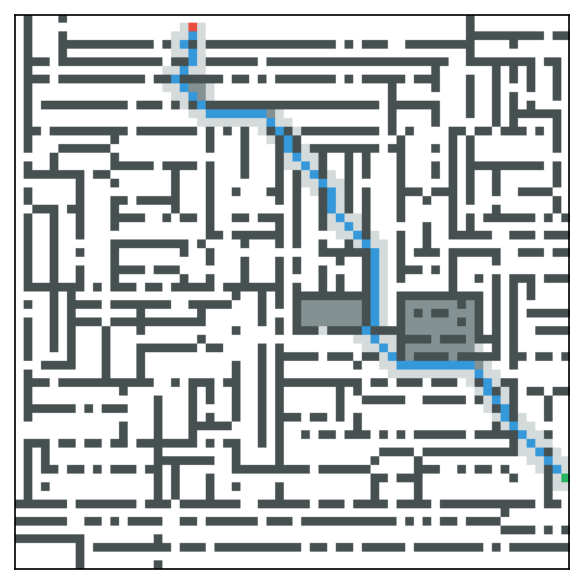

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

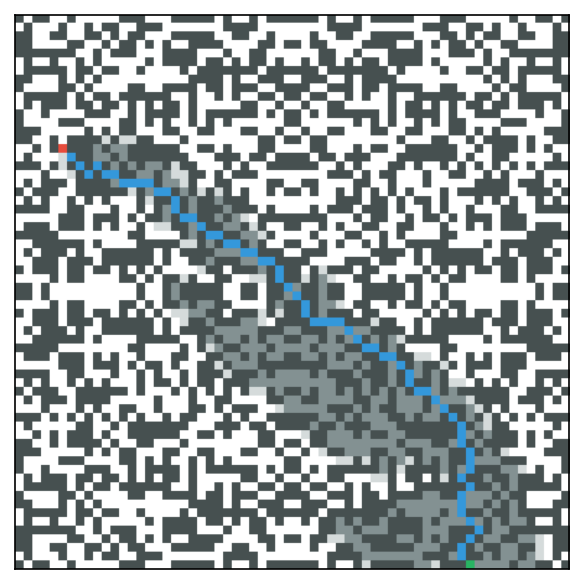

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


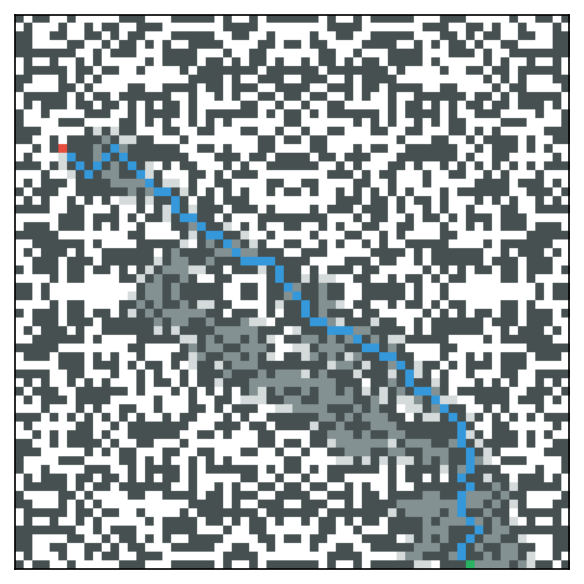

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

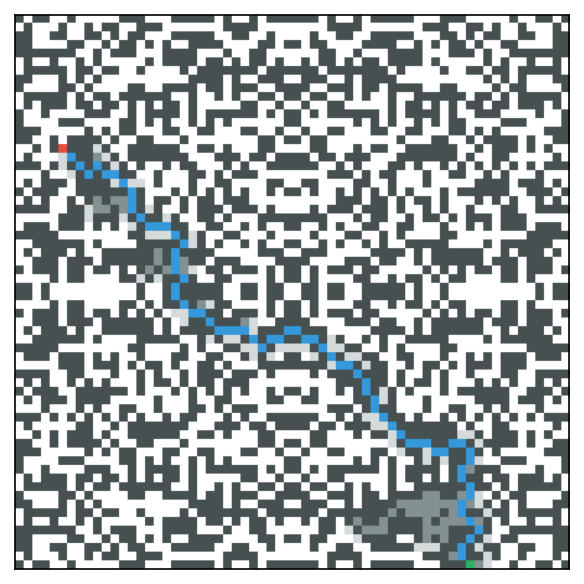

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

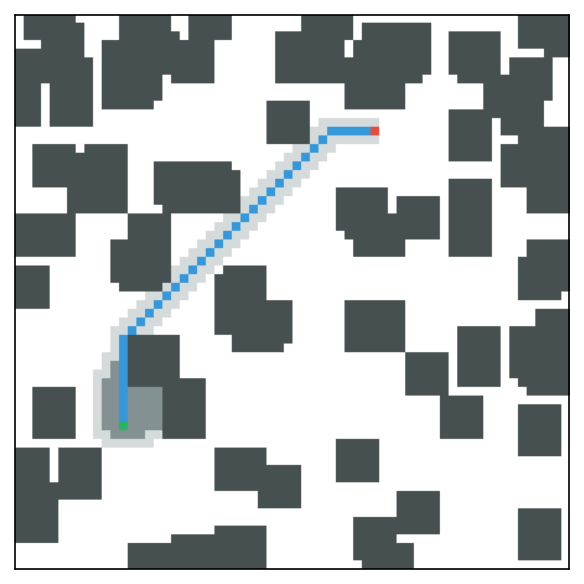

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


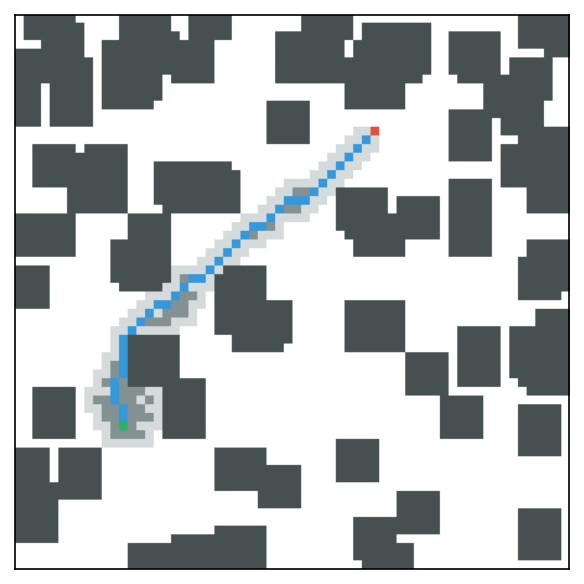

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

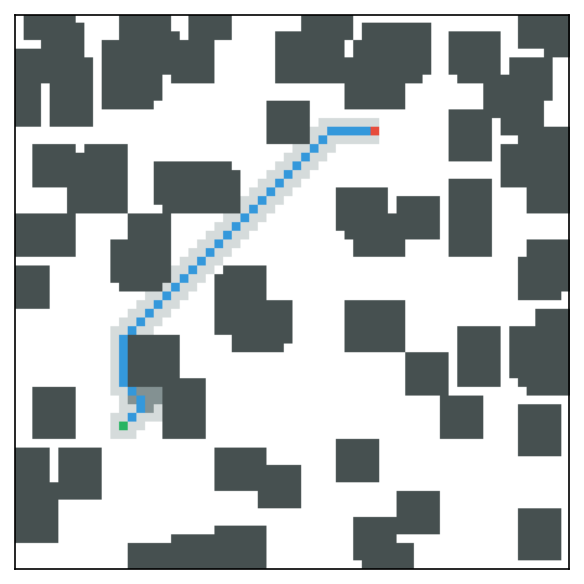

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

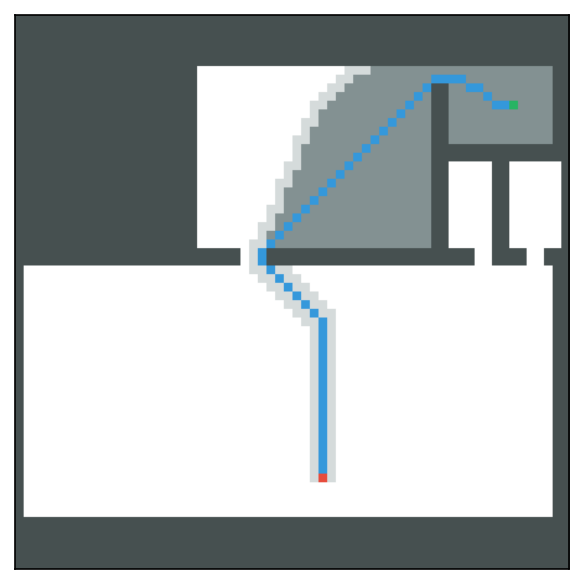

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


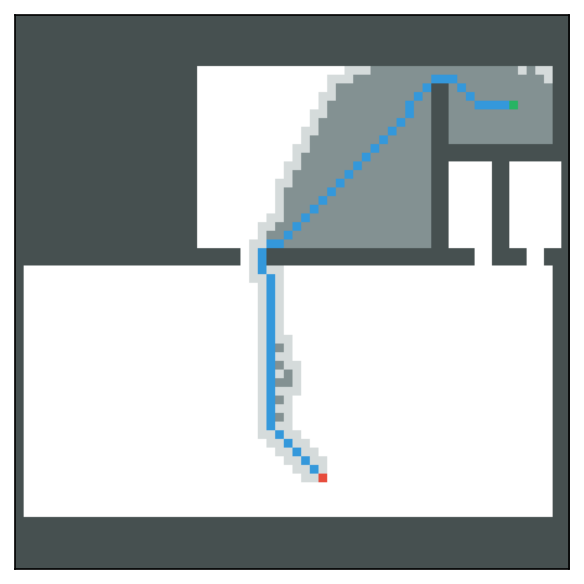

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

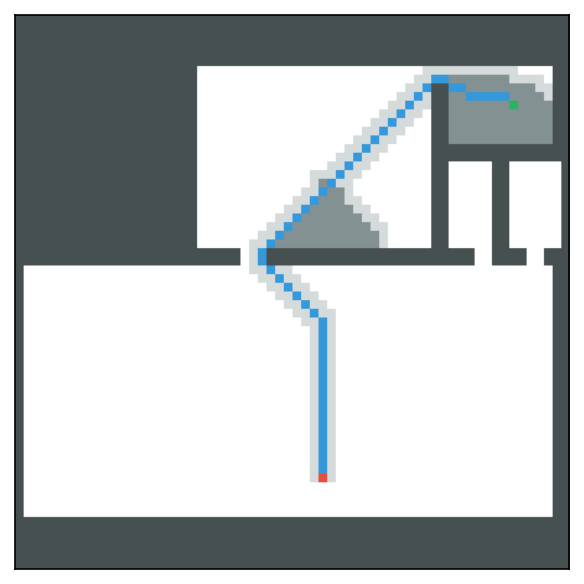

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

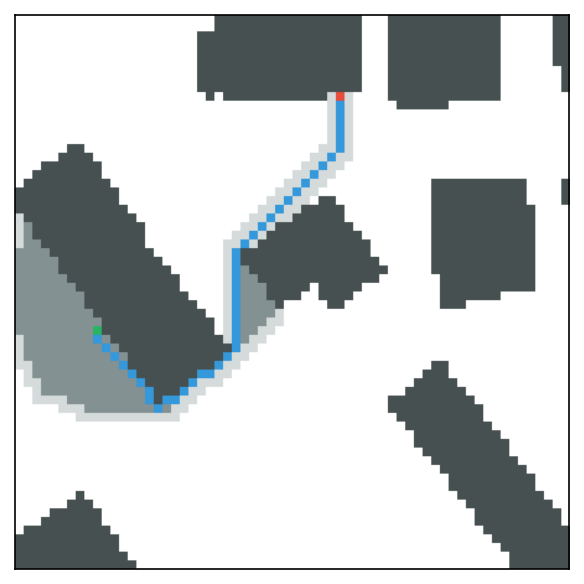

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


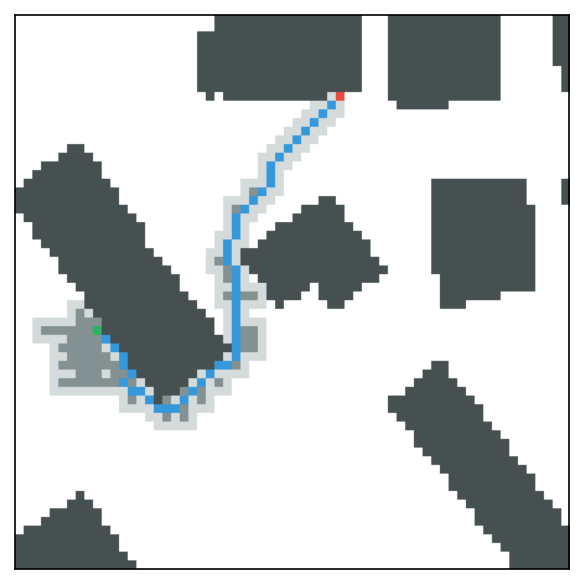

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

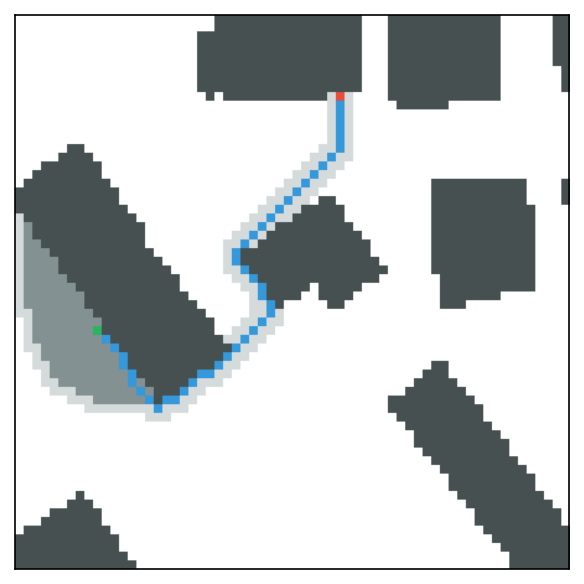

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

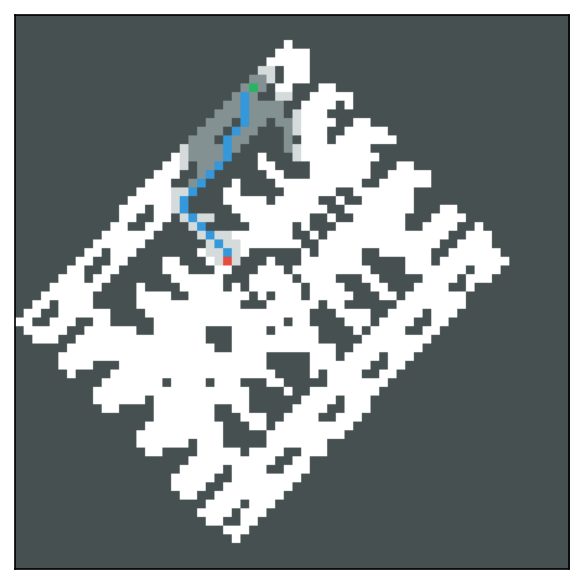

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


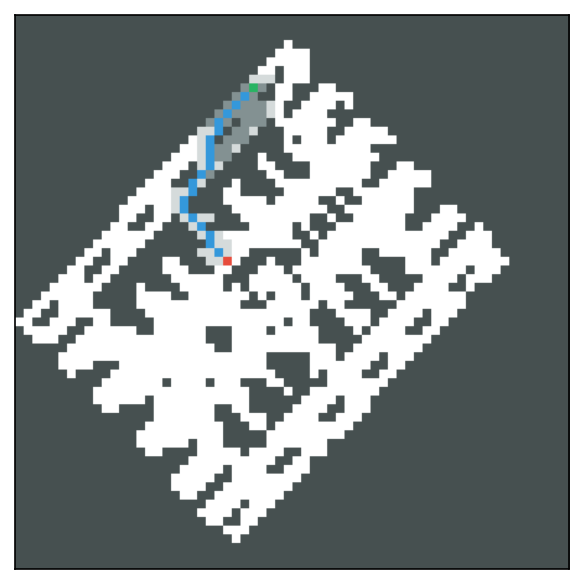

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

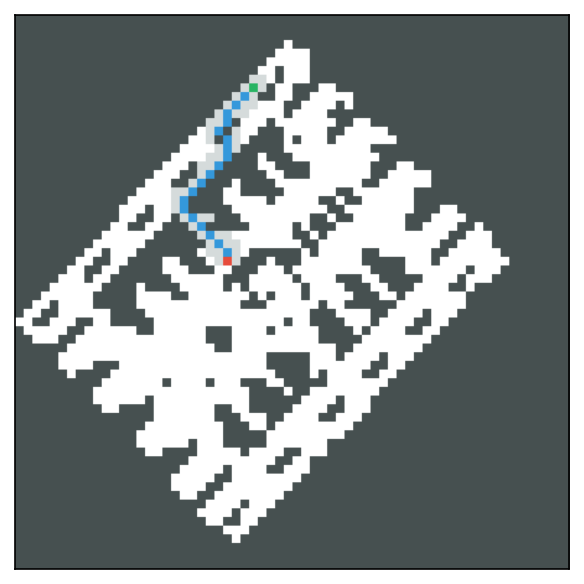

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

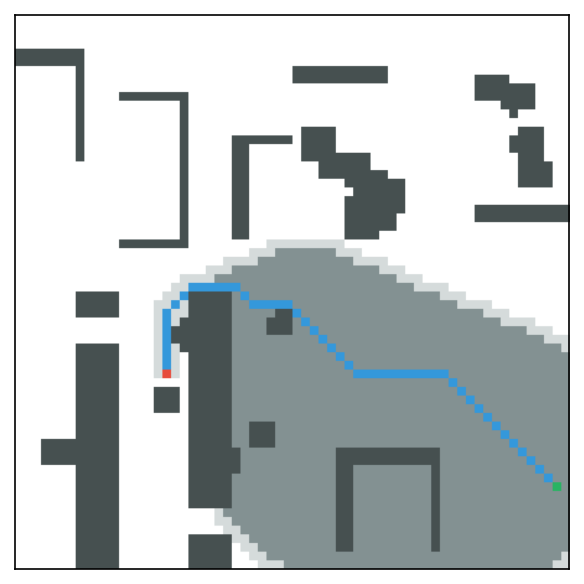

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


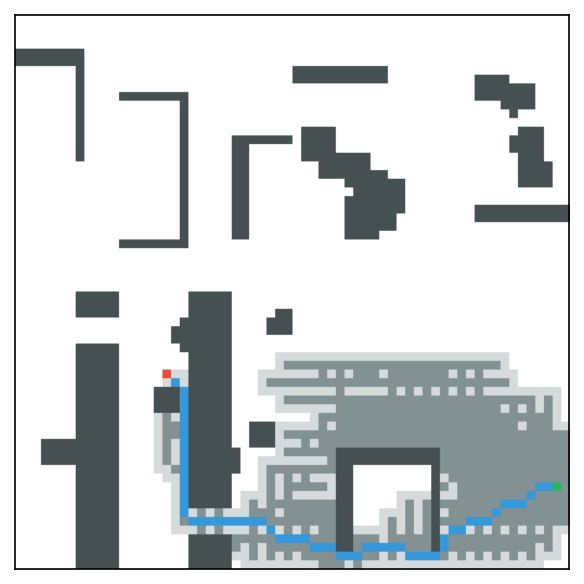

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

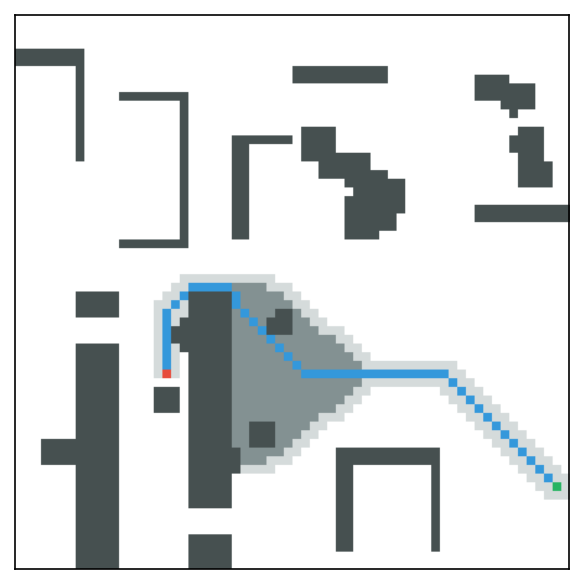

During the search was discovered 0 non-existent paths


In [3]:
model = create_TransPath_model(weights_path='../weights/QRs_big_model_2', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, ws=[2], threshold=1.05, verbose=2)

In [4]:
import pickle

# Save to a pickle file
with open("../results/QRSSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [5]:
import pickle



# Save to a pickle file
with open("../results/QRSSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model,w=2
Optimal found ratio,100.0%,0.25%,59.05%
Length ratio,100.0±0.0%,102.99±1.77%,100.09±0.12%
Expansions ratio,100.0±0.0%,101.71±29.34%,96.5±3.76%


,baseline,model,w=2
Optimal found ratio,100.0%,8.55%,52.95%
Length ratio,100.0±0.0%,128.64±32.17%,100.76±1.94%
Expansions ratio,100.0±0.0%,96.2±49.81%,92.02±10.69%


,baseline,model,w=2
Optimal found ratio,100.0%,6.4%,12.15%
Length ratio,100.0±0.0%,110.82±10.79%,104.51±4.2%
Expansions ratio,100.0±0.0%,53.56±19.52%,60.6±21.66%


,baseline,model,w=2
Optimal found ratio,100.0%,11.65%,4.25%
Length ratio,100.0±0.0%,104.47±4.93%,108.3±6.4%
Expansions ratio,100.0±0.0%,57.34±22.31%,32.26±17.93%


,baseline,model,w=2
Optimal found ratio,100.0%,18.2%,3.3%
Length ratio,100.0±0.0%,102.96±2.98%,107.1±4.76%
Expansions ratio,100.0±0.0%,44.85±15.35%,30.08±14.75%


,baseline,model,w=2
Optimal found ratio,100.0%,12.65%,34.25%
Length ratio,100.0±0.0%,105.27±5.76%,103.41±4.23%
Expansions ratio,100.0±0.0%,71.28±41.01%,37.4±22.46%


,baseline,model,w=2
Optimal found ratio,100.0%,48.35%,51.55%
Length ratio,100.0±0.0%,101.92±3.26%,102.51±3.68%
Expansions ratio,100.0±0.0%,82.87±46.77%,57.91±24.57%


,baseline,model,w=2
Optimal found ratio,100.0%,11.65%,32.25%
Length ratio,100.0±0.0%,105.84±5.98%,103.73±4.45%
Expansions ratio,100.0±0.0%,63.35±62.67%,41.24±24.93%


,baseline,model,w=2
Optimal found ratio,100.0%,21.65%,34.7%
Length ratio,100.0±0.0%,105.55±8.5%,103.13±3.96%
Expansions ratio,100.0±0.0%,75.94±27.21%,53.19±24.47%


,baseline,model,w=2
Optimal found ratio,100.0%,11.9%,39.05%
Length ratio,100.0±0.0%,107.19±7.64%,103.86±5.18%
Expansions ratio,100.0±0.0%,78.2±63.09%,44.5±26.18%


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

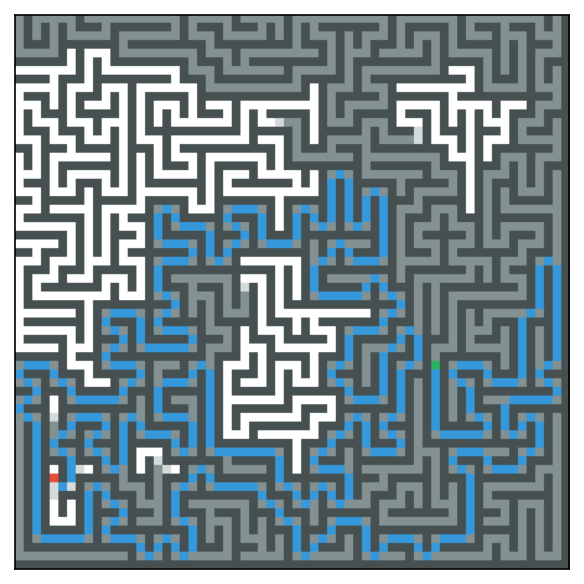

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


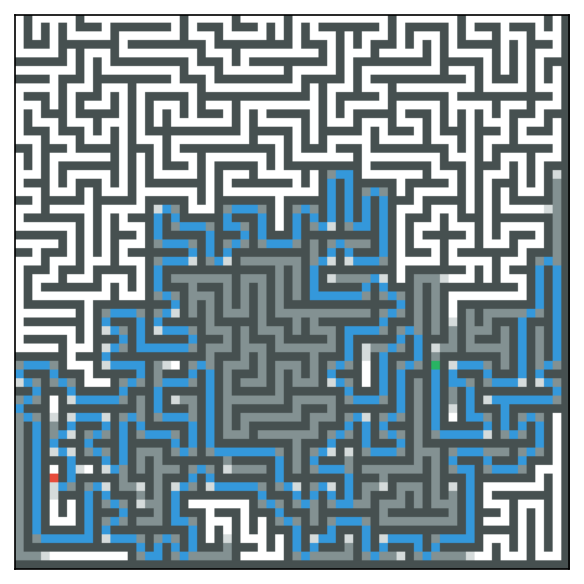

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

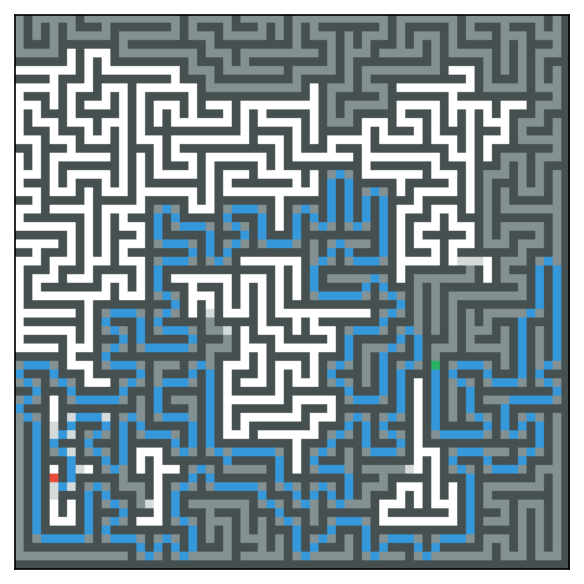

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

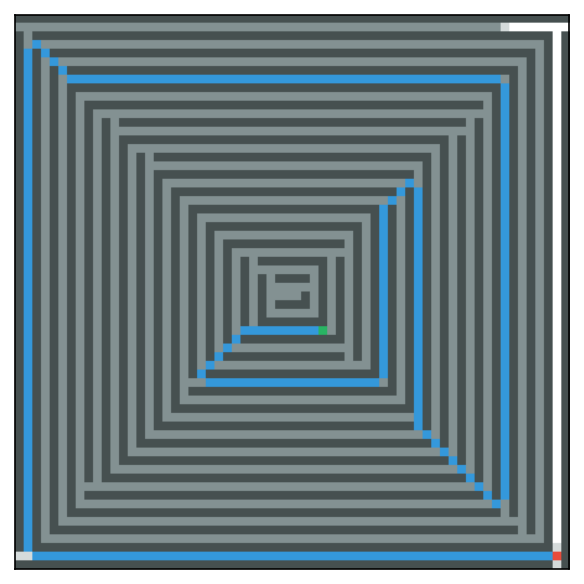

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


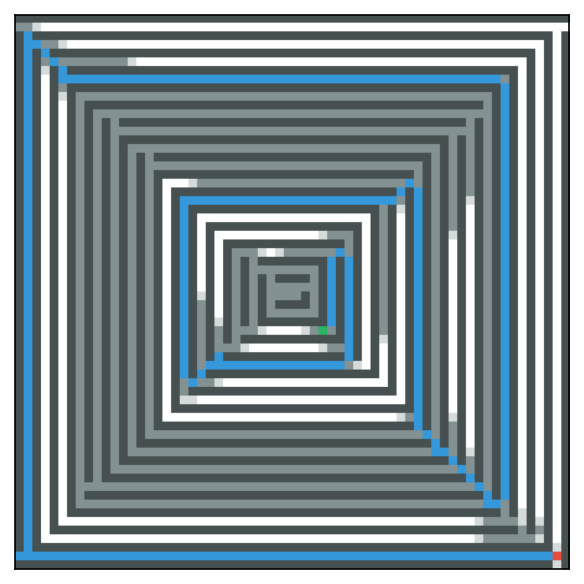

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

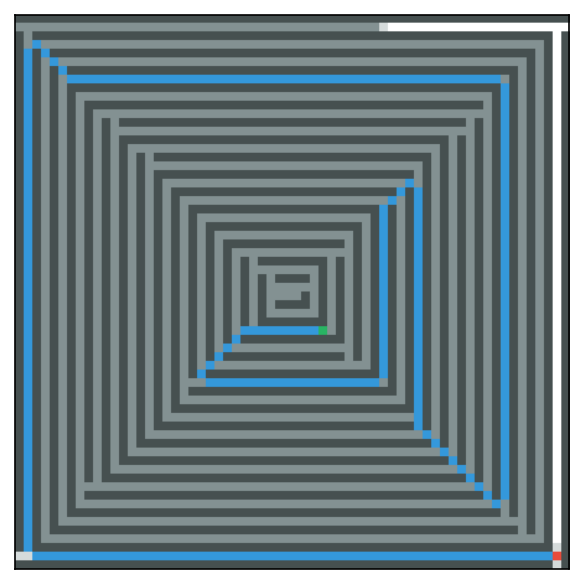

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

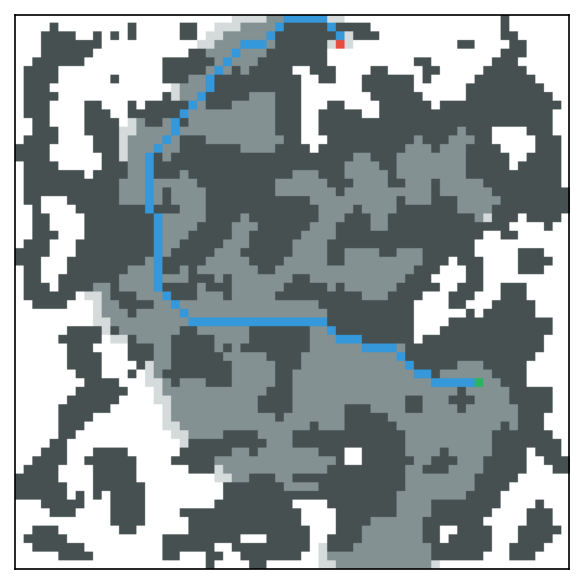

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


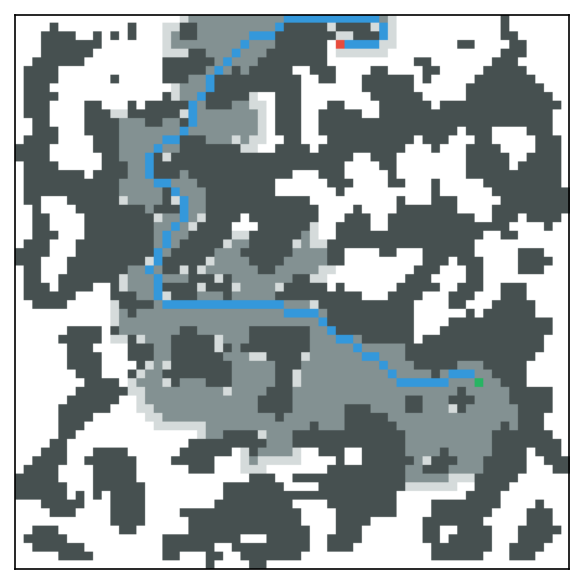

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

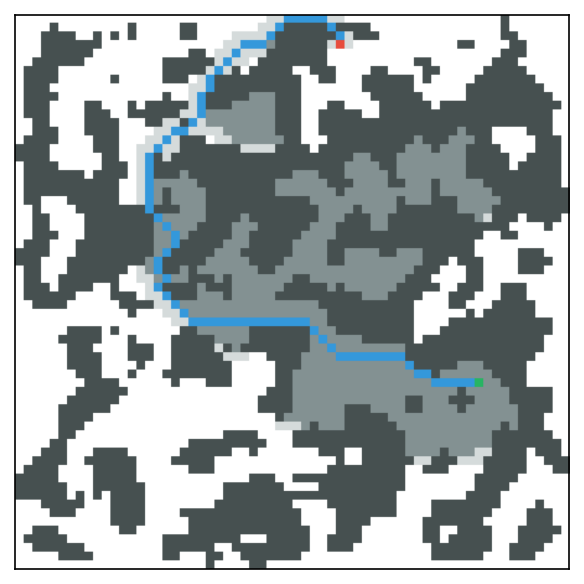

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

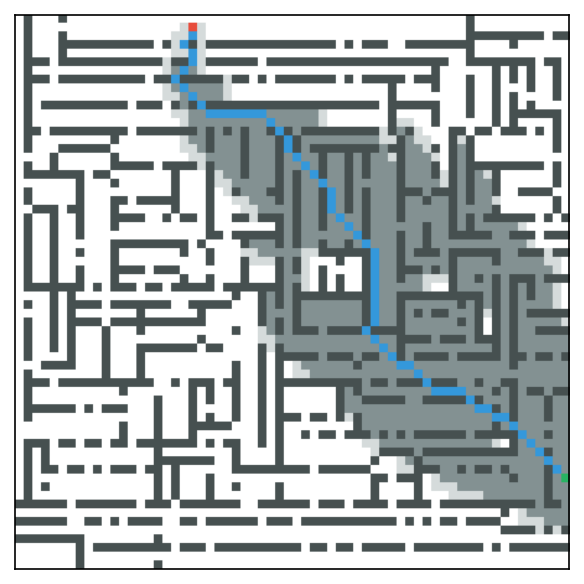

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


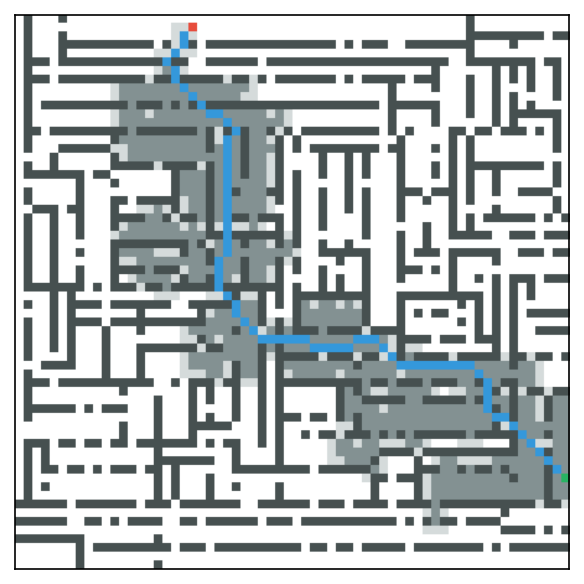

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

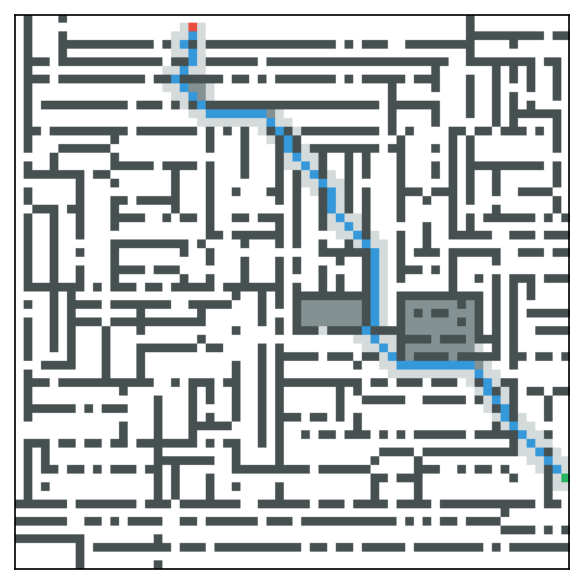

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

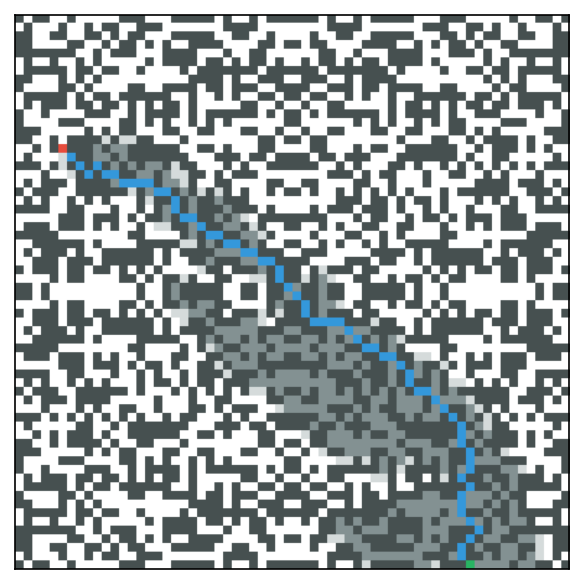

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


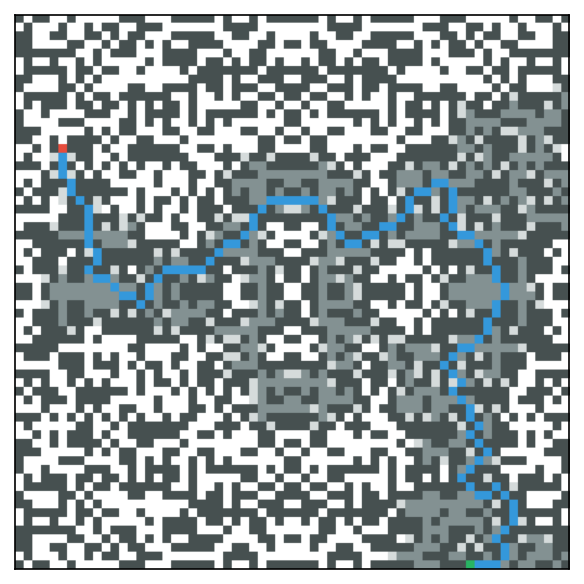

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

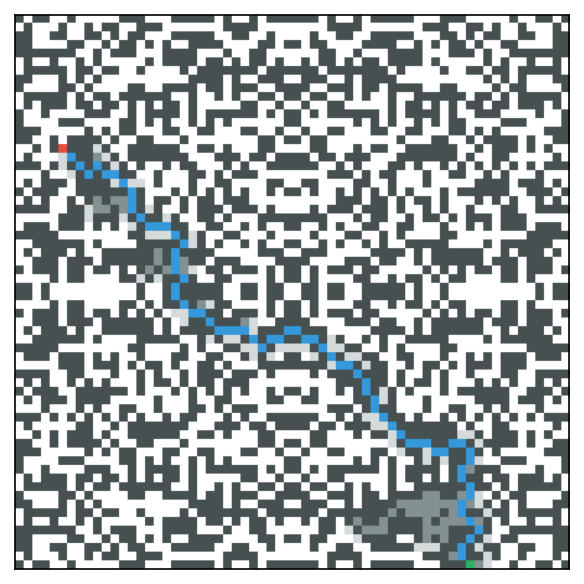

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

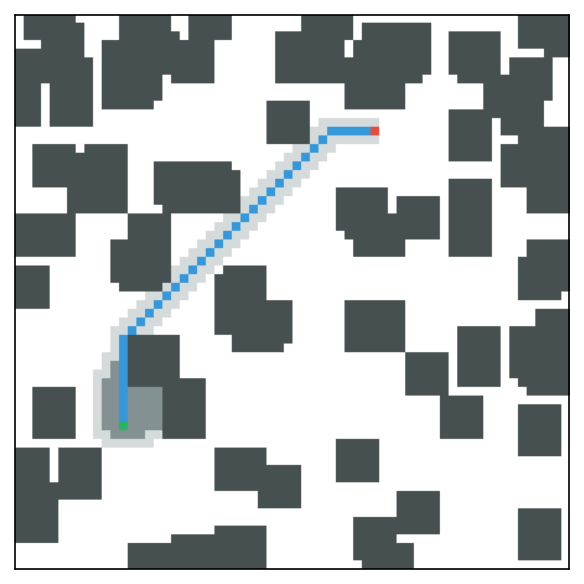

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


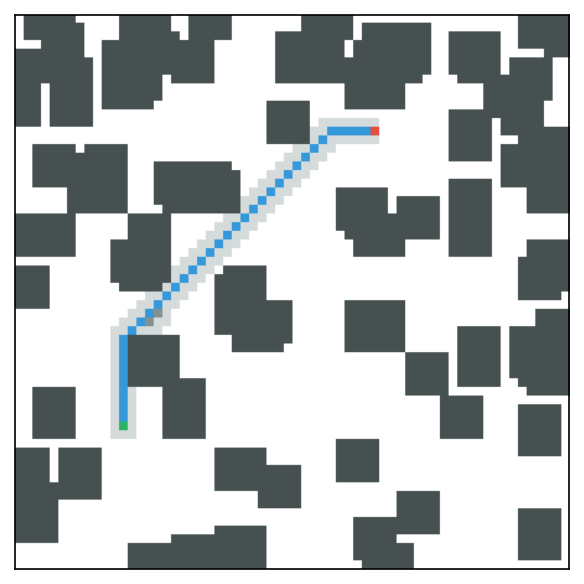

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

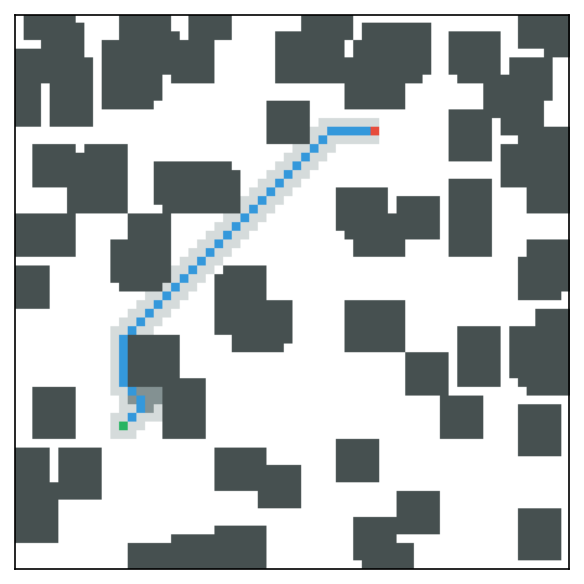

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

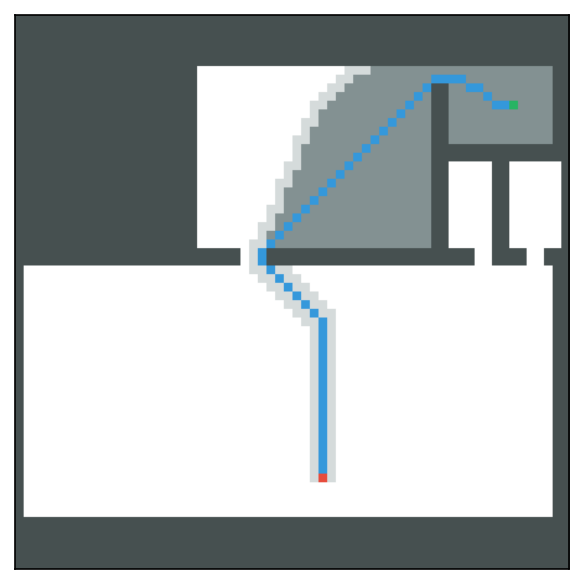

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


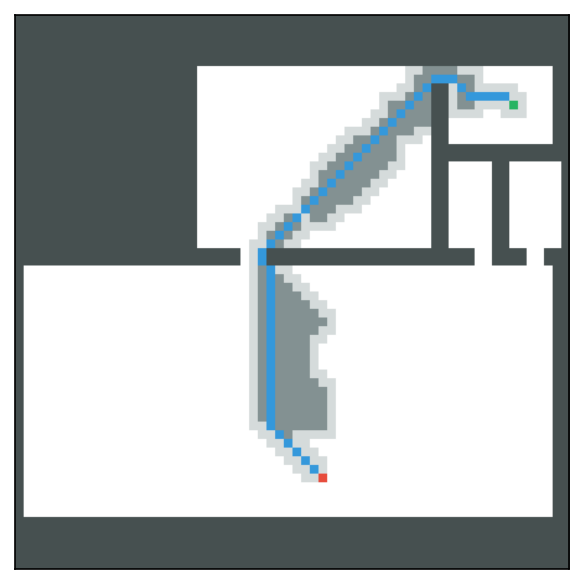

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

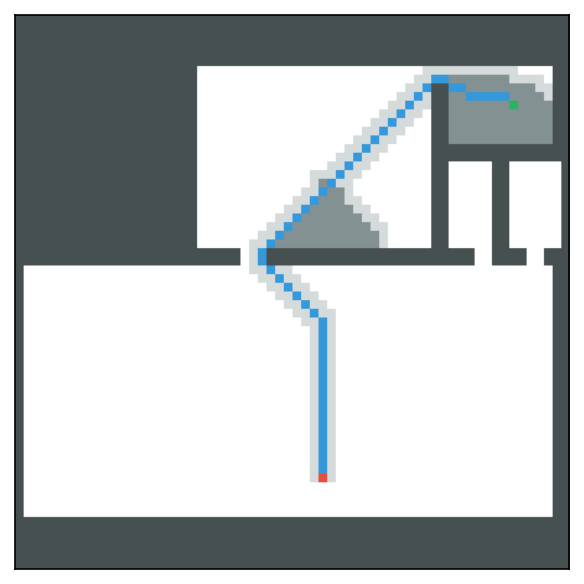

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

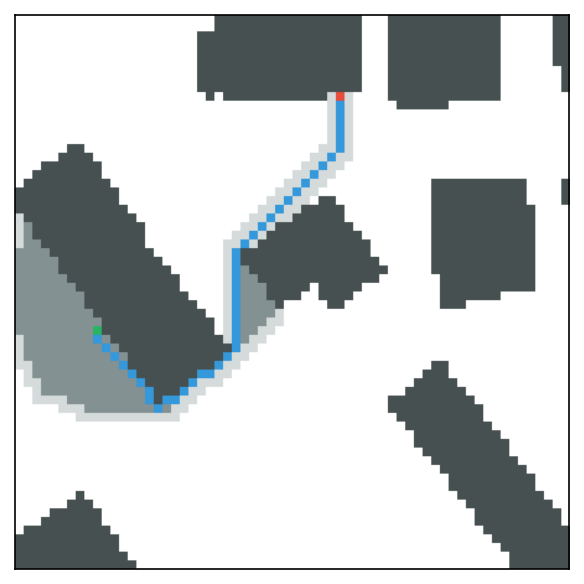

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


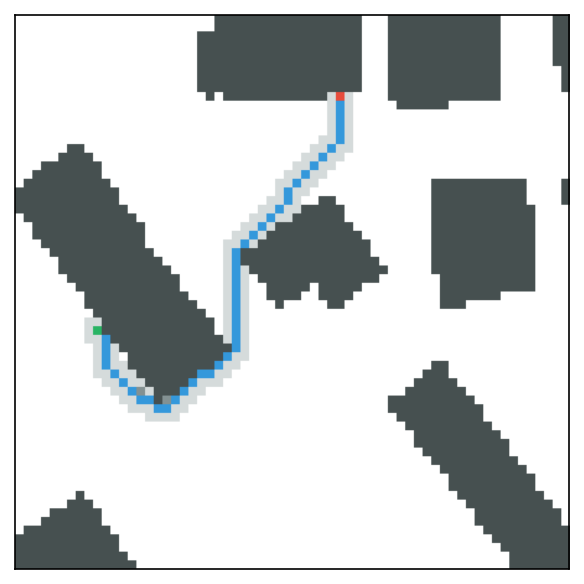

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

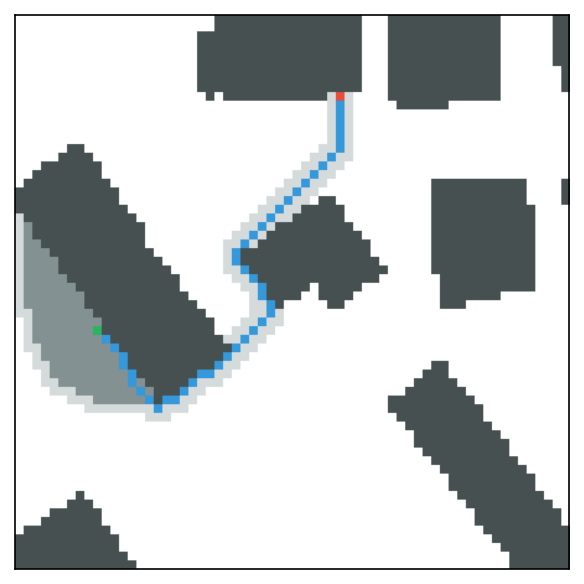

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

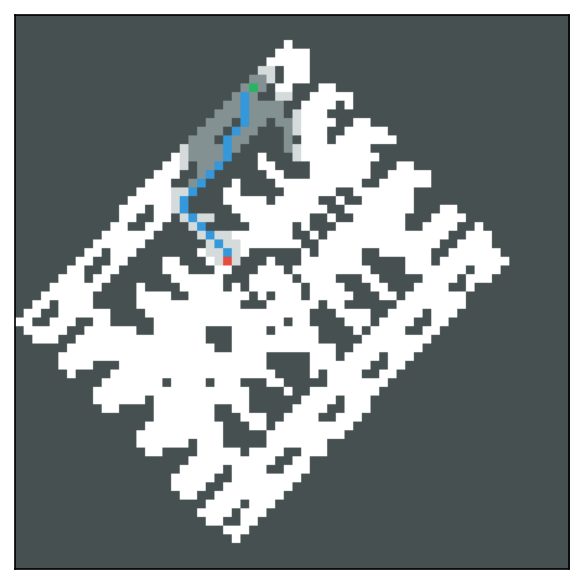

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


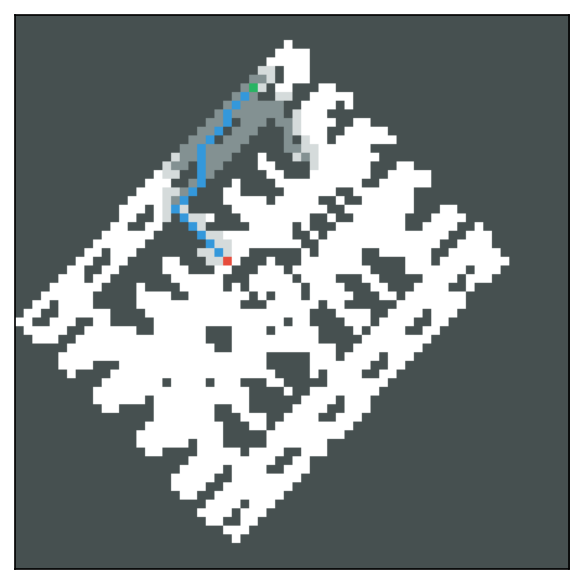

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

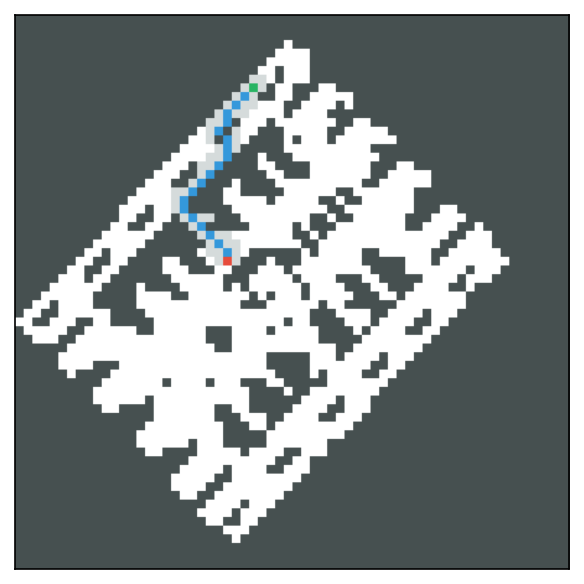

During the search was discovered 0 non-existent paths


A* octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

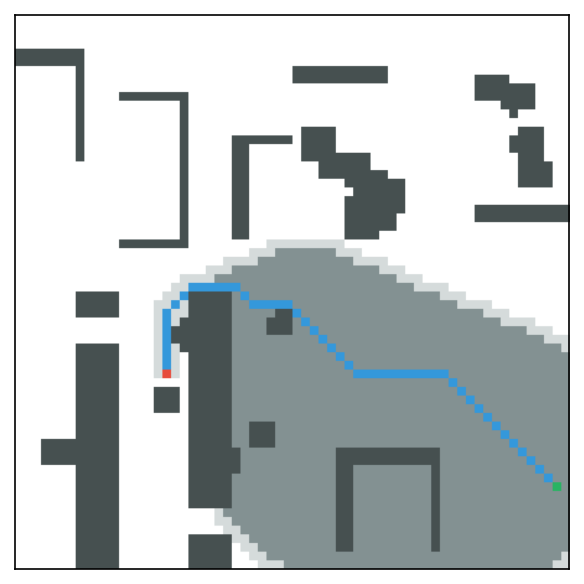

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

Predicting heuristics:   0%|          | 0/2000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


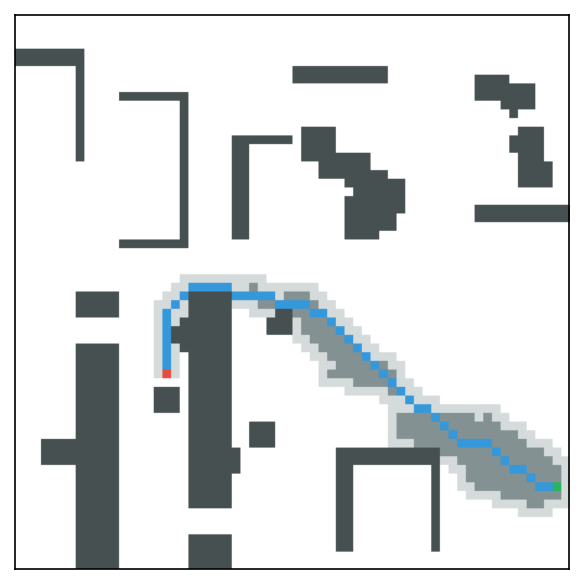

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/1 [00:00<?, ?it/s]

WA* (w=2) octile search:   0%|          | 0/2000 [00:00<?, ?it/s]

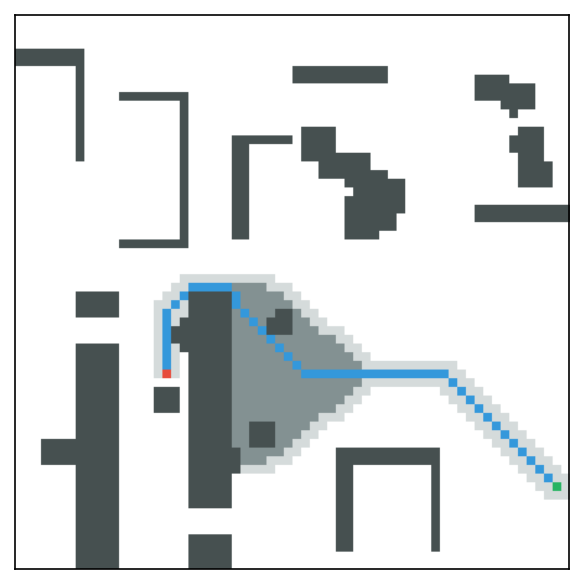

During the search was discovered 0 non-existent paths


In [2]:
model = create_TransPath_model(weights_path='../weights/gold_cf_model', device='cuda:1')

metrics = get_splitted_metrics('../testset/test', model, ws=[2], threshold=1.05, verbose=2)

In [3]:
import pickle

# Save to a pickle file
with open("../results/GOLDENSPLITTED.pkl", "wb") as f:
    pickle.dump(metrics, f, protocol=pickle.HIGHEST_PROTOCOL)

In [2]:
import pickle



# Save to a pickle file
with open("../results/GOLDENSPLITTED.pkl", "rb") as f:
    ress = pickle.load(f)

for res in ress:
    display(res)

,baseline,model,w=2
Optimal found ratio,100.0%,0.0%,59.05%
Length ratio,100.0±0.0%,103.48±0.97%,100.09±0.12%
Expansions ratio,100.0±0.0%,95.74±38.24%,96.5±3.76%


,baseline,model,w=2
Optimal found ratio,100.0%,0.1%,52.95%
Length ratio,100.0±0.0%,201.41±72.62%,100.76±1.94%
Expansions ratio,100.0±0.0%,120.73±90.28%,92.02±10.69%


,baseline,model,w=2
Optimal found ratio,100.0%,13.55%,12.15%
Length ratio,100.0±0.0%,107.5±12.67%,104.51±4.2%
Expansions ratio,100.0±0.0%,70.15±52.58%,60.6±21.66%


,baseline,model,w=2
Optimal found ratio,100.0%,0.15%,4.25%
Length ratio,100.0±0.0%,161.98±46.93%,108.3±6.4%
Expansions ratio,100.0±0.0%,248.01±230.43%,32.26±17.93%


,baseline,model,w=2
Optimal found ratio,100.0%,0.2%,3.3%
Length ratio,100.0±0.0%,176.16±59.79%,107.1±4.76%
Expansions ratio,100.0±0.0%,270.99±208.23%,30.08±14.75%


,baseline,model,w=2
Optimal found ratio,100.0%,73.25%,34.25%
Length ratio,100.0±0.0%,100.78±3.04%,103.41±4.23%
Expansions ratio,100.0±0.0%,47.48±38.19%,37.4±22.46%


,baseline,model,w=2
Optimal found ratio,100.0%,53.4%,51.55%
Length ratio,100.0±0.0%,101.35±3.23%,102.51±3.68%
Expansions ratio,100.0±0.0%,80.64±64.02%,57.91±24.57%


,baseline,model,w=2
Optimal found ratio,100.0%,64.45%,32.25%
Length ratio,100.0±0.0%,100.98±3.09%,103.73±4.45%
Expansions ratio,100.0±0.0%,47.87±40.06%,41.24±24.93%


,baseline,model,w=2
Optimal found ratio,100.0%,28.4%,34.7%
Length ratio,100.0±0.0%,104.69±10.19%,103.13±3.96%
Expansions ratio,100.0±0.0%,96.61±48.72%,53.19±24.47%


,baseline,model,w=2
Optimal found ratio,100.0%,89.85%,39.05%
Length ratio,100.0±0.0%,100.16±1.1%,103.86±5.18%
Expansions ratio,100.0±0.0%,35.97±28.21%,44.5±26.18%


A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


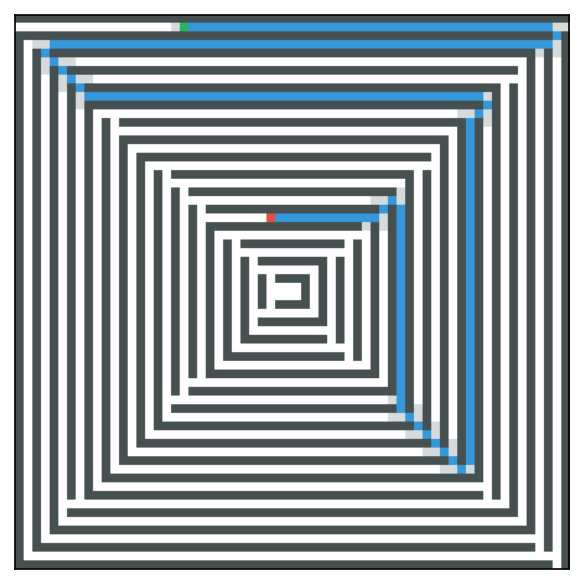

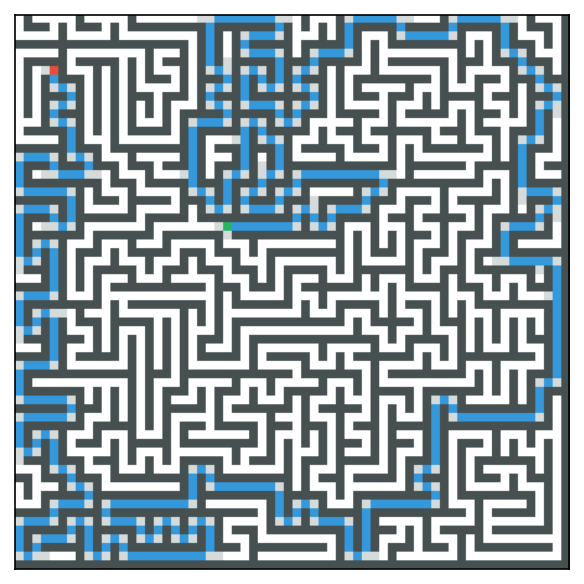

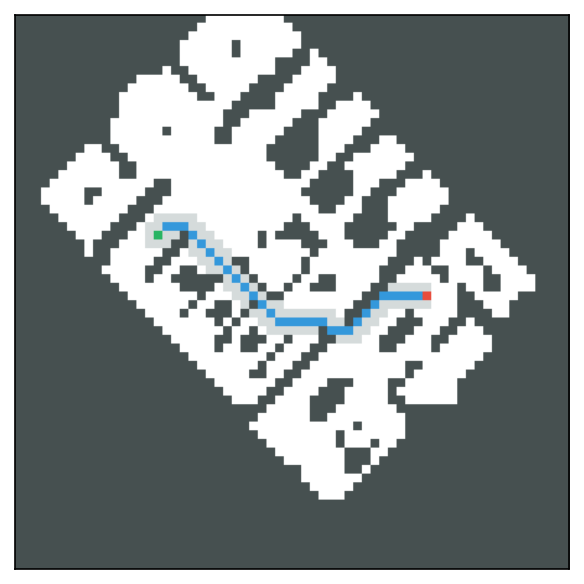

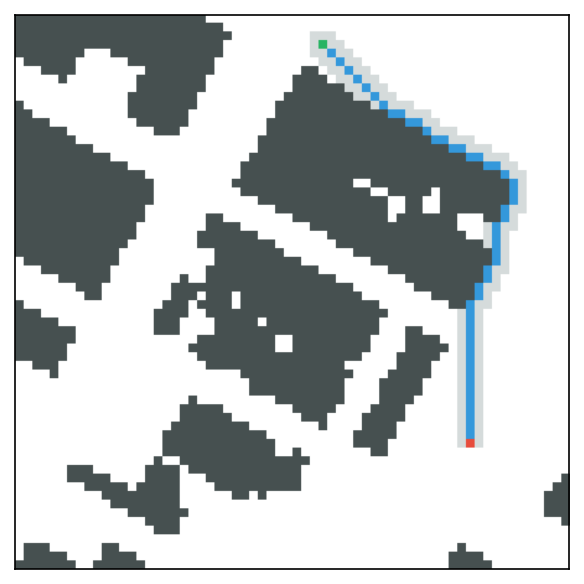

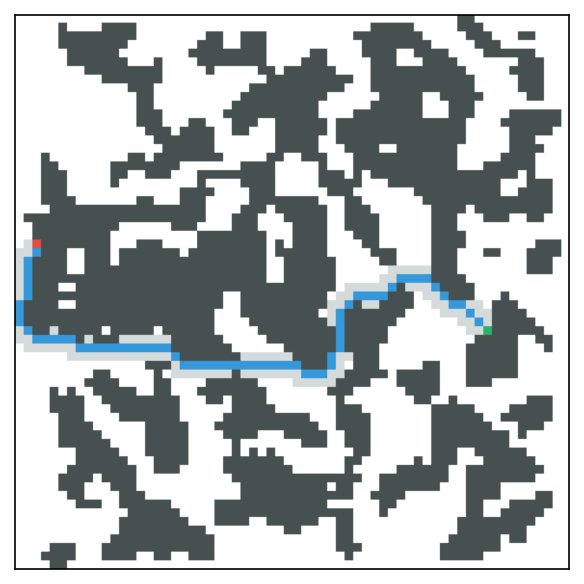

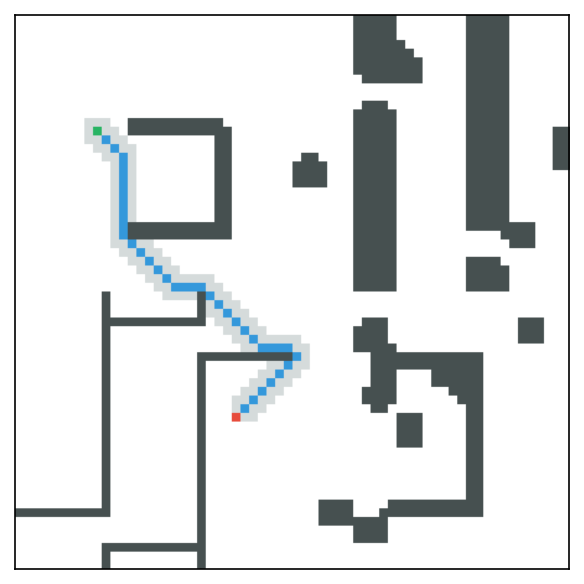

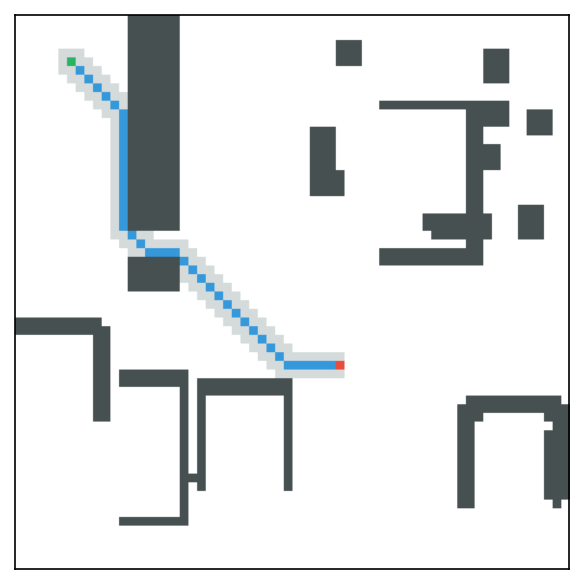

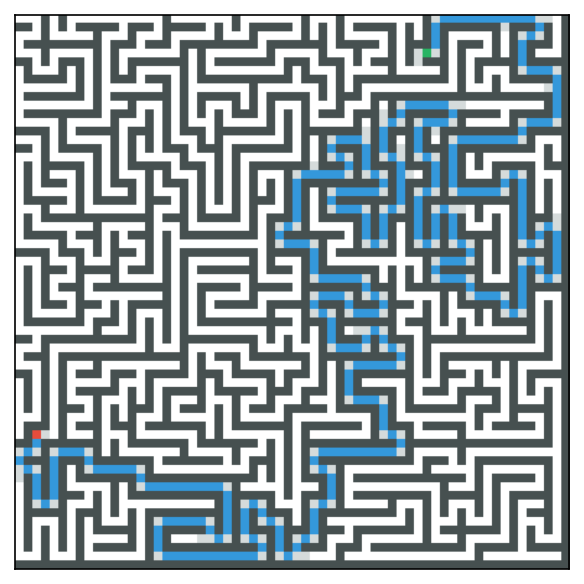

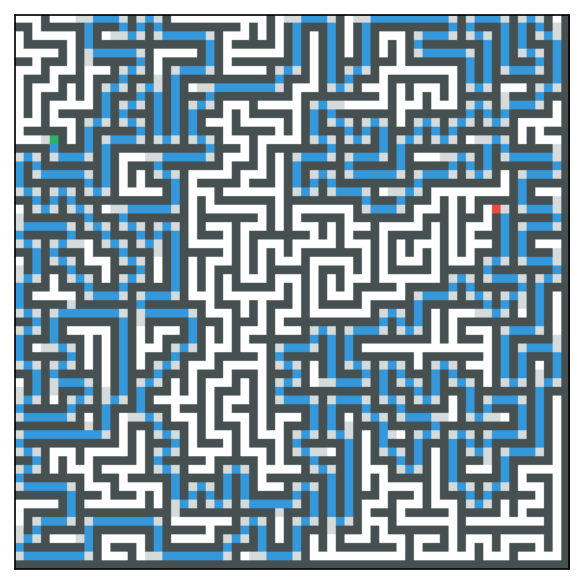

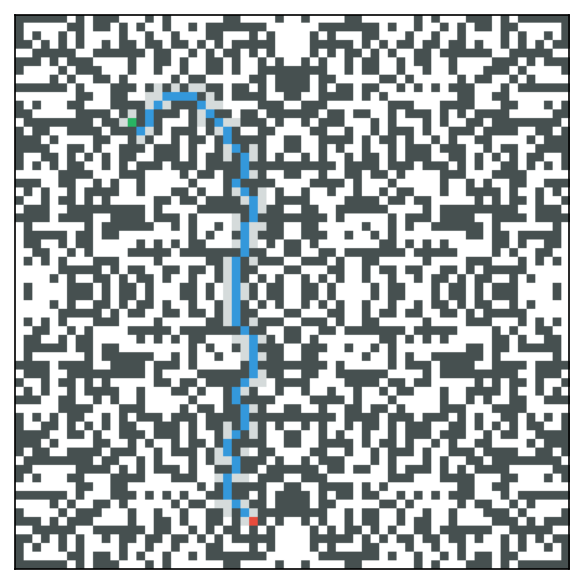

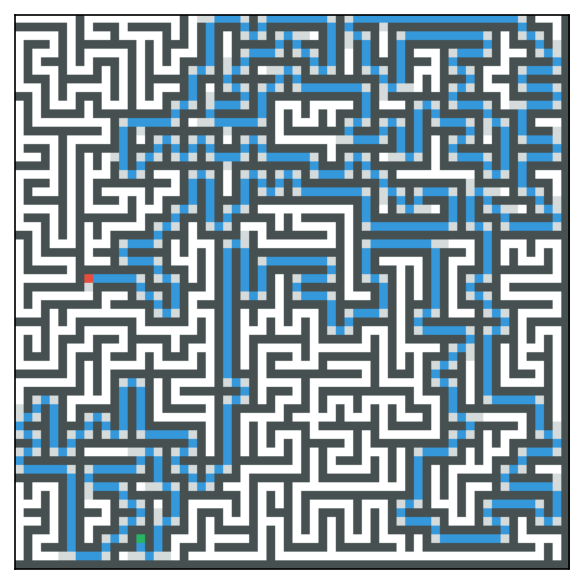

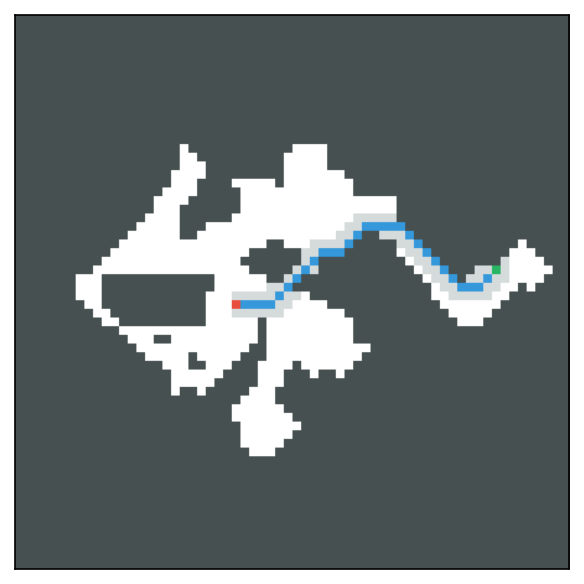

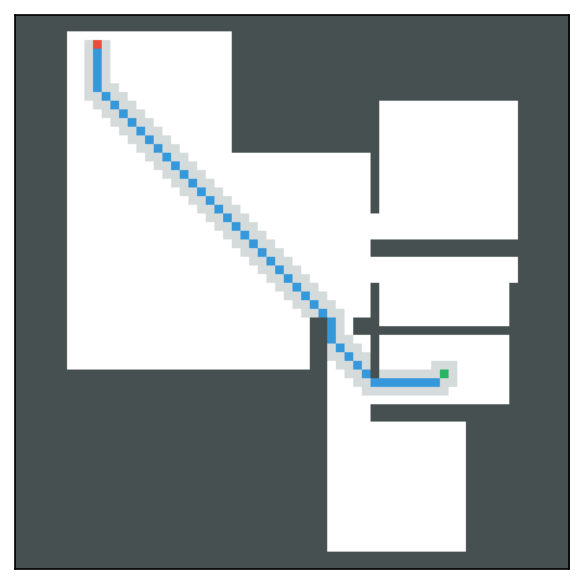

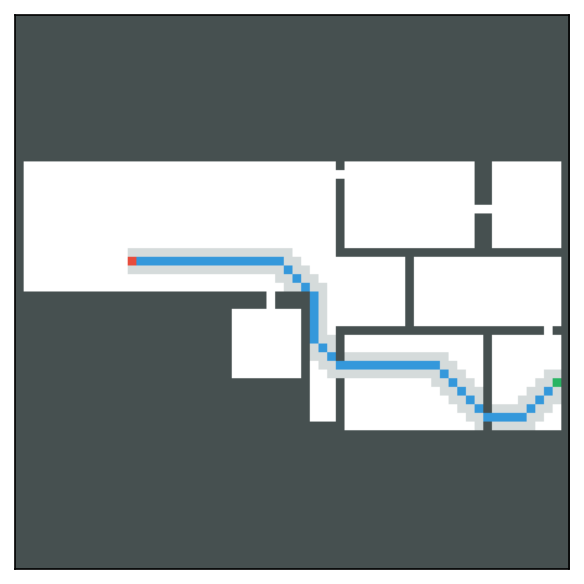

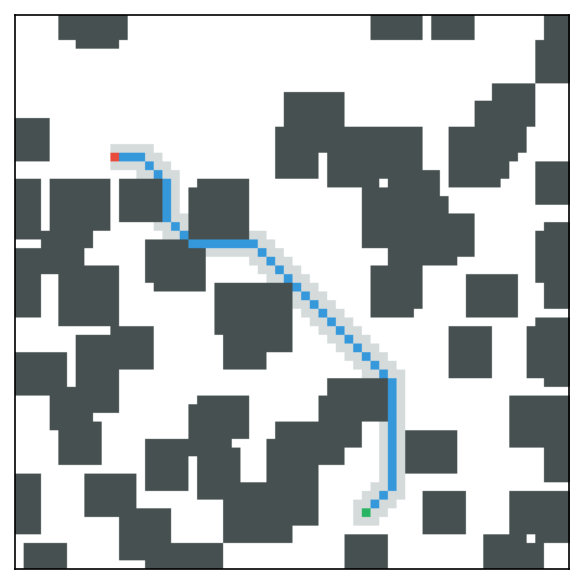

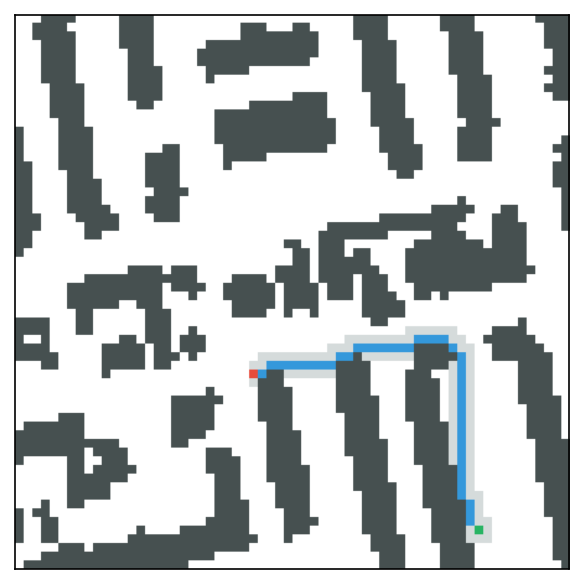

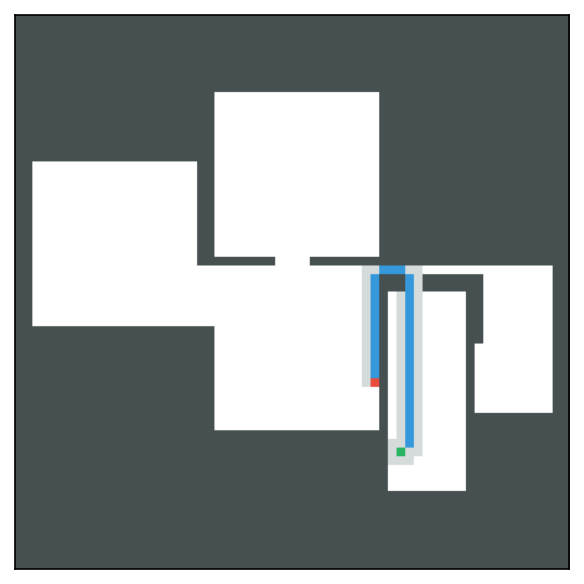

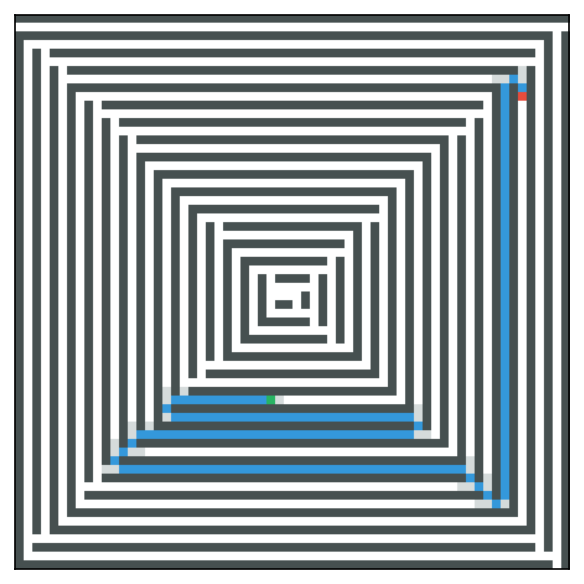

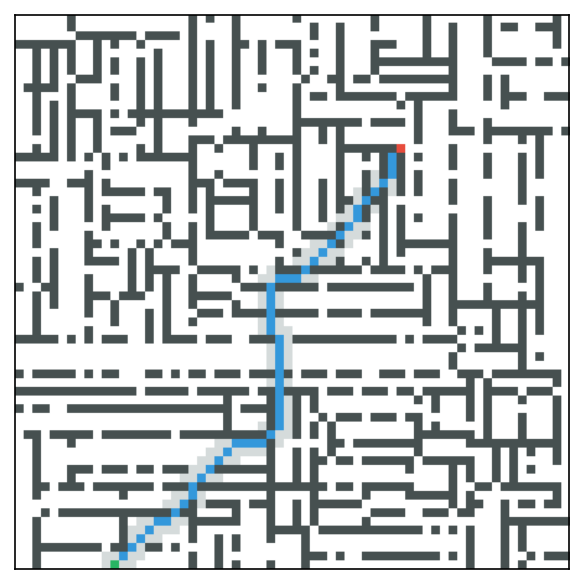

KeyboardInterrupt: 

In [3]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test', cfs_filename='cf.npy')

idxes = np.arange(len(cells))
np.random.shuffle(idxes)

cells = cells[idxes]
starts = starts[idxes]
goals = goals[idxes]
cfs = cfs[idxes]

cfastar_octile_search(cells, starts, goals, cfs=cfs, node_type='optimal', verbose=20)

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

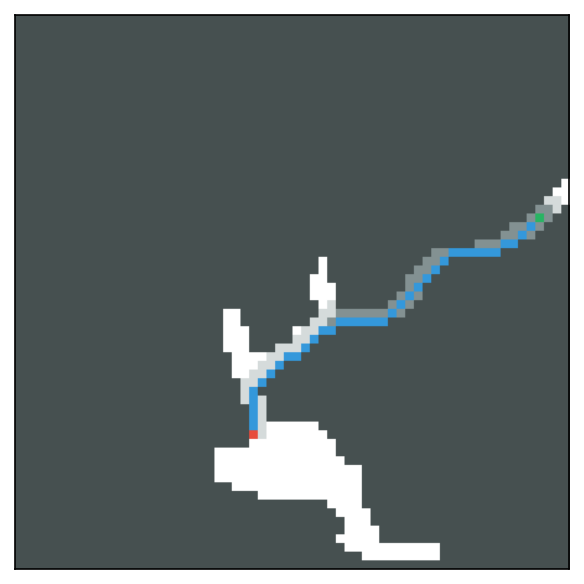

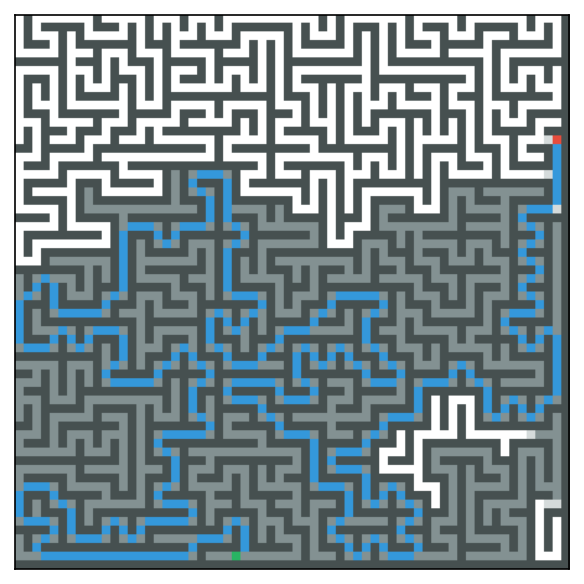

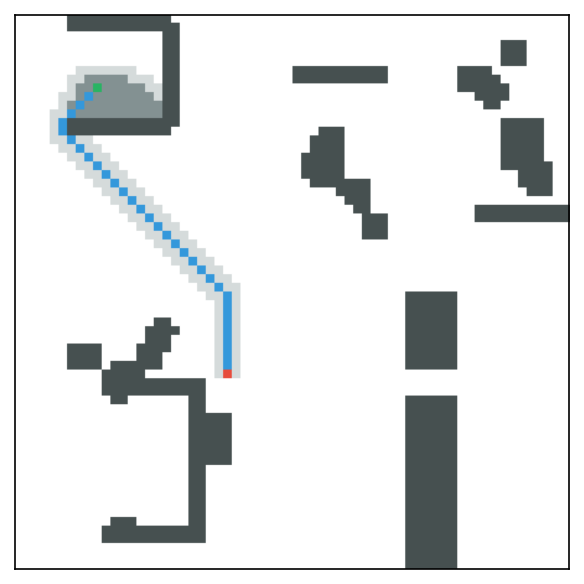

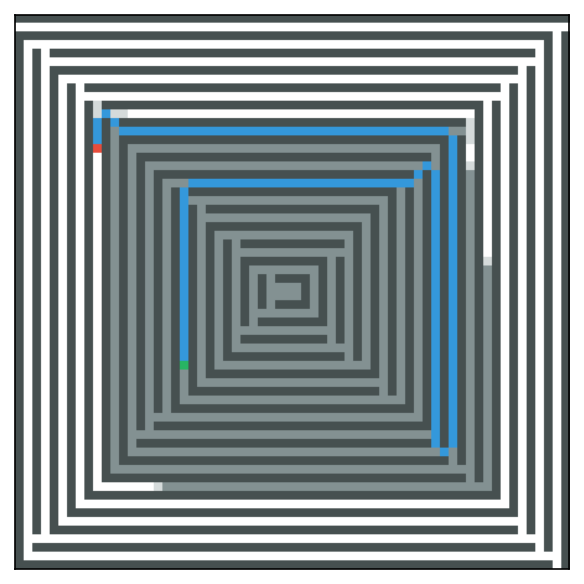

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


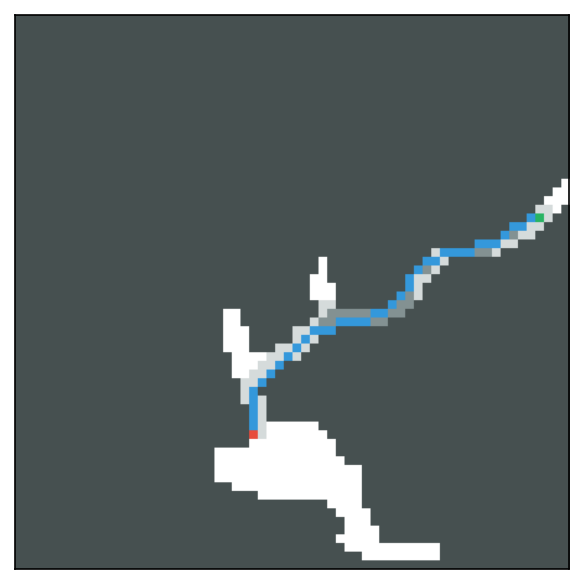

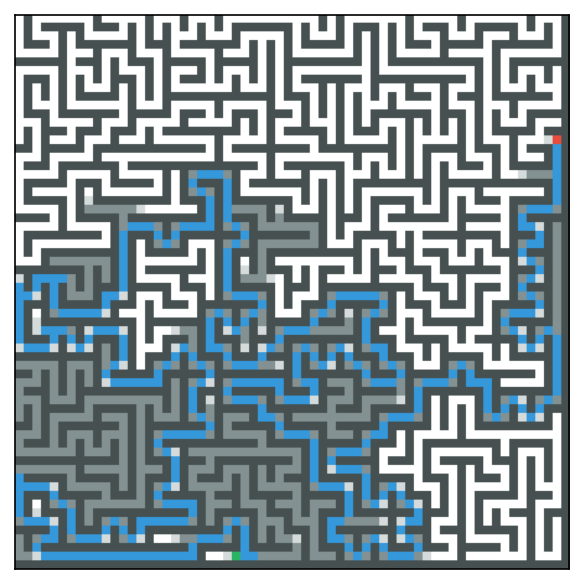

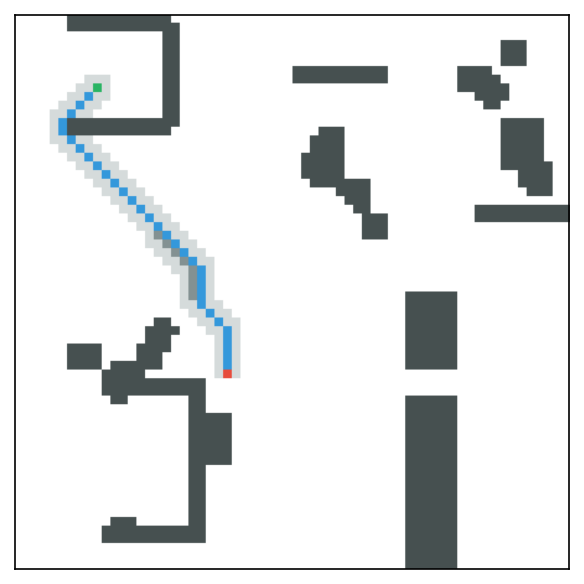

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


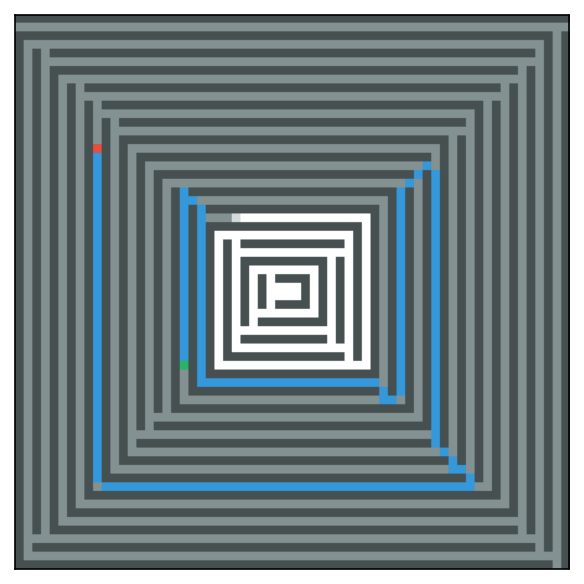

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/9 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

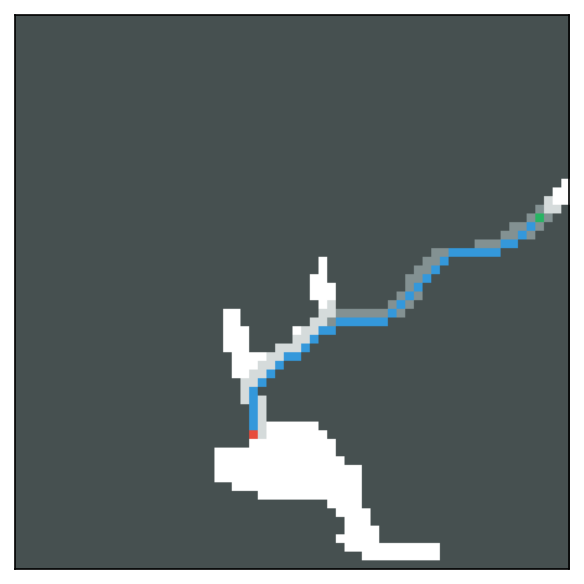

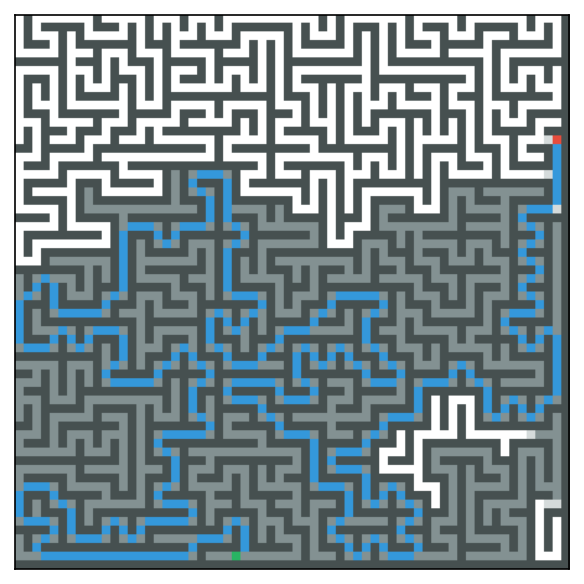

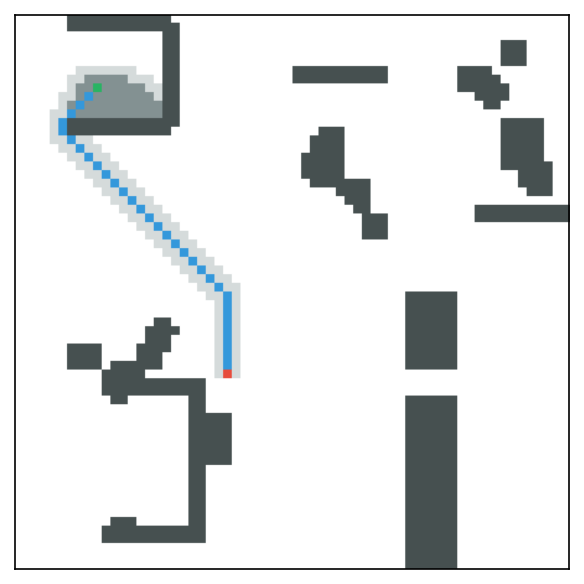

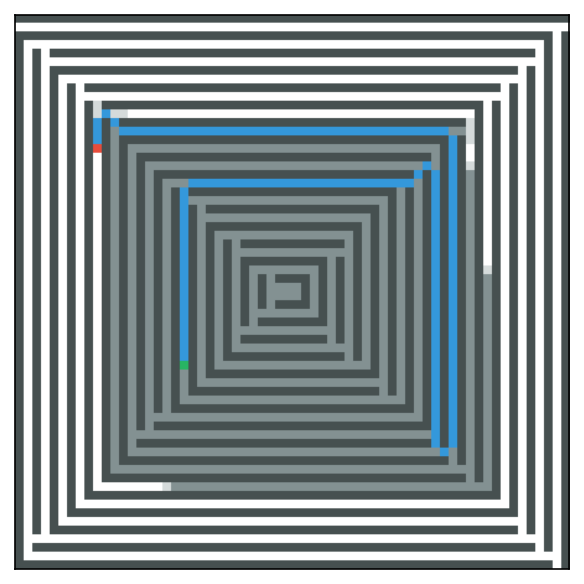

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

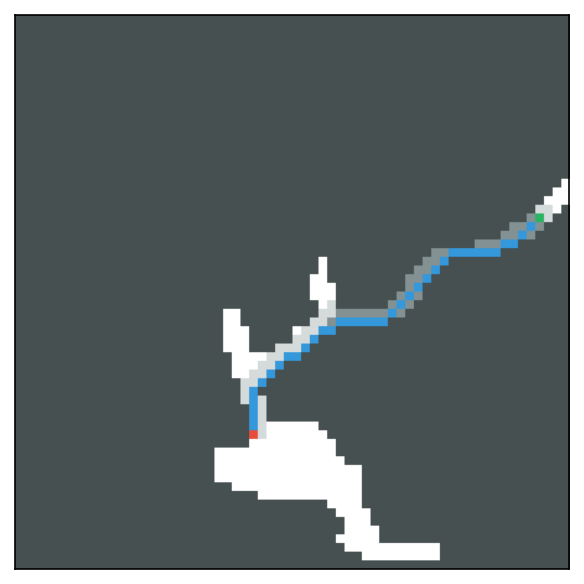

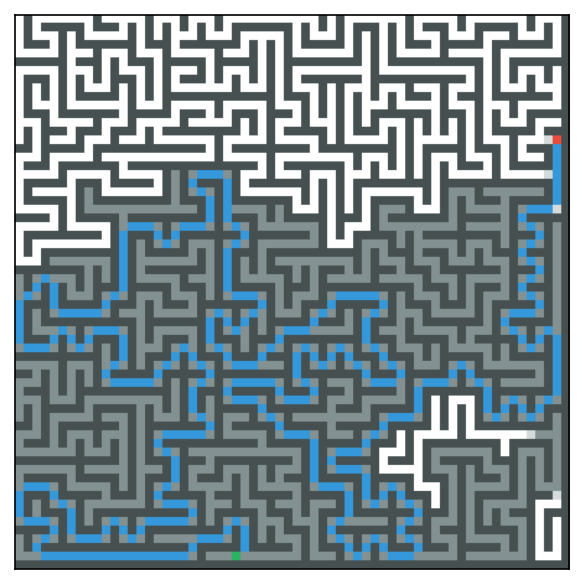

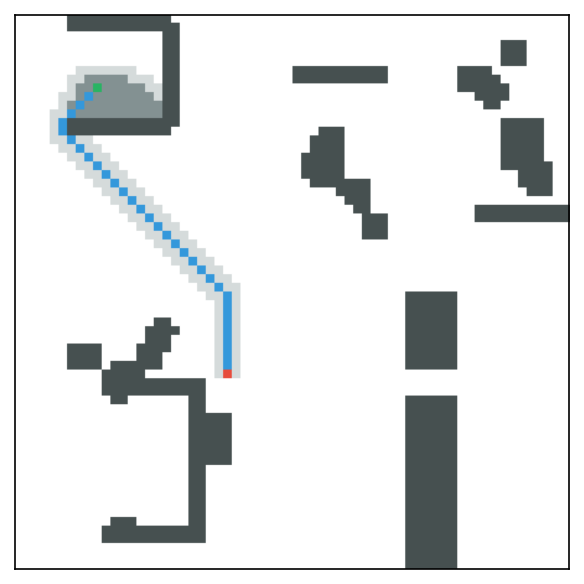

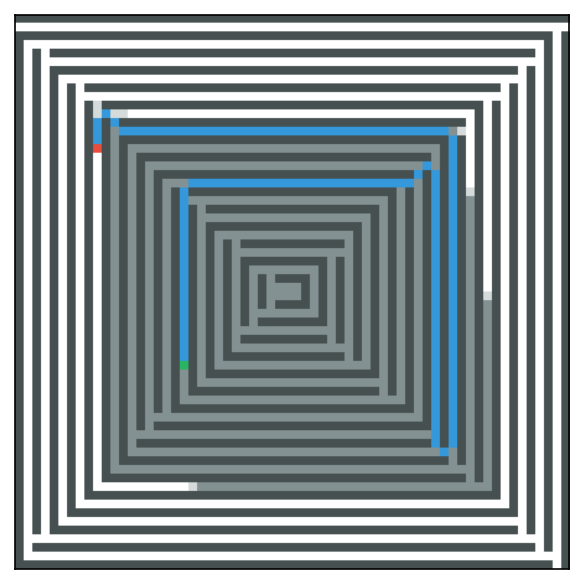

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

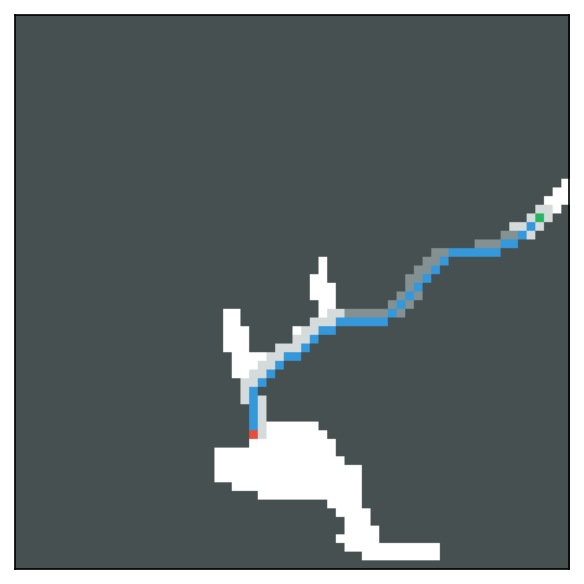

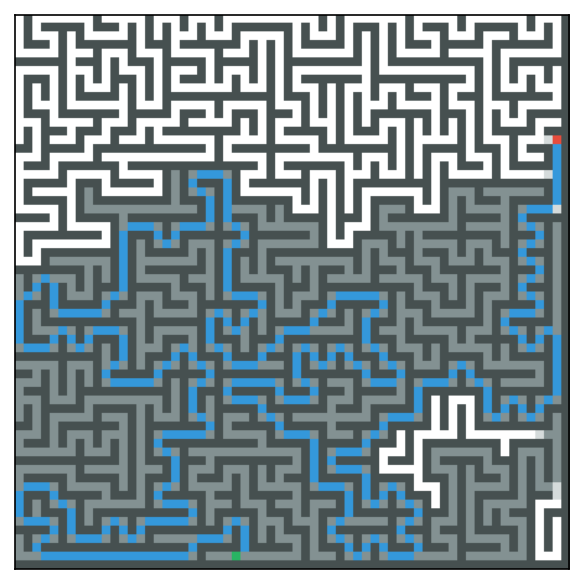

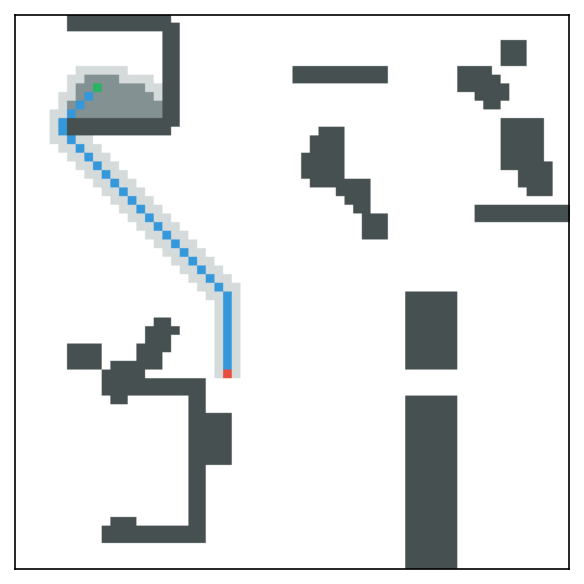

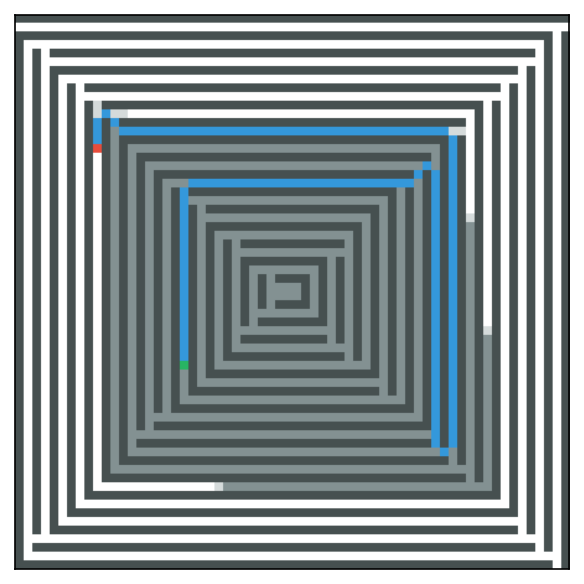

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

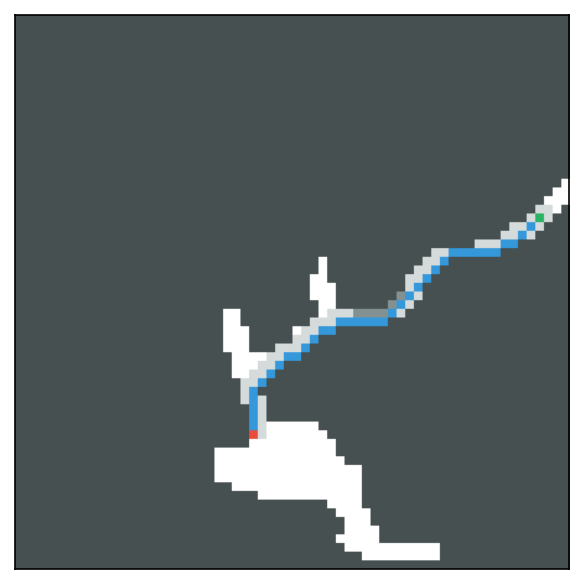

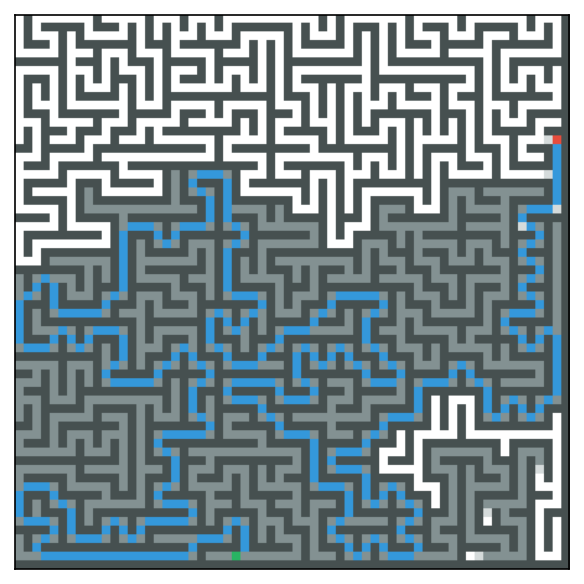

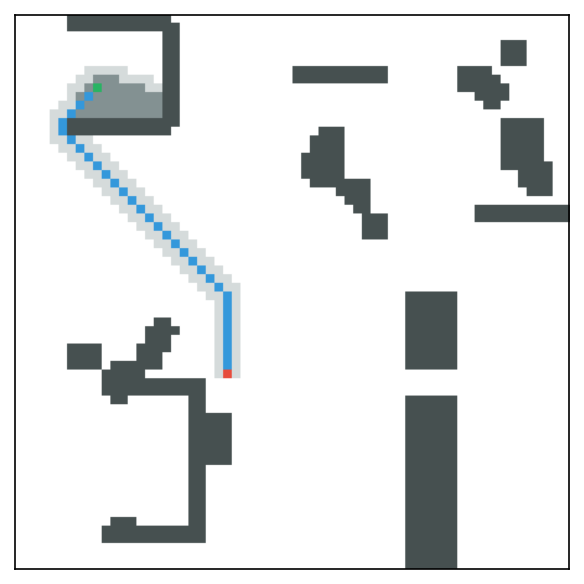

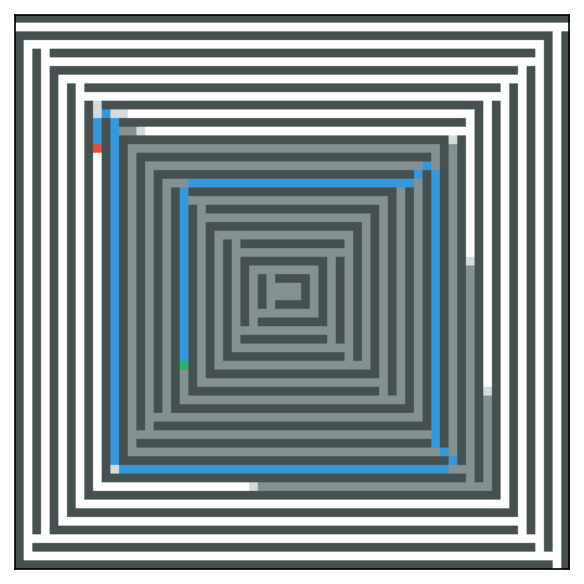

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

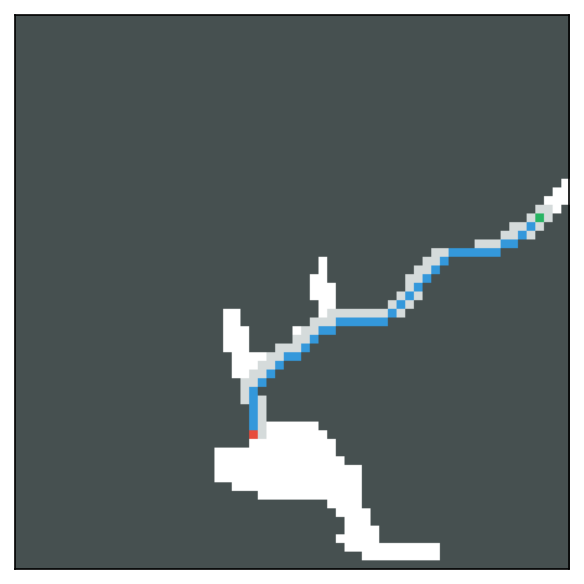

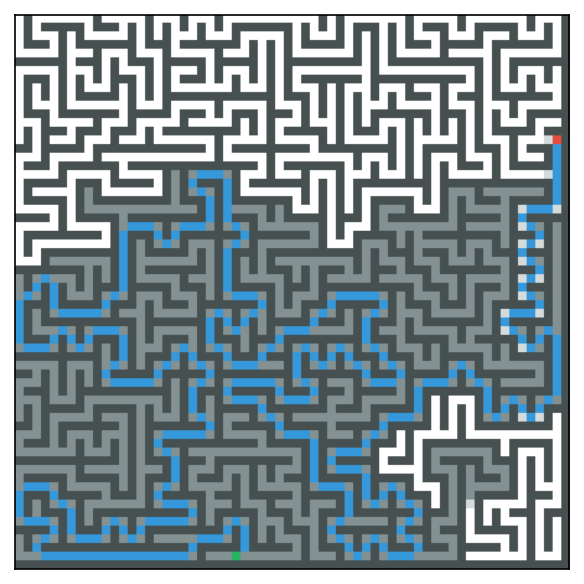

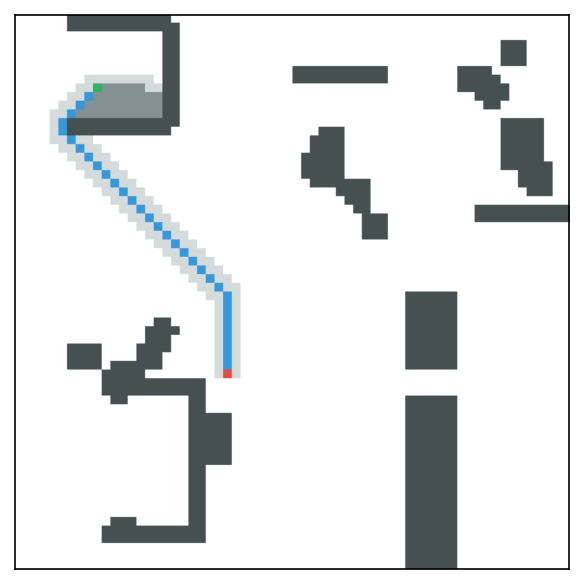

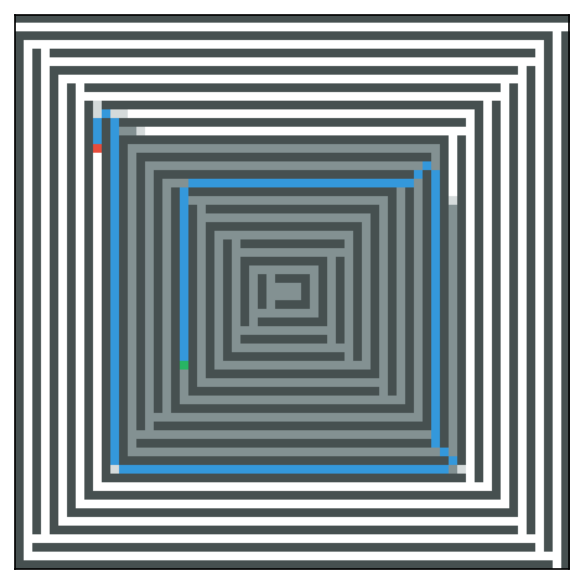

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

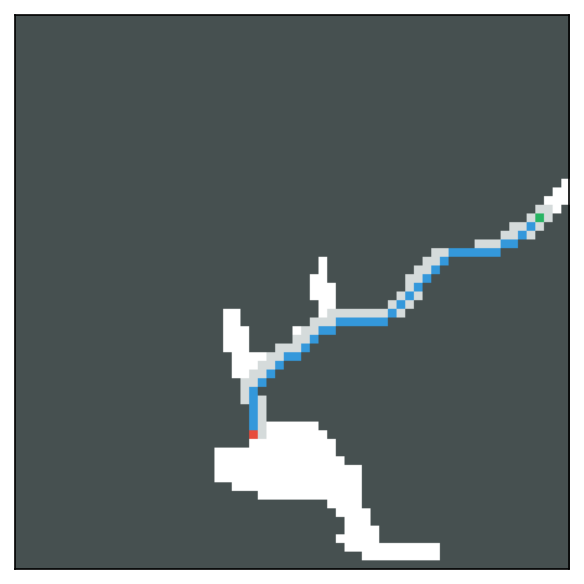

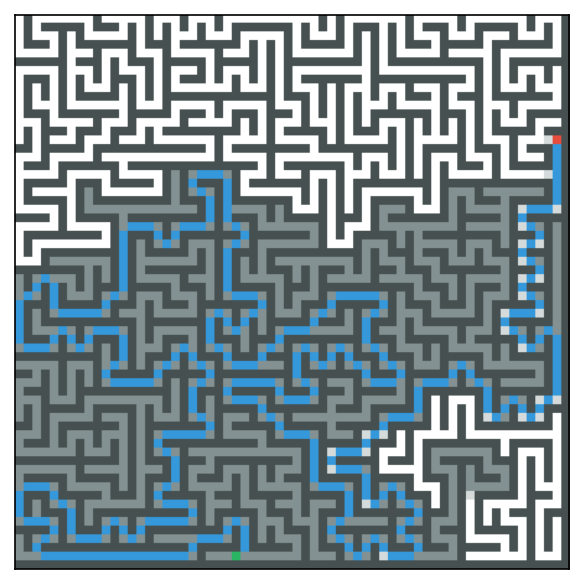

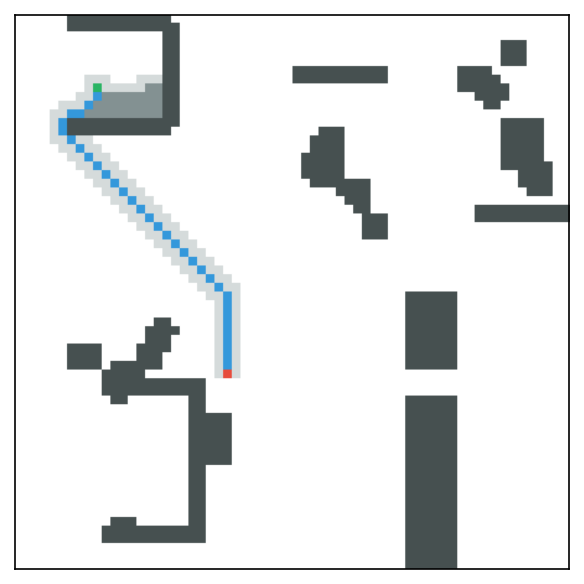

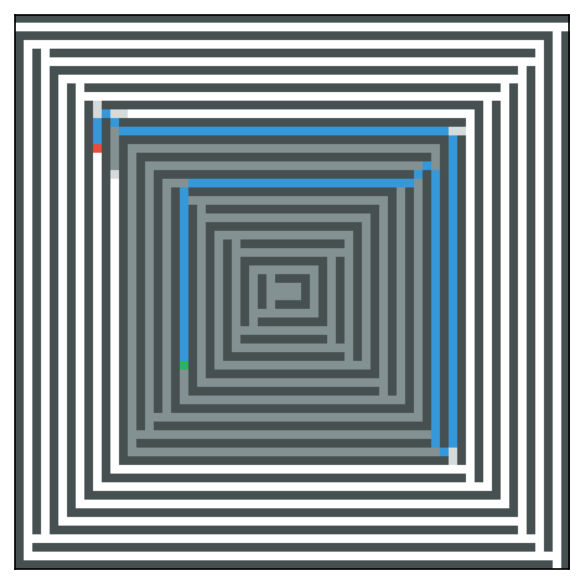

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

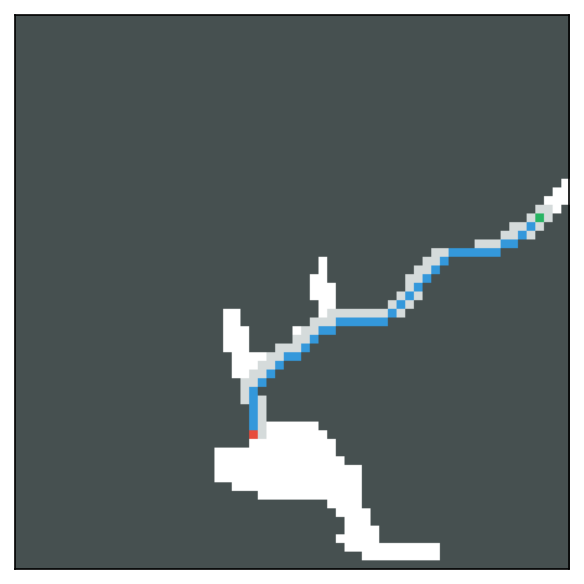

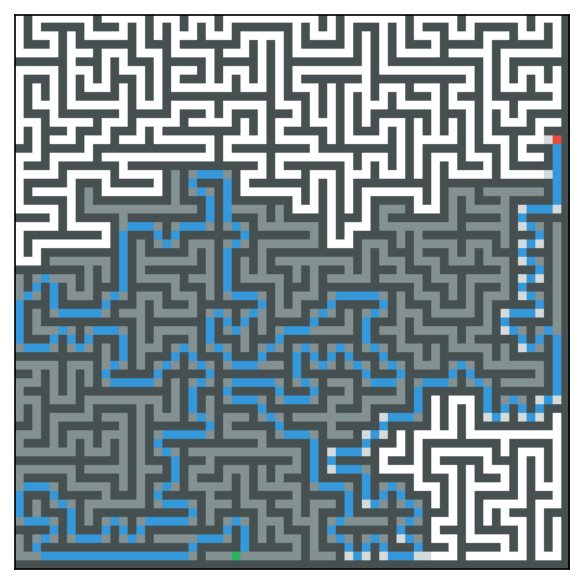

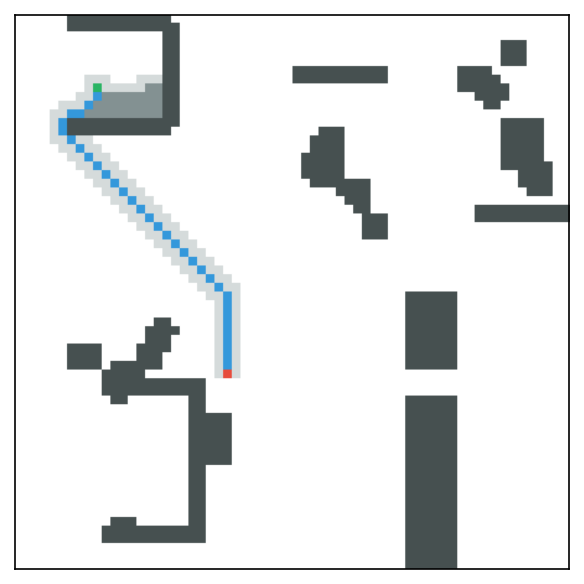

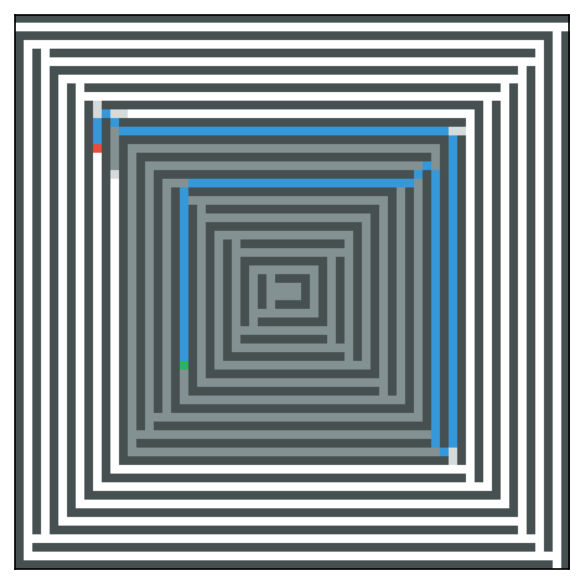

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

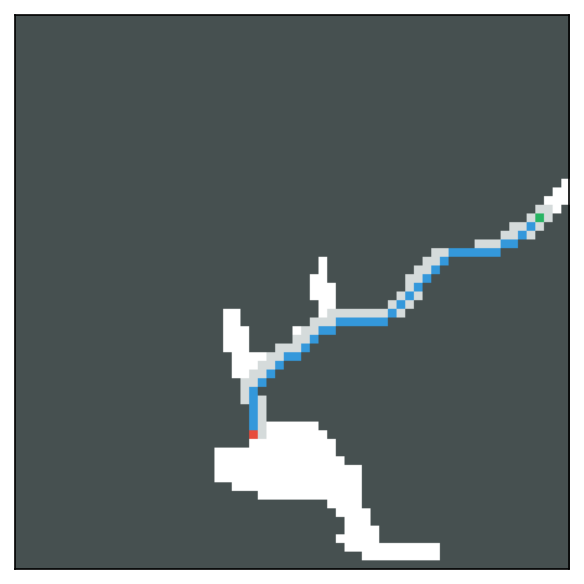

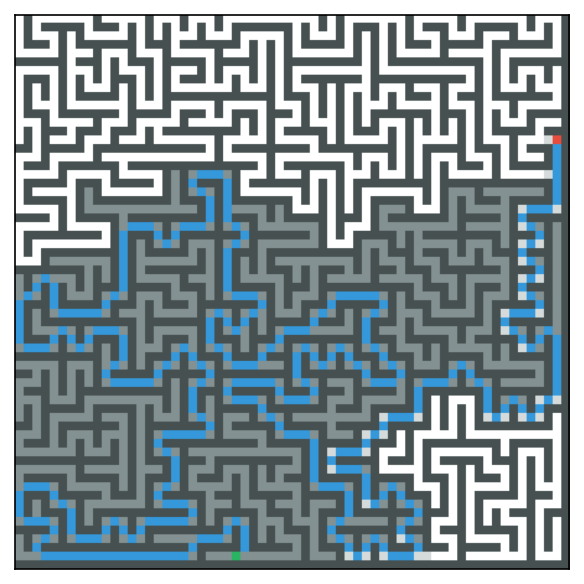

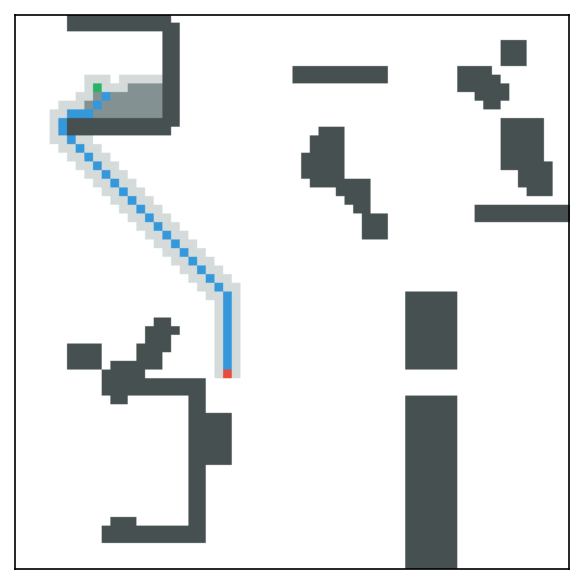

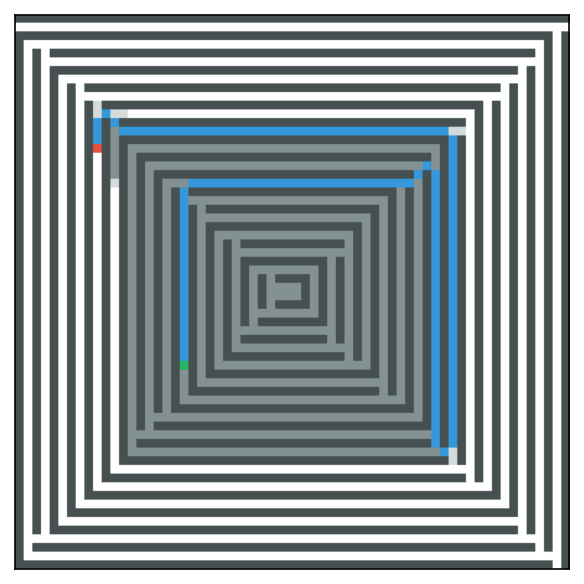

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

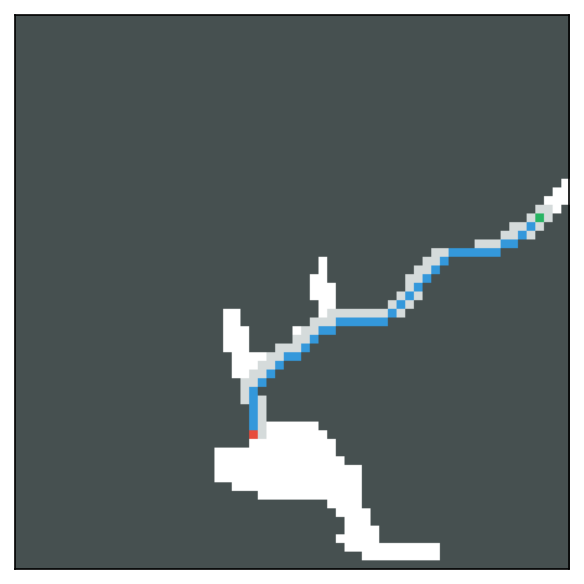

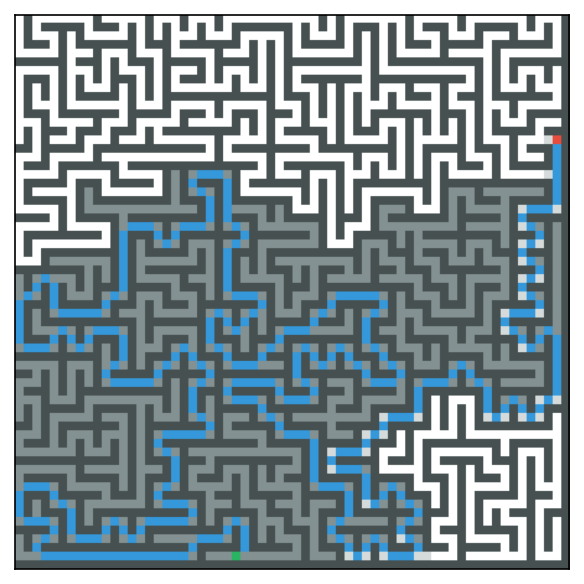

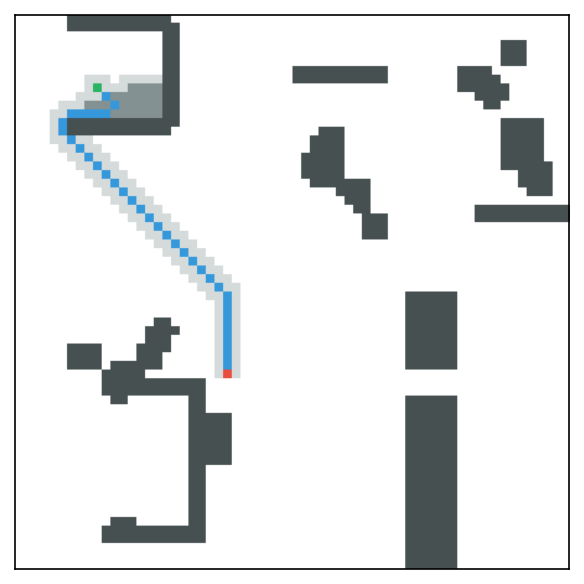

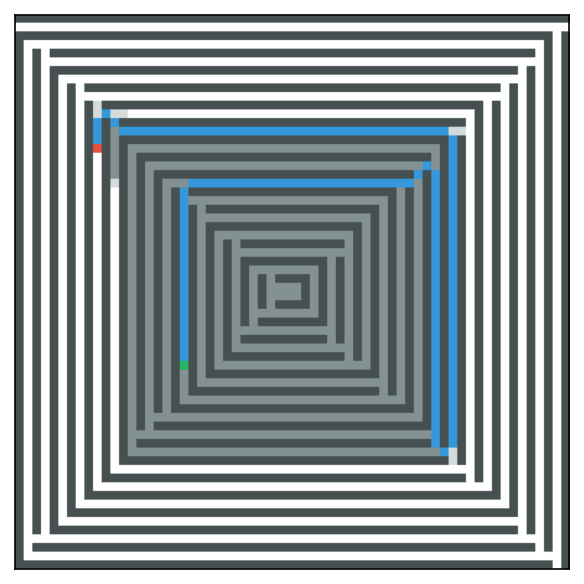

During the search was discovered 0 non-existent paths
CPU times: user 34min 57s, sys: 14.8 s, total: 35min 12s
Wall time: 34min 42s


In [6]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

idxes = np.arange(len(cells))
np.random.shuffle(idxes)

cells = cells[idxes]
starts = starts[idxes]
goals = goals[idxes]

model = create_TransPath_model(weights_path='../weights/gold_cf_model', device='cuda:0')

res = contain_ratios(cells, starts, goals, ws=[1.01, 1.05, 1.1, 1.25, 2, 3, 4, 5, 10], model=model, node_type='optimal', threshold=1.05, verbose=5)

In [8]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMAL1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [9]:
import pickle



# Save to a pickle file
with open("../results/OPTIMAL1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model,w=1.01,w=1.05,w=1.1,w=1.25,w=2,w=3,w=4,w=5,w=10
Optimal found ratio,100.0%,32.34%,99.86%,96.12%,86.22%,63.04%,32.35%,24.13%,19.44%,14.38%,13.4%
Length ratio,100.0±0.0%,125.85±49.68%,100.0±0.01%,100.04±0.22%,100.2±0.58%,100.89±1.57%,103.74±4.85%,105.21±6.54%,106.77±7.92%,107.9±8.92%,109.72±11.08%
Expansions ratio,100.0±0.0%,111.42±134.28%,99.07±1.65%,93.07±8.93%,86.2±15.52%,72.63±24.6%,54.57±30.05%,49.79±30.08%,48.26±29.97%,47.25±29.79%,45.11±29.19%


A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

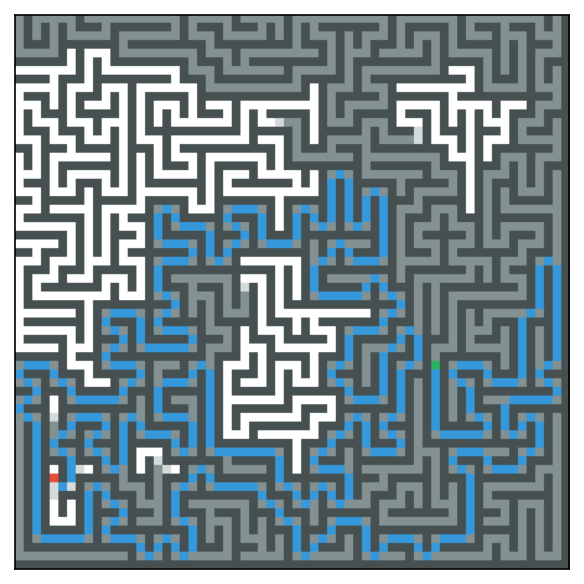

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


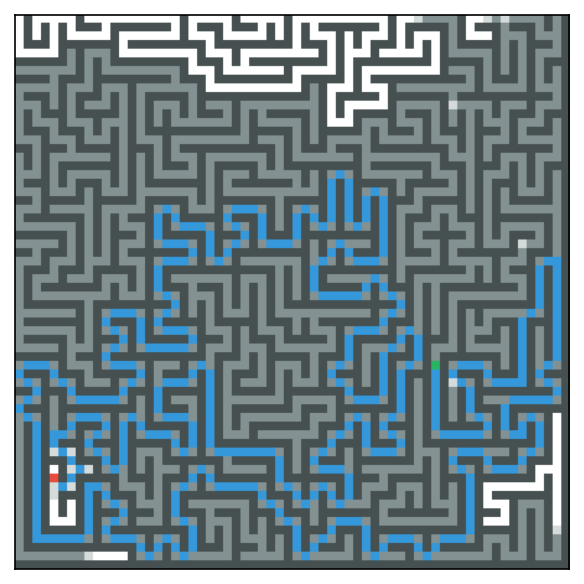

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/9 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

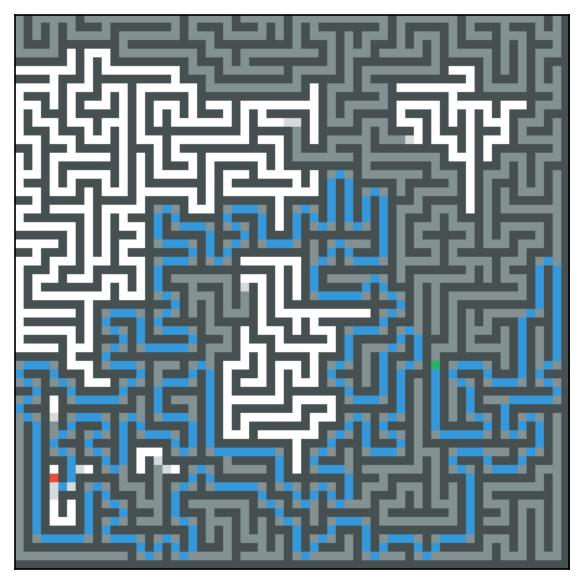

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

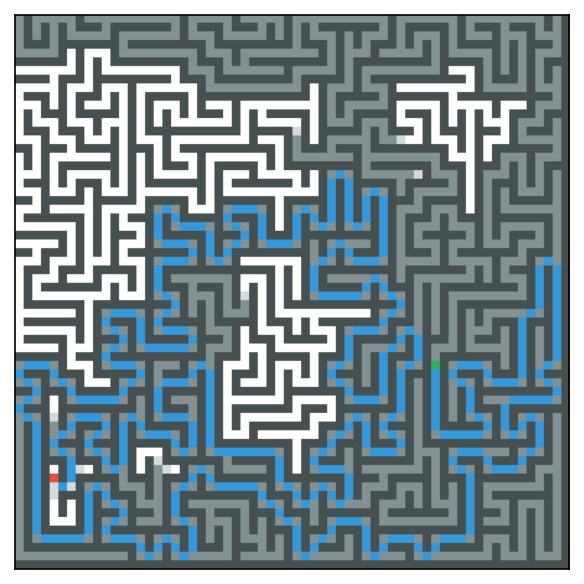

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

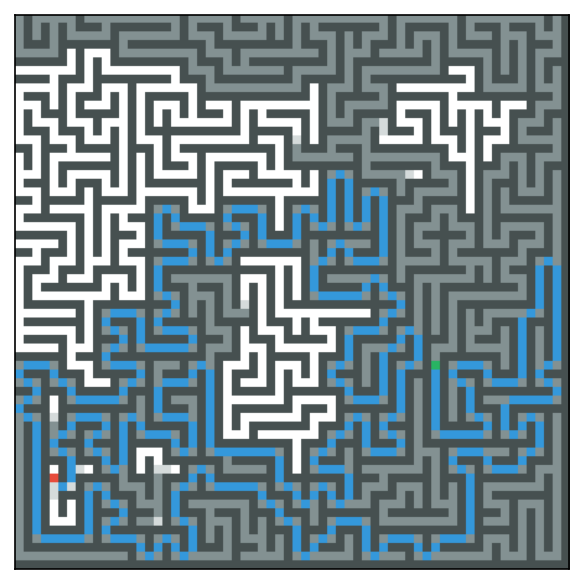

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

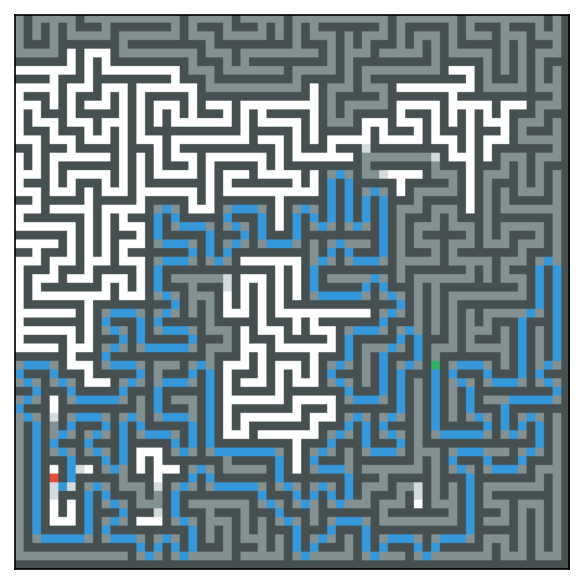

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

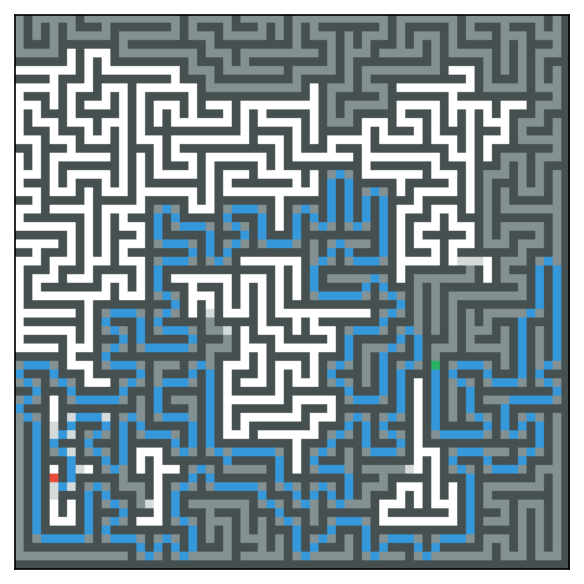

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

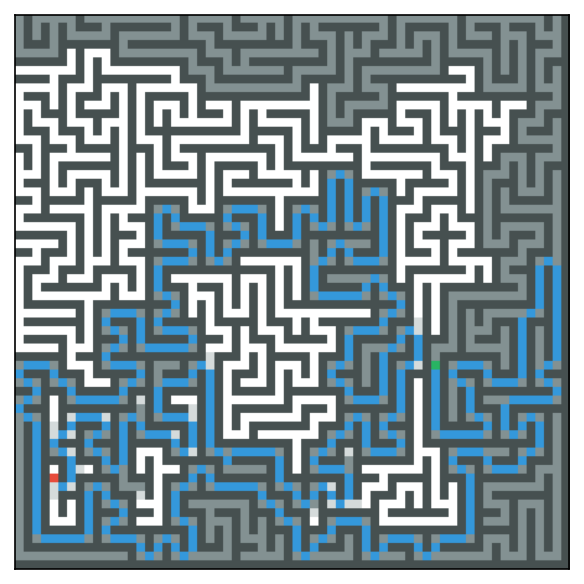

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

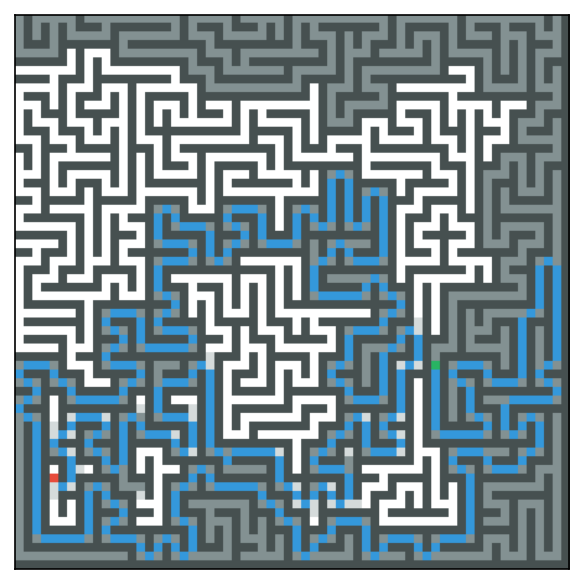

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

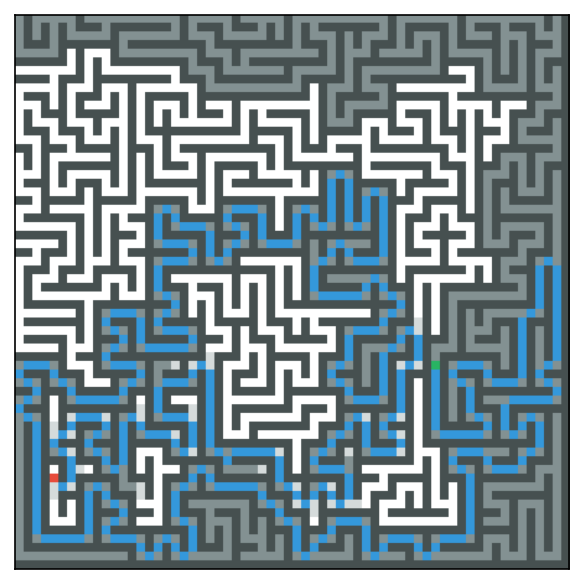

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

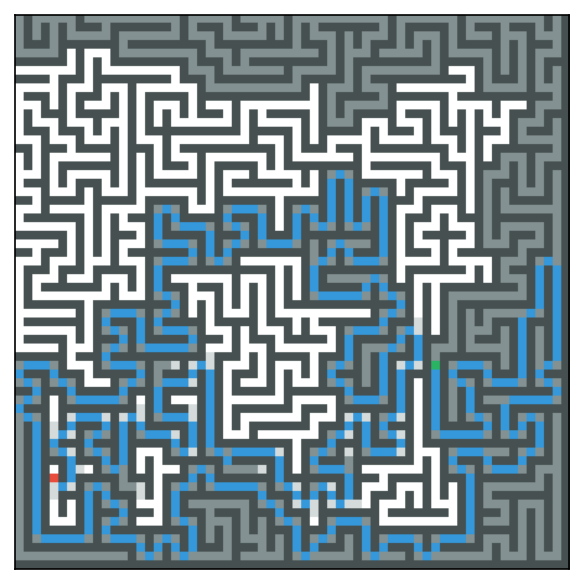

During the search was discovered 0 non-existent paths
CPU times: user 36min 41s, sys: 18.3 s, total: 37min
Wall time: 36min 27s


In [2]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/QRs_big_model_2', device='cuda:1')

res = contain_ratios(cells, starts, goals, ws=[1.01, 1.05, 1.1, 1.25, 2, 3, 4, 5, 10], model=model, node_type='optimal', threshold=1.05, verbose=2)

In [3]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALQR1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [4]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALQR1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model,w=1.01,w=1.05,w=1.1,w=1.25,w=2,w=3,w=4,w=5,w=10
Optimal found ratio,100.0%,15.12%,99.86%,96.12%,86.22%,63.04%,32.35%,24.13%,19.44%,14.38%,13.4%
Length ratio,100.0±0.0%,107.57±13.96%,100.0±0.01%,100.04±0.22%,100.2±0.58%,100.89±1.57%,103.74±4.85%,105.21±6.54%,106.77±7.92%,107.9±8.92%,109.72±11.08%
Expansions ratio,100.0±0.0%,72.53±44.7%,99.07±1.65%,93.07±8.93%,86.2±15.52%,72.63±24.6%,54.57±30.05%,49.79±30.08%,48.26±29.97%,47.25±29.79%,45.11±29.19%


In [33]:
checkpoint = torch.load('./checkpoints/cf-epoch=499-20250126-210000_testsettrained.ckpt')

/tmp/ipykernel_3588859/4144289429.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load('./checkpoints/cf-epoch=499-20250126-210000_testsettrained.ckpt

In [35]:
from collections import OrderedDict
weights = OrderedDict({k[6:] : w for k, w in checkpoint['state_dict'].items()})

In [36]:
model = TransPathModel()

In [38]:
model.load_state_dict(weights)

<All keys matched successfully>

In [39]:
torch.save(model.state_dict(), '../weights/vesa_russkie')

A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

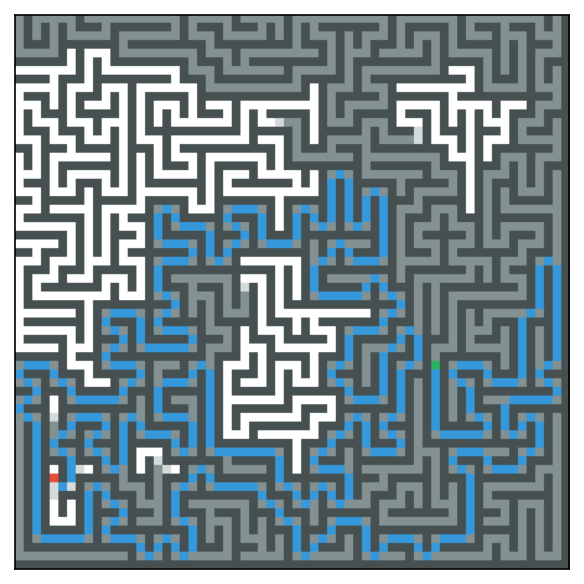

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


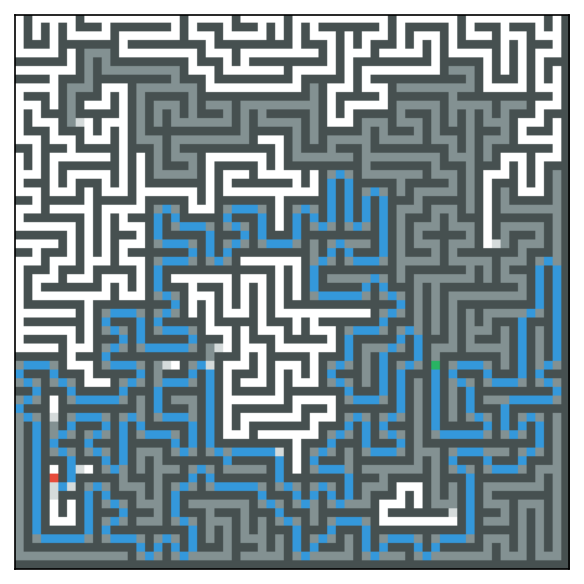

During the search was discovered 0 non-existent paths


Computing WA* statistics:   0%|          | 0/9 [00:00<?, ?it/s]

WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

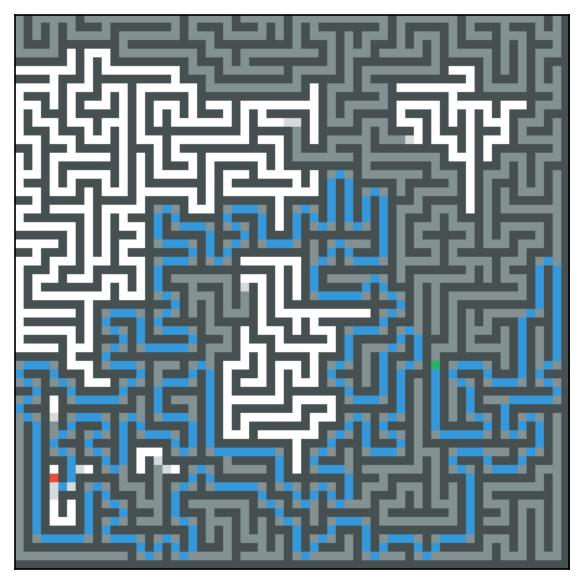

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

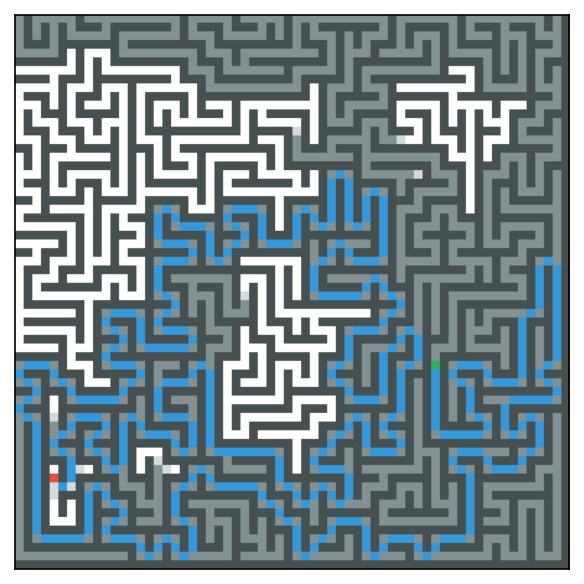

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

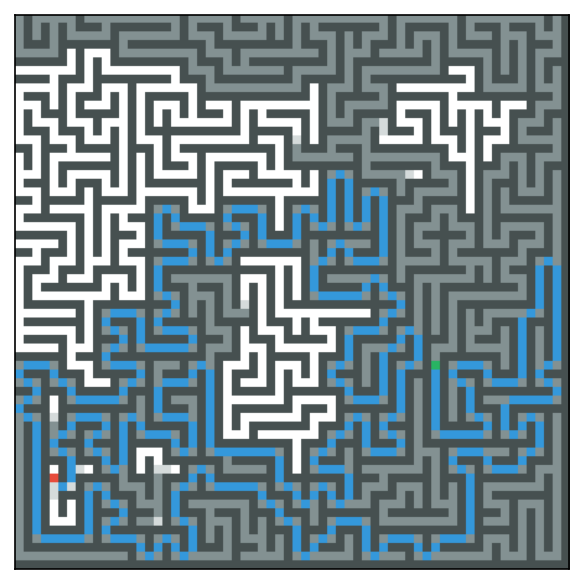

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

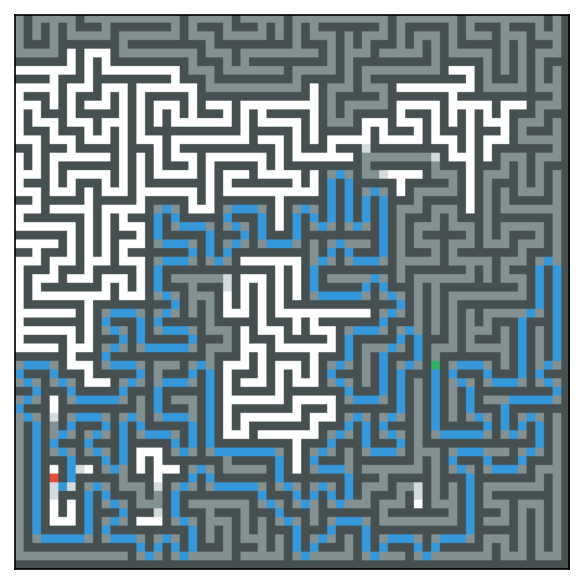

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

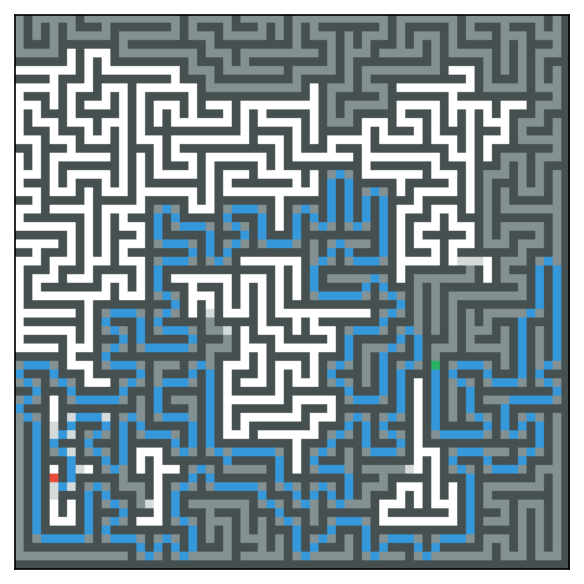

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

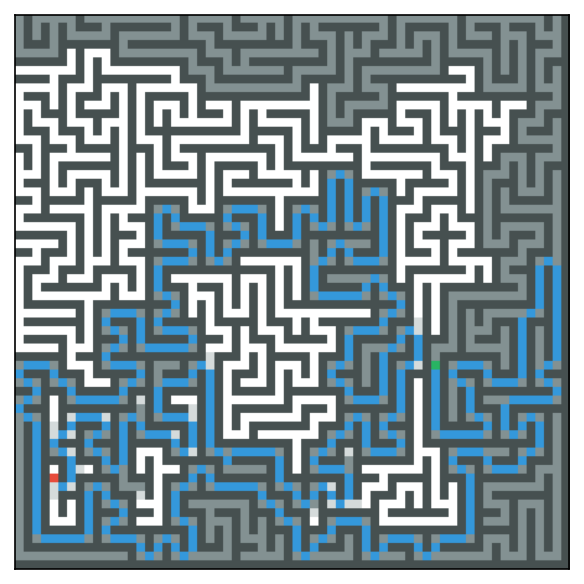

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

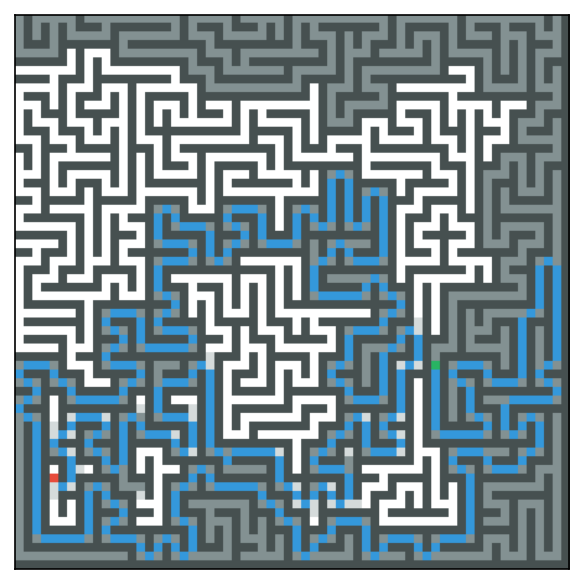

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

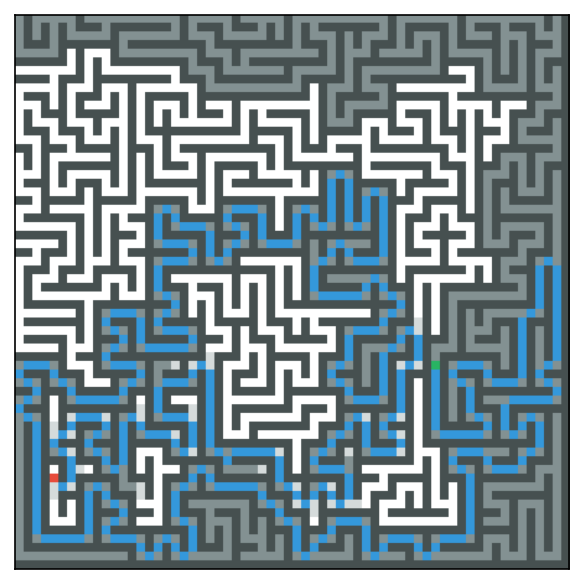

During the search was discovered 0 non-existent paths


WA* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

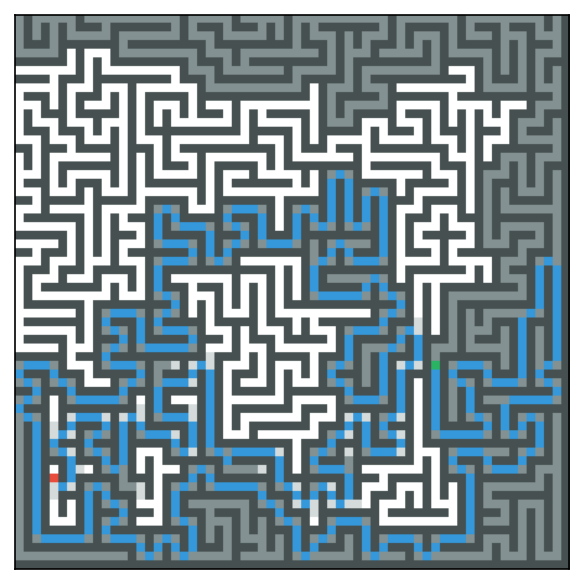

During the search was discovered 0 non-existent paths
CPU times: user 37min 16s, sys: 14.2 s, total: 37min 30s
Wall time: 37min 16s


In [40]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/vesa_russkie', device='cuda:1')

res = contain_ratios(cells, starts, goals, ws=[1.01, 1.05, 1.1, 1.25, 2, 3, 4, 5, 10], model=model, node_type='optimal', threshold=1.05, verbose=2)

In [41]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALRUS1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [42]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALRUS1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model,w=1.01,w=1.05,w=1.1,w=1.25,w=2,w=3,w=4,w=5,w=10
Optimal found ratio,100.0%,32.48%,99.86%,96.12%,86.22%,63.04%,32.35%,24.13%,19.44%,14.38%,13.4%
Length ratio,100.0±0.0%,106.82±12.74%,100.0±0.01%,100.04±0.22%,100.2±0.58%,100.89±1.57%,103.74±4.85%,105.21±6.54%,106.77±7.92%,107.9±8.92%,109.72±11.08%
Expansions ratio,100.0±0.0%,69.7±36.44%,99.07±1.65%,93.07±8.93%,86.2±15.52%,72.63±24.6%,54.57±30.05%,49.79±30.08%,48.26±29.97%,47.25±29.79%,45.11±29.19%


A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

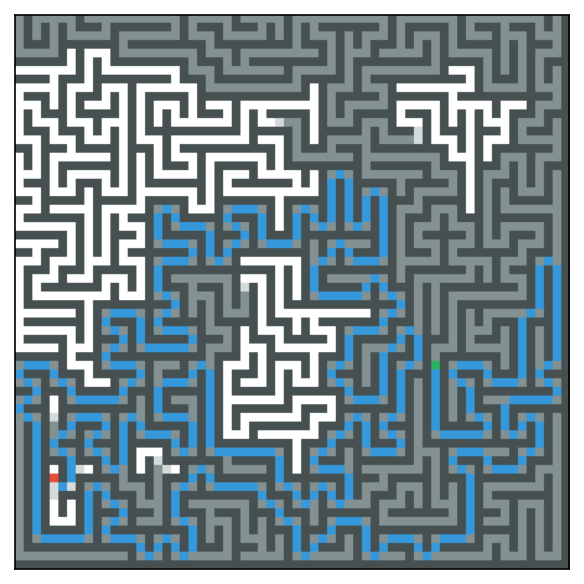

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


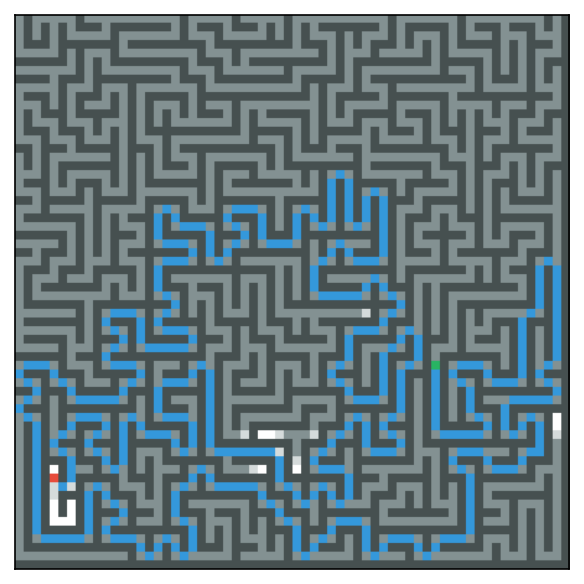

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths
CPU times: user 10min 30s, sys: 5.33 s, total: 10min 36s
Wall time: 10min 30s


In [4]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/dumbQRs_big_model_1', device='cuda:2')

res = contain_ratios(cells, starts, goals, ws=[], model=model, node_type='optimal', threshold=1.05, verbose=2)

In [5]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALDUMB1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [6]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALDUMB1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,1.4%
Length ratio,100.0±0.0%,129.85±42.0%
Expansions ratio,100.0±0.0%,102.38±88.59%


A* octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

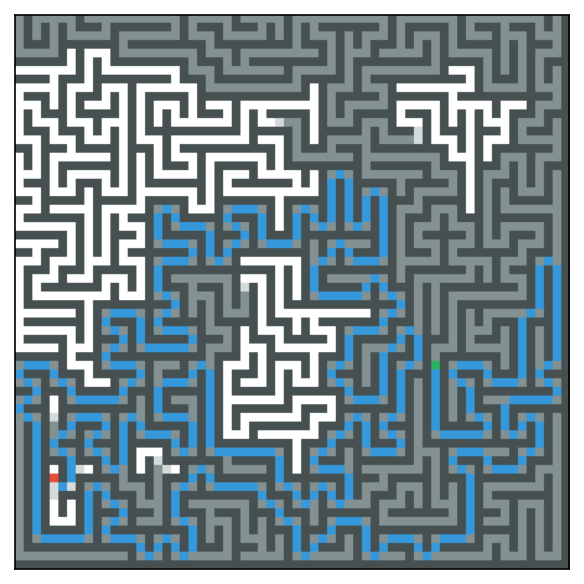

During the search was discovered 0 non-existent paths


Count complexity: 0it [00:00, ?it/s]

IOPub data rate exceeded.
The Jupyter server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--ServerApp.iopub_data_rate_limit`.

Current values:
ServerApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
ServerApp.rate_limit_window=3.0 (secs)



Predicting heuristics:   0%|          | 0/20000 [00:00<?, ?it/s]

A* with cf octile search:   0%|          | 0/20000 [00:00<?, ?it/s]

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: divide by zero encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


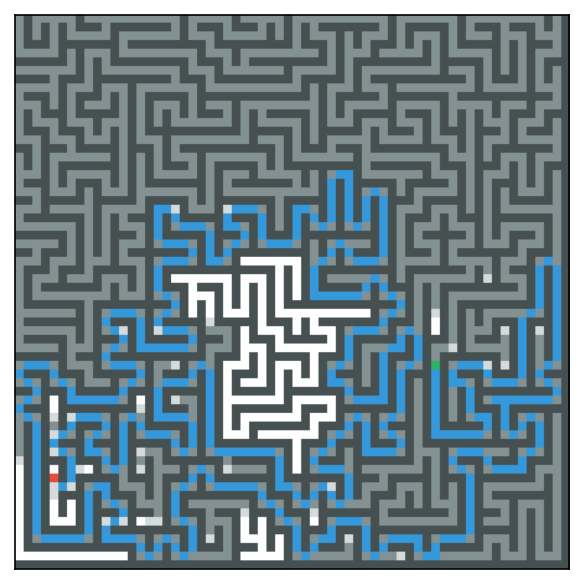

/home/drozdovdan/TransPath_Adaptation/analysis/astar.py:627: RuntimeWarning: invalid value encountered in divide
  return astar(task_map, start_i, start_j, goal_i, goal_j, heuristics / cf, search_tree, node_type=node_type)


During the search was discovered 0 non-existent paths
CPU times: user 10min 34s, sys: 4.41 s, total: 10min 38s
Wall time: 10min 33s


In [7]:
%%time
cells, starts, goals, cfs = data_from_dir('../testset/test')

model = create_TransPath_model(weights_path='../weights/TransPath_cf_20250414-020803', device='cuda:2')

res = contain_ratios(cells, starts, goals, ws=[], model=model, node_type='optimal', threshold=1.05, verbose=2)

In [8]:
import pickle

print(len(res['model']))


# Save to a pickle file
with open("../results/OPTIMALSMART1.05.pkl", "wb") as f:
    pickle.dump(res, f, protocol=pickle.HIGHEST_PROTOCOL)

20000


In [9]:
import pickle



# Save to a pickle file
with open("../results/OPTIMALSMART1.05.pkl", "rb") as f:
    res = pickle.load(f)

res = get_metrics(res)

display(res)

,baseline,model
Optimal found ratio,100.0%,29.98%
Length ratio,100.0±0.0%,119.41±37.31%
Expansions ratio,100.0±0.0%,111.23±114.19%
